<a href="https://colab.research.google.com/github/WYlim1003/Machine-Learning-Assignment/blob/main/Import_pandas_from_zoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WIA 1006 Machine Learning Group Project
**Group Name :** Import Pandas from Zoo<br>
**Group members :**<br>
Chan Yi Ern (24004495) <br>
Lee Yu Xuan (23098783) <br>
Lim Wan Yee (24004499) <br>
Nicole Teh May Xin (24004507) <br>
Yeoh Yee Syuen (24004541) <br>
**Semester session:** Sem 2 2024/2025 <br>
**Theme :** Hourly Origin-Destination Ridership: Komuter  <br>
**Machine Learning problem:** Predict the Ridership Per Hour Based On the Independent Features<br>

The *komuter_2025* and *fuelprice* datasets were obtained from data.gov.my, the official source for government data. The *komuter_2025* dataset contains hourly origin-destination ridership data, serving as our dependent variable, based on the date, time (in HH:MM format), origin station, and destination station. The *fuelprice* dataset provides the prices for RON95, RON97, diesel, and diesel_eastmsia, updated on specified dates, and includes two series types to analyze fuel price levels and their changes.

In addition to the government data, we incorporated two external datasets. The *weather* dataset, sourced from the Visual Crossing website, provides detailed weather information, including temperature, humidity, precipitation, wind speed, visibility, UV index and so forth. The *public_holiday* dataset, obtained from the website https://publicholidays.com.my/2025-dates/#google_vignette, lists the public holidays in Malaysia for the year 2025. These additional datasets are included to explore their potential influence on Komuter ridership.

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb

from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

#Import Dataset
**Raw Dataset**<br>
This part snippet sets up the environment for data analysis by mounting Google Drive for data access, loading data from a CSV file into a pandas DataFrame, and displaying the first few rows of the data for initial inspection.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


##Import komuter_2025.csv
**Description**
1. date - Date in YYYY-MM-DD format
2. time - Hour in HH:MM format, with MM set to 00. The 'time' column was produced by taking the hour from the timestamp of the transaction. As an example, a value of '09:00' indicates all transactions occuring between 09:00 and 09:59. This is different from rounding to the nearest hour, where a value of '09:00' would indicate all transactions occuring between 08:30 and 09:29.
3. origin - The station at which the journey began
4. destination - The station at which the journey ended
5. ridership - Number of trips taken from the origin to the destination; it should be noted that this may not necessarily equal the number of passengers, especially for origin-destination pairs with a short travel time. However, because the data is at hourly frequency, the number of passengers is likely to be close or equal to the number of trips.


In [ ]:
df_komuter2025 = pd.read_csv('/content/drive/MyDrive/ML/komuter_2025.csv')
df_komuter2025.head()

,date,time,origin,destination,ridership
0,2025-01-01,00:00,Abdullah Hukum,Klang,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1
2,2025-01-01,00:00,Bangi,Batu Caves,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1


##Import public_holiday.csv
**Description**<br>
1. Date - In day-month format
2. Day - The day corresponding to the date
3. Holiday - Name of the holiday
4. States - States and federal territories that have the holiday.

In [ ]:
df_public_holiday = pd.read_csv('/content/drive/MyDrive/ML/public_holiday_2025.csv')
df_public_holiday.head()

,Date,Day,Holiday,States
0,1-Jan,Wed,New Year's Day,"National except Johor, Kedah, Kelantan, Perlis..."
1,14-Jan,Tue,YDPB Negeri Sembilan's Birthday,Negeri Sembilan
2,27-Jan,Mon,Israk and Mikraj,"Kedah, Negeri Sembilan, Perlis & Terengganu"
3,29-Jan,Wed,Chinese New Year,National
4,30-Jan,Thu,Chinese New Year Holiday,National


##Import weather.csv
**Description**<br>
1. temp(°C) - Temperature (or mean temperature)
2. feelslike(°C) - Feels like temperature
3. dew(°C) - Dew Point
4. humidity(%) - Relative Humidity
5. precip(mm) - Precipitation
6. precipprob(%) - Precipitation chance
7. preciptype - Precipitation type
8. snow(cm) - Snow
9. snowdepth(cm) - Snow Depth
10. windgust(kph) - Wind Gust
11. windspeed(kph) - Wind Speed
12. winddir(degrees) - Wind Direction
13. sealevelpressure(mb) - Sea Level Pressure
14. cloudcover(%) - Cloud Cover
15. visibility(km) - Visibility
16. solarradiation(W/m2) - Solar Radiation
17. solarenergy(MJ/m2) - Solar Energy
18. uvindex - UV Index
19. severerisk - Severe Risk
20. conditions - Short text about the weather
21. icon - A weather icon
22. stations - List of weather stations sources

In [ ]:
df_weather = pd.read_csv('/content/drive/MyDrive/ML/weather.csv')
df_weather.head()

,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,malaysia,2025-01-01T00:00:00,25.0,25.0,24.0,94.04,0.0,0.0,NaN,0,...,1012.0,27.5,10.0,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"48647099999,48650099999,WMSA,WMKK"
1,malaysia,2025-01-01T01:00:00,25.0,25.0,24.0,94.04,0.0,0.0,NaN,0,...,1012.0,27.5,9.0,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"48647099999,48650099999,WMSA,WMKK"
2,malaysia,2025-01-01T02:00:00,25.1,25.1,23.8,92.76,0.0,0.0,NaN,0,...,1011.3,57.7,9.0,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"48647099999,48650099999,WMSA,WMKK"
3,malaysia,2025-01-01T03:00:00,25.0,25.0,24.0,94.04,0.0,0.0,NaN,0,...,1010.0,27.5,8.0,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"48647099999,48650099999,WMSA,WMKK"
4,malaysia,2025-01-01T04:00:00,25.0,25.0,24.0,94.04,0.0,0.0,NaN,0,...,1009.0,27.5,7.1,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"48647099999,48650099999,WMSA,WMKK"


##Import fuelprice.csv
**Description**<br>
1. series_type - Price in RM (level), or weekly change in RM (change_weekly)
2. date - The date of effect of the price, in YYYY-MM-DD format
3. ron95 - Price per litre of RON95 petrol, in RM
4. ron97 - Price per litre of RON97 petrol, in RM
5. diesel - Price per litre of diesel in Peninsular Malaysia, in RM
6. diesel_eastmsia - Price per litre of diesel in East Malaysia, in RM







In [ ]:
df_fuelprice = pd.read_csv('/content/drive/MyDrive/ML/fuelprice.csv')
df_fuelprice.head()

,series_type,date,ron95,ron97,diesel,diesel_eastmsia
0,level,2025-05-15,2.05,3.07,2.77,2.15
1,level,2025-05-08,2.05,3.10,2.80,2.15
2,level,2025-05-01,2.05,3.18,2.88,2.15
3,level,2025-04-24,2.05,3.18,2.88,2.15
4,level,2025-04-17,2.05,3.18,2.88,2.15


# Merged Datasets
**Merge All Datasets** <br>
The entire merging process aims to create a single, unified dataset, in this case merged_df3, where each row represents an hourly origin-destination Komuter trip and contains all the potentially relevant factors influencing ridership for that specific hour.

## Handling df_public_holiday


### Rename Column
**Rename Column**<br>
The 'Date' column was renamed to 'date' to match the naming convention in *df_komuter2025*. This is essential for merging based on the date.

In [ ]:
# Rename the 'Date' column to 'date'
# Rename the 'States' column to 'states'
df_public_holiday = df_public_holiday.rename(columns={'Date': 'date'})
df_public_holiday = df_public_holiday.rename(columns={'States': 'states'})

### Specified Date Format
**Specified Date Format**<br>
The 'date' column was converted to datetime objects with a specific format. This ensures consistent date formats and data types across dataframes for accurate merging.

In [ ]:
# Convert the 'date' column to datetime objects and specifying the format
df_public_holiday['date'] = pd.to_datetime(df_public_holiday['date'] + '-2025', format='%d-%b-%Y')

### Handling Column's Input
**Handling Column's Input**

**Purpose:** <br>
This is a data cleaning step for the 'states' column. It addresses inconsistent entries like "National except..." and converts them into a standardized format (a string listing the included states) that can be easily checked later for specific state holidays. All the entries that having '&' symbol will change to "," to ensure consistency. After that, filter the rows in the 'states' column that do not include 'Kuala Lumpur', 'Selangor', 'Melaka', 'Negeri Sembilan' or 'Perak' to avoid duplicating data due to the same holiday on the same date.

In [ ]:
# Full list of 13 states + 3 federal territories
all_states_and_federal = [
    "Johor", "Kedah", "Kelantan", "Melaka", "Negeri Sembilan", "Pahang",
    "Penang", "Perak", "Perlis", "Sabah", "Sarawak", "Selangor", "Terengganu",
    "Labuan", "Kuala Lumpur", "Putrajaya"
]

# Function to normalize state strings
def normalize_states(state_str):
    if isinstance(state_str, str) and state_str.startswith("National except"):
        # Clean and split by "," or "&"
        cleaned = state_str.replace("National except", "").replace("&", ",")
        excluded = [s.strip() for s in cleaned.split(",")]
        included = [state for state in all_states_and_federal if state not in excluded]
        return ", ".join(included)
    elif isinstance(state_str, str) and state_str.strip() == "National":
        return ", ".join(all_states_and_federal)
    elif isinstance(state_str, str):
        cleaned = state_str.replace("&", ",")
        return ", ".join([s.strip() for s in cleaned.split(",")])
    else:
        return ""

# Apply the function to the dataframe column
df_public_holiday["states"] = df_public_holiday["states"].apply(normalize_states)

In [ ]:
# Define the list of relevant states
relevant_states = ['Kuala Lumpur', 'Selangor', 'Melaka', 'Negeri Sembilan', 'Perak']

# Filter rows where the 'states' column contains at least one of the relevant states
df_public_holiday = df_public_holiday[
    df_public_holiday['states'].apply(
        lambda state_str: any(state in state_str for state in relevant_states) if isinstance(state_str, str) else False
    )
].reset_index(drop=True)

# To see the number of rows removed
display(df_public_holiday)
print(f"Number of rows after filtering based on states: {len(df_public_holiday)}")

,date,Day,Holiday,states
0,2025-01-01,Wed,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
1,2025-01-14,Tue,YDPB Negeri Sembilan's Birthday,Negeri Sembilan
2,2025-01-27,Mon,Israk and Mikraj,"Kedah, Negeri Sembilan, Perlis, Terengganu"
3,2025-01-29,Wed,Chinese New Year,"Johor, Kedah, Kelantan, Melaka, Negeri Sembila..."
4,2025-01-30,Thu,Chinese New Year Holiday,"Johor, Kedah, Kelantan, Melaka, Negeri Sembila..."
5,2025-02-01,Sat,Federal Territory Day,"Kuala Lumpur, Labuan, Putrajaya"
6,2025-02-11,Tue,Thaipusam,"Johor, Kedah, Kuala Lumpur, Negeri Sembilan, P..."
7,2025-02-20,Thu,Independence Declaration Day,Melaka
8,2025-03-18,Tue,Nuzul Al-Quran,"Kelantan, Pahang, Penang, Perak, Perlis, Selan..."
9,2025-03-31,Mon,Hari Raya Aidilfitri,"Johor, Kedah, Kelantan, Melaka, Negeri Sembila..."


Number of rows after filtering based on states: 27


### Display Dataframe & Info

In [ ]:
# Display the dataframe
df_public_holiday.head()

,date,Day,Holiday,states
0,2025-01-01,Wed,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
1,2025-01-14,Tue,YDPB Negeri Sembilan's Birthday,Negeri Sembilan
2,2025-01-27,Mon,Israk and Mikraj,"Kedah, Negeri Sembilan, Perlis, Terengganu"
3,2025-01-29,Wed,Chinese New Year,"Johor, Kedah, Kelantan, Melaka, Negeri Sembila..."
4,2025-01-30,Thu,Chinese New Year Holiday,"Johor, Kedah, Kelantan, Melaka, Negeri Sembila..."


In [ ]:
df_public_holiday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     27 non-null     datetime64[ns]
 1   Day      27 non-null     object        
 2   Holiday  27 non-null     object        
 3   states   27 non-null     object        
dtypes: datetime64[ns](1), object(3)
memory usage: 996.0+ bytes


## Merge df_public_holiday and df_komuter2025
**Merging**<br>
The first merge combined the core ridership data (df_komuter2025) with the public holiday information (df_public_holiday). After merging, place the 'Day' column with their respective day corresponding to the date.<br><br>
**Join Key:** <br>
The merge was performed on the **'date'** column, as this is the common link between the two datasets.<br><br>

**Join Type:** <br>
A left merge (how='left') was used. <br>
**This is important:**<br>
It keeps all rows from the left dataframe (df_komuter2025).
It includes matching rows from the right dataframe (df_public_holiday).
If a date in df_komuter2025 does not have a corresponding entry in df_public_holiday, the columns from df_public_holiday for that row will contain missing (NaN) values. This is expected, as not every day is a public holiday.<br><br>

The result was stored in **merged_df**.

In [ ]:
# Ensure the 'date' columns are of the same data type
df_komuter2025['date'] = pd.to_datetime(df_komuter2025['date'])

# Merge the two dataframes on the 'date' column
# Using a left merge to keep all rows from df_komuter2025
merged_df = pd.merge(df_komuter2025, df_public_holiday, on='date', how='left').reset_index(drop=True)

In [ ]:
# Fill the 'Day' column with the corresponding day of the week
merged_df['Day'] = merged_df['date'].dt.day_name()

In [ ]:
merged_df.head()

,date,time,origin,destination,ridership,Day,Holiday,states
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
2,2025-01-01,00:00,Bangi,Batu Caves,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak..."


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794379 entries, 0 to 794378
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         794379 non-null  datetime64[ns]
 1   time         794379 non-null  object        
 2   origin       794379 non-null  object        
 3   destination  794379 non-null  object        
 4   ridership    794379 non-null  int64         
 5   Day          794379 non-null  object        
 6   Holiday      80715 non-null   object        
 7   states       80715 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 48.5+ MB


## Handling df_fuelprice

### Remain Necessary Rows
**Remain Necessary Rows**<br>
The **'date'** column was converted to datetime objects.
Rows where **'series_type'** was **'change_weekly' were removed**. This was done because the **'level'** series type provides the **actual fuel price** levels, which are the primary focus for this analysis, and the **'change_weekly'** could be **redundant** or **add complexity** for predicting ridership.
The data was filtered to include only **entries for the year 2025**, **aligning** with the *komuter_2025* data.

In [ ]:
# Ensure the 'date' column is in datetime format
df_fuelprice['date'] = pd.to_datetime(df_fuelprice['date'])

# Filter the DataFrame to remove rows where 'series_type' is 'change_weekly'
# Since the 'change_weekly' data points are repeat the same insights as 'level' data points
# The 'change_weekly' data points are specifying all the changes
# either increase fuel price (positive values)
# or decrease fuel price (negative values)
# In simple word, it shows the changes in prices for each fuels
# Hence, we only need the 'level' data points
df_fuelprice = df_fuelprice[df_fuelprice['series_type'] != 'change_weekly'].copy()

# Filter the DataFrame to keep only rows where the year is 2025 from the filtered data
df_fuelprice_2025 = df_fuelprice[df_fuelprice['date'].dt.year == 2025].copy()

# Check the columns and unique years to confirm the changes
print("Unique years in df_fuelprice_2025:", df_fuelprice_2025['date'].dt.year.unique())

Unique years in df_fuelprice_2025: [2025]


### Drop Unnecessary Column
**Drop Unnecessary Column**<br>
The 'series_type' and 'diesel_eastmsia' columns were dropped as they were no longer needed for the merge and subsequent analysis. The 'diesel_eastmsia' column was not relevant to predicting Komuter ridership in West Malaysia, as the dataset for ridership focuses on this region.

In [ ]:
# Drop the 'series_type' column since we no longer need it now
# Drop the 'diesel_eastmsia' column since it is not related to our prediction
# because the komuter in our dataset is operated in West Malaysia only
df_fuelprice_2025 = df_fuelprice_2025.drop(columns=['series_type'])
df_fuelprice_2025 = df_fuelprice_2025.drop(columns=['diesel_eastmsia'])

### Display Dataframe & Info

In [ ]:
df_fuelprice_2025.head()

,date,ron95,ron97,diesel
0,2025-05-15,2.05,3.07,2.77
1,2025-05-08,2.05,3.10,2.80
2,2025-05-01,2.05,3.18,2.88
3,2025-04-24,2.05,3.18,2.88
4,2025-04-17,2.05,3.18,2.88


In [ ]:
df_fuelprice_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    20 non-null     datetime64[ns]
 1   ron95   20 non-null     float64       
 2   ron97   20 non-null     float64       
 3   diesel  20 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 800.0 bytes


## Merge merge_df and df_fuelprice_2025
**Merging**<br>
This merge combined the merged_df (which already had ridership and public holiday info) with the processed fuel price data (df_fuelprice_2025).<br><br>

**Join Key:**<br>
The merge was performed on the **'date'** column. Fuel prices are updated on specific dates, so joining on the date allows you to link the relevant fuel price to each ridership entry on that date.<br><br>

**Join Type:**<br>
 A left merge (how='left') was used again. This keeps all rows from the left dataframe (merged_df) and brings in the fuel price information for the corresponding dates. If a date in merged_df doesn't have a fuel price update in df_fuelprice_2025, the fuel price columns will have missing values (which you later handle with forward filling).<br><br>

The result was stored in **merged_df2**.

In [ ]:
# Merge the dataframes
merged_df2 = pd.merge(merged_df, df_fuelprice_2025, on='date', how='left')

merged_df2.head()

,date,time,origin,destination,ridership,Day,Holiday,states,ron95,ron97,diesel
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN
2,2025-01-01,00:00,Bangi,Batu Caves,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN


## Handling df_weather

### Select Columns
**Select Columns**<br>
To choose only the weather features relevant for predicting ridership and remove columns with high missing values or low relevance. Moreover, we need to split the single 'datetime' column into separate 'date' and 'time' columns, and ensure the 'date' column is a datetime object. This is essential because the Komuter data is granular by hour, and we need to match weather conditions for a specific hour on a specific date. Besides, we reorder the columns to arrange the columns in a more logical order, placing 'date' and 'time' at the beginning for easier viewing.



In [ ]:
# Print all column names of df_selangor_weather to acquire the insights on
# which columns to be removed
print(df_weather.columns)

Index(['name', 'datetime', 'temp', 'feelslike', 'dew', 'humidity', 'precip',
       'precipprob', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'conditions',
       'icon', 'stations'],
      dtype='object')


In [ ]:
# Calculate the number of null values for each column in df_selangor_weather
null_values_weather = df_weather.isnull().sum()

# Calculate the total number of rows
total_rows = len(df_weather)

# Calculate the percentage of null values for each column
percentage_null_values_weather = (null_values_weather / total_rows) * 100

# Print the result
print("Null values in df_selangor_weather:")
print(null_values_weather)
print("\nPercentage of null values in df_selangor_weather:")
print(percentage_null_values_weather)

Null values in df_selangor_weather:
name                   0
datetime               0
temp                   0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
preciptype          3355
snow                   0
snowdepth              0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk          2880
conditions             0
icon                   0
stations             358
dtype: int64

Percentage of null values in df_selangor_weather:
name                 0.000000
datetime             0.000000
temp                 0.000000
feelslike            0.000000
dew                  0.000000
humidity             0.000000
precip               0.000000
precipprob           0.000000
preciptype          93.194444
snow                 0.000000


In [ ]:
# List of columns to keep
# Based on the results, columns with high percentage of null values should not be considered
# since it might highly affect the accuracy of the results
# Those not related to Selangor weather, such as 'snow' should not be considered as well
# Only choose the suitable columns
columns_to_keep = ['datetime', 'temp', 'feelslike', 'humidity', 'precip', 'precipprob', 'windspeed', 'visibility', 'uvindex']

# Remain only the specified columns
df_weather = df_weather[columns_to_keep].copy()

In [ ]:
# Convert the 'datetime' column to datetime objects
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])

# Create the 'date' column
df_weather['date'] = df_weather['datetime'].dt.date

# Create the 'time' column with the desired format 'H:M'
df_weather['time'] = df_weather['datetime'].dt.strftime('%H:%M')

# Drop the original 'datetime' column
df_weather = df_weather.drop(columns=['datetime'])

In [ ]:
# Get the current list of columns
current_columns = df_weather.columns.tolist()

# Remove 'date' and 'time' from the current list if they exist
if 'date' in current_columns:
    current_columns.remove('date')
if 'time' in current_columns:
    current_columns.remove('time')

# Create the new column order with 'date' and 'time' at the beginning
new_column_order = ['date', 'time'] + current_columns

# Reindex the DataFrame with the new column order
df_weather = df_weather[new_column_order]

# Convert the 'date' column to with datetime data type
# This step might not be necessary if it was already done, but it's good practice to ensure
df_weather['date'] = pd.to_datetime(df_weather['date'])

# Display the head of the DataFrame with the new column order
df_weather.head()

,date,time,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex
0,2025-01-01,00:00,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
1,2025-01-01,01:00,25.0,25.0,94.04,0.0,0.0,3.6,9.0,0
2,2025-01-01,02:00,25.1,25.1,92.76,0.0,0.0,1.8,9.0,0
3,2025-01-01,03:00,25.0,25.0,94.04,0.0,0.0,0.0,8.0,0
4,2025-01-01,04:00,25.0,25.0,94.04,0.0,0.0,3.6,7.1,0


### Display Dataframe & Info

In [ ]:
df_weather.head()

,date,time,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex
0,2025-01-01,00:00,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
1,2025-01-01,01:00,25.0,25.0,94.04,0.0,0.0,3.6,9.0,0
2,2025-01-01,02:00,25.1,25.1,92.76,0.0,0.0,1.8,9.0,0
3,2025-01-01,03:00,25.0,25.0,94.04,0.0,0.0,0.0,8.0,0
4,2025-01-01,04:00,25.0,25.0,94.04,0.0,0.0,3.6,7.1,0


In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        3600 non-null   datetime64[ns]
 1   time        3600 non-null   object        
 2   temp        3600 non-null   float64       
 3   feelslike   3600 non-null   float64       
 4   humidity    3600 non-null   float64       
 5   precip      3600 non-null   float64       
 6   precipprob  3600 non-null   float64       
 7   windspeed   3600 non-null   float64       
 8   visibility  3600 non-null   float64       
 9   uvindex     3600 non-null   int64         
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 281.4+ KB


## Merge merged_df2 and df_weather
**Merging**<br>
This merge combined the merged_df2 (which already had ridership, public holiday, and fuel price info) with the processed weather data (df_weather).<br><br>


**Join Key:**<br>
The merge was performed on both the **'date'** and **'time'** columns. Since both the Komuter ridership data and the weather data are recorded at an hourly granularity, joining on both date and time is essential to accurately link the weather conditions for a specific hour to the Komuter trips that occurred at that same hour on that date.<br><br>


**Join Type:**<br>
A left merge (how='left') was used again. This keeps all rows from the left dataframe (merged_df2, which contains all the Komuter trips). It brings in the matching weather information (df_weather) for the corresponding date and time. If a specific date and time combination in merged_df2 does not have a matching entry in df_weather, the weather-related columns will contain missing (NaN) values for that row. This might happen if there are gaps in the weather data.<br><br>

**Reorder Columns:**<br>
To move the target variable (ridership/hour) to the end of the DataFrame, which is a common practice for better organization and readability, especially before modeling.<br><br>


The result was stored in **merged_df3**.

In [ ]:
# Merge merged_df3 and df_weather based on the 'date' column
# Using a left merge to keep all rows from merged_df3
merged_df3 = pd.merge(merged_df2, df_weather, on=['date', 'time'], how='left')

merged_df3.head()

,date,time,origin,destination,ridership,Day,Holiday,states,ron95,ron97,diesel,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex
0,2025-01-01,00:00,Abdullah Hukum,Klang,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
2,2025-01-01,00:00,Bangi,Batu Caves,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,1,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0


In [ ]:
# Rename the 'ridership' column to 'ridership/hour'
merged_df3 = merged_df3.rename(columns={'ridership': 'ridership/hour'})

# Get the current list of column names
current_cols = merged_df3.columns.tolist()

# Remove the 'ridership/hour' column from the list
current_cols.remove('ridership/hour')

# Append 'ridership/hour' to the end of the list
new_cols = current_cols + ['ridership/hour']

# Reindex the DataFrame with the new column order
merged_df3 = merged_df3[new_cols]

# Final Merged Dataset
Final dataset after merging. Show the head and info of the dataset to have a clear understanding on the final dataset.

In [ ]:
merged_df3.head()

,date,time,origin,destination,Day,Holiday,states,ron95,ron97,diesel,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex,ridership/hour
0,2025-01-01,00:00,Abdullah Hukum,Klang,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
2,2025-01-01,00:00,Bangi,Batu Caves,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,Wednesday,New Year's Day,"Melaka, Negeri Sembilan, Pahang, Penang, Perak...",NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1


In [ ]:
merged_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794379 entries, 0 to 794378
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            794379 non-null  datetime64[ns]
 1   time            794379 non-null  object        
 2   origin          794379 non-null  object        
 3   destination     794379 non-null  object        
 4   Day             794379 non-null  object        
 5   Holiday         80715 non-null   object        
 6   states          80715 non-null   object        
 7   ron95           115155 non-null  float64       
 8   ron97           115155 non-null  float64       
 9   diesel          115155 non-null  float64       
 10  temp            794379 non-null  float64       
 11  feelslike       794379 non-null  float64       
 12  humidity        794379 non-null  float64       
 13  precip          794379 non-null  float64       
 14  precipprob      794379 non-null  flo

# Data cleaning

## Duplicates Values
**Duplicates Values**<br>
This subsection deals with identifying and handling duplicate rows in the dataset.

### Check Duplicates
**Check Duplicates**<br>
 This section is to identify if there are any rows that are identical across a specific set of key columns. In this case, we're checking for rows that have the same 'date', 'time', 'origin', and 'destination'. Finding duplicates is important because they can skew analysis and model training. From the results we obtained, there is no duplicated rows.

In [ ]:
# Check for duplicated rows based on 'date', 'time', 'origin', and 'destination'
duplicated_rows = merged_df3.duplicated(subset=['date', 'time', 'origin', 'destination'], keep=False)

# Display the duplicated rows (optional)
print("Duplicated rows based on date, time, origin, and destination:")
print(merged_df3[duplicated_rows])

# To count the number of duplicated rows:
num_duplicated_rows = duplicated_rows.sum()
print(f"\nNumber of duplicated rows: {num_duplicated_rows}")

Duplicated rows based on date, time, origin, and destination:
Empty DataFrame
Columns: [date, time, origin, destination, Day, Holiday, states, ron95, ron97, diesel, temp, feelslike, humidity, precip, precipprob, windspeed, visibility, uvindex, ridership/hour]
Index: []

Number of duplicated rows: 0


## Inconsistent Data
**Inconsistent Data**<br>
This subsection focuses on finding and addressing data that might be in an unexpected or non-standard format.

### Check Inconsistent Data
**Check Inconsistent Data**<br>
This section is to get an overview of the unique values and the number of unique values in each column. This helps spot potential inconsistencies, typos, or unexpected entries in categorical columns (like 'origin', 'destination', 'Holiday', 'states') and range issues in numerical columns.

In [ ]:
# show inconsistent data
num_unique = merged_df3.nunique()
print("\nNumbers of Unique Values: ")
print(num_unique)

print("\nUnique Values: ")
for column in merged_df3.columns:
    unique_values = merged_df3[column].unique()
    print(f"\nUnique Values in Column '{column}':")
    print(unique_values)


Numbers of Unique Values: 
date               133
time                24
origin              58
destination         59
Day                  7
Holiday             13
states               8
ron95                1
ron97                6
diesel               8
temp                80
feelslike          155
humidity          1240
precip              88
precipprob           2
windspeed           99
visibility          40
uvindex             11
ridership/hour     324
dtype: int64

Unique Values: 

Unique Values in Column 'date':
<DatetimeArray>
['2025-01-01 00:00:00', '2025-01-02 00:00:00', '2025-01-03 00:00:00',
 '2025-01-04 00:00:00', '2025-01-05 00:00:00', '2025-01-06 00:00:00',
 '2025-01-07 00:00:00', '2025-01-08 00:00:00', '2025-01-09 00:00:00',
 '2025-01-10 00:00:00',
 ...
 '2025-05-04 00:00:00', '2025-05-05 00:00:00', '2025-05-06 00:00:00',
 '2025-05-07 00:00:00', '2025-05-08 00:00:00', '2025-05-09 00:00:00',
 '2025-05-10 00:00:00', '2025-05-11 00:00:00', '2025-05-12 00:00:00',
 '2025-

### Ensure Data Consistency
**Ensure Data Consistency**<br>
This is a logical grouping for the steps taken to fix inconsistencies found in the previous step.

In [ ]:
# Replace 'Unknown' and 'Penalty' in 'origin' and 'destination' with NaN in merged_df3
merged_df3['origin'] = merged_df3['origin'].replace(['Unknown', 'Penalty'], np.nan)
merged_df3['destination'] = merged_df3['destination'].replace(['Unknown', 'Penalty'], np.nan)

# Check the number of null values in these columns in merged_df3 after replacement
print("Null values in 'origin' and 'destination' in merged_df3 after replacing 'Unknown' and 'Penalty':")
print(merged_df3[['origin', 'destination']].isnull().sum())

Null values in 'origin' and 'destination' in merged_df3 after replacing 'Unknown' and 'Penalty':
origin         6035
destination    2190
dtype: int64


### Data Transformation
**Data Transformation**<br>
To transform existing data to a more consistent and usable format. In this case, rename the 'Holiday' column and then transforming the 'states' column (which was a string) into a boolean isHoliday column based on specific station locations and whether the holiday applies to the relevant state. This is a significant transformation from a categorical 'states' string to a simple binary (True/False) indicator for holiday status relevant to specific Komuter lines/areas. In our case, there is only involved Selangor, Kuala Lumpur, Melaka, Perak and Negeri Sembilan for our stations. If the origin or destination station is either in one of the holiday date as well as the corresponding state or federal territory, it will return **True**, else return **False**.

In [ ]:
# Change the column's name
merged_df3 = merged_df3.rename(columns={'Holiday': 'isHoliday'})

# Initialize the 'isHoliday' column to False for all rows
merged_df3['isHoliday'] = False

# Define the list of stations in Negeri Sembilan relevant to this condition
negeri_sembilan_stations = ['Nilai', 'Seremban', 'Sungai Gadut', 'Tiroi', 'Batang Benar', 'Labu', 'Rembau', 'Senawang']

# Define the list of stations in Kuala Lumpur relevant to this condition
kuala_lumpur_stations = [
    'Abdullah Hukum', 'Bank Negara', 'Bandar Tasek Selatan',
    'Kampung Batu', 'KL Sentral', 'Kuala Lumpur', 'Midvalley',
    'Petaling', 'Sentul', 'Kepong', 'Pantai Dalam', 'Putra',
    'Salak Selatan', 'Segambut', 'Seputeh', 'Taman Wahyu',
    'Angkasapuri', 'Batu Kentonmen'
]

# Define the list of stations in Selangor relevant to this condition
selangor_stations = [
    'Bangi', 'Batu Tiga', 'Jalan Templer', 'Kajang', 'Klang',
    'Rawang', 'Serdang', 'Setia Jaya', 'Subang Jaya', 'Sungai Buloh',
    'Batu Caves', 'Shah Alam', 'UKM', 'Padang Jawa',
    'Pelabuhan Klang Selatan', 'Telok Gadong', 'Telok Pulai',
    'Batang Kali', 'Bukit Badak', 'Jalan Kastam', 'Kajang 2',
    'Kepong Sentral', 'Kampung Dato Harun', 'Kampung Raja Uda',
    'Kuala Kubu Bharu', 'Kuang', 'Rasa', 'Serendah', 'Seri Setia'
]

# Iterate through the DataFrame
for index, row in merged_df3.iterrows():
    origin = row['origin']
    destination = row['destination']
    states = row['states'] # This should be a string of states now

    # Check for Tanjong Malim condition (origin or destination is Tanjong Malim AND Perak is in states)
    is_tanjong_malim_holiday = (origin == 'Tanjong Malim' or destination == 'Tanjong Malim') and \
                               (isinstance(states, str) and ('Perak' in states))

    # Check for Pulau Sebang (Tampin) condition (origin or destination is Pulau Sebang (Tampin) AND Melaka is in states)
    is_pulau_sebang_holiday = (origin == 'Pulau Sebang (Tampin)' or destination == 'Pulau Sebang (Tampin)') and \
                              (isinstance(states, str) and ('Melaka' in states))

    # Check for Negeri Sembilan condition (origin or destination is in the NS station list AND Negeri Sembilan is in states)
    is_negeri_sembilan_holiday = (origin in negeri_sembilan_stations or destination in negeri_sembilan_stations) and \
                                 (isinstance(states, str) and ('Negeri Sembilan' in states))

    # Check for Kuala Lumpur condition (origin or destination is in the KL station list AND Kuala Lumpur is in states)
    is_kuala_lumpur_holiday = (origin in kuala_lumpur_stations or destination in kuala_lumpur_stations) and \
                              (isinstance(states, str) and ('Kuala Lumpur' in states))

    # Check for Selangor condition (origin or destination is in the Selangor station list AND Selangor is in states)
    is_selangor_holiday = (origin in selangor_stations or destination in selangor_stations) and \
                          (isinstance(states, str) and ('Selangor' in states))

    # If any of the holiday conditions is met, set isHoliday to True
    if is_tanjong_malim_holiday or is_pulau_sebang_holiday or is_negeri_sembilan_holiday or is_kuala_lumpur_holiday or is_selangor_holiday:
        merged_df3.at[index, 'isHoliday'] = True

In [ ]:
# To check whether it is changed successfully
print(merged_df3["isHoliday"].unique())

[ True False]


In [ ]:
# Determine if the date is a weekend (Saturday or Sunday)
merged_df3['isWeekend'] = merged_df3['date'].dt.dayofweek.isin([5, 6])

# Drop the old 'Day' column if it exists
if 'Day' in merged_df3.columns:
    merged_df3 = merged_df3.drop(columns=['Day'])

# Get the current column names
current_cols = merged_df3.columns.tolist()

# Define the desired position for 'isWeekend' after 'destination'
try:
    # Find the index of 'destination'
    destination_index = current_cols.index('destination')
    # Remove 'isWeekend' from its current position
    new_cols = [col for col in current_cols if col != 'isWeekend']
    # Insert 'isWeekend' right after 'destination'
    new_cols.insert(destination_index + 1, 'isWeekend')
except ValueError:
    # If 'destination' column is not found, simply append 'isWeekend' to the end
    print("Warning: 'destination' column not found for positioning. 'isWeekend' appended to the end.")
    new_cols = current_cols # No change needed if destination is not found and we just append

# Reindex the DataFrame with the new column order
merged_df3 = merged_df3[new_cols]

In [ ]:
# To check whether it is changed successfully
print(merged_df3["isWeekend"].unique())

[False  True]


### Drop Unnecessary Column
**Drop Unnecessary Column**<br>
In order to remove the original **'states'** column now that the relevant information for holiday status has been extracted and stored in the new isHoliday column. The 'states' column itself is **no longer needed for modeling** after this transformation.

In [ ]:
# Drop the 'states' column
merged_df3 = merged_df3.drop(columns=['states'])

In [ ]:
merged_df3.head()

,date,time,origin,destination,isWeekend,isHoliday,ron95,ron97,diesel,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex,ridership/hour
0,2025-01-01,00:00,Abdullah Hukum,Klang,False,True,NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,False,True,NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
2,2025-01-01,00:00,Bangi,Batu Caves,False,True,NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,False,True,NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,False,True,NaN,NaN,NaN,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1


In [ ]:
#Check whether all the features are consistent
print("\nUnique Values: ")
for column in merged_df3.columns:
    unique_values = merged_df3[column].unique()
    print(f"\nUnique Values in Column '{column}':")
    print(unique_values)


Unique Values: 

Unique Values in Column 'date':
<DatetimeArray>
['2025-01-01 00:00:00', '2025-01-02 00:00:00', '2025-01-03 00:00:00',
 '2025-01-04 00:00:00', '2025-01-05 00:00:00', '2025-01-06 00:00:00',
 '2025-01-07 00:00:00', '2025-01-08 00:00:00', '2025-01-09 00:00:00',
 '2025-01-10 00:00:00',
 ...
 '2025-05-04 00:00:00', '2025-05-05 00:00:00', '2025-05-06 00:00:00',
 '2025-05-07 00:00:00', '2025-05-08 00:00:00', '2025-05-09 00:00:00',
 '2025-05-10 00:00:00', '2025-05-11 00:00:00', '2025-05-12 00:00:00',
 '2025-05-13 00:00:00']
Length: 133, dtype: datetime64[ns]

Unique Values in Column 'time':
['00:00' '01:00' '02:00' '03:00' '04:00' '05:00' '06:00' '07:00' '08:00'
 '09:00' '10:00' '11:00' '12:00' '13:00' '14:00' '15:00' '16:00' '17:00'
 '18:00' '19:00' '20:00' '21:00' '22:00' '23:00']

Unique Values in Column 'origin':
['Abdullah Hukum' 'Bangi' 'Bank Negara' 'Batu Tiga' 'Bandar Tasek Selatan'
 'Jalan Templer' 'Kajang' 'Kampung Batu' 'KL Sentral' 'Klang'
 'Kuala Lumpur' 'Nilai' '

## Null Values
**Null Values**<br>
This subsection deals with identifying and handling missing data points.

### Check Null Values
**Check Null Values**<br>
To get a count of missing values for every column. This gives a clear picture of where data is missing and how much. The output shows counts of null values, particularly in the fuel price columns ('ron95', 'ron97', 'diesel').

In [ ]:
# look for missing values (null)
missing_values1 = merged_df3.isnull().sum()
#The number of missing values per column

missing_values2 = merged_df3[merged_df3.isnull().any(axis=1)]
#Rows containing missing values

print("\nMissing Values: ")
print("\nMissing Values per column: ")
print(missing_values1)
print("\nRows with missing values: ")
print(missing_values2)


Missing Values: 

Missing Values per column: 
date                   0
time                   0
origin              6035
destination         2190
isWeekend              0
isHoliday              0
ron95             679224
ron97             679224
diesel            679224
temp                   0
feelslike              0
humidity               0
precip                 0
precipprob             0
windspeed              0
visibility             0
uvindex                0
ridership/hour         0
dtype: int64

Rows with missing values: 
             date   time          origin       destination  isWeekend  \
0      2025-01-01  00:00  Abdullah Hukum             Klang      False   
1      2025-01-01  00:00  Abdullah Hukum       Telok Pulai      False   
2      2025-01-01  00:00           Bangi        Batu Caves      False   
3      2025-01-01  00:00     Bank Negara      Sungai Gadut      False   
4      2025-01-01  00:00       Batu Tiga  Kampung Raja Uda      False   
...           ...    ...

### Fill in Null Values
**Fill in Null Values (Fuel Price)**<br>
To fill the missing fuel price values that resulted from the merge. ffill is used based on the assumption that the price remains constant until the next update. Special handling for the first day of 2025 uses the last known price from 2024. The output after filling shows 0 null values for 'ron95', 'ron97', and 'diesel'.

In [ ]:
# Select the fuel columns to check their unique values
fuel_cols = ['ron95', 'ron97', 'diesel']

# By using the for loop, print the unique values of each in the fuel_cols
# In order to check there is any noisy values, such as 0 or negative values
for col in fuel_cols:
    print(f"Unique values for column '{col}':")
    print(merged_df3[col].unique())
    print("-" * 30) # Separator for better readability

Unique values for column 'ron95':
[ nan 2.05]
------------------------------
Unique values for column 'ron97':
[ nan 3.28 3.33 3.38 3.43 3.18 3.1 ]
------------------------------
Unique values for column 'diesel':
[ nan 2.98 3.03 3.08 3.13 3.18 3.06 2.88 2.8 ]
------------------------------


In [ ]:
# First, ensure df_fuelprice has the 'date' column in datetime format
# Sorted by date
# df_fuelprice['date'] = pd.to_datetime(df_fuelprice['date'])
df_fuelprice = df_fuelprice.sort_values(by='date')

# For dates after 2025-01-01, forward fill the null fuel price values
# We will apply ffill to the entire column first, and then handle 2025-01-01 separately
for col in fuel_cols:
    merged_df3[col].fillna(method='ffill', inplace=True)

# For 2025-01-01, fill null values with the last updated data from df_fuelprice (which includes 2024 data)
# Get the last non-null fuel price data from the original df_fuelprice for each fuel type before 2025
last_fuel_prices_2024 = df_fuelprice[df_fuelprice['date'] < '2025-01-01'].tail(1)[fuel_cols].iloc[0]

# Find the row(s) in merged_df3 that correspond to 2025-01-01
jan_1_2025_rows = merged_df3[merged_df3['date'] == '2025-01-01']

# Fill null values in the 2025-01-01 row(s) with the 2024 last updated data
for col in fuel_cols:
    merged_df3.loc[jan_1_2025_rows.index, col] = merged_df3.loc[jan_1_2025_rows.index, col].fillna(last_fuel_prices_2024[col])


# Check for remaining null values in the fuel price columns
print("\nNull values after filling:")
print(merged_df3[fuel_cols].isnull().sum())


Null values after filling:
ron95     0
ron97     0
diesel    0
dtype: int64


<ipython-input-46-9135f7cc8780>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df3[col].fillna(method='ffill', inplace=True)
<ipython-input-46-9135f7cc8780>:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df3[col].fillna(method='ffill', inplace=True)


### Drop the Rows with Null Values
**Drop the Rows with Null Values**<br><br>
**Difficulty in Imputation**<br>
Imputing or filling in missing values for 'origin' and 'destination' (which are categorical columns representing specific locations) is very challenging and often unreliable. There's no simple numerical average or predictable pattern to guess the correct origin or destination of a trip when it's unknown.<br><br>

**Meaningless Data**<br>
Rows where the origin or destination is unknown or designated as 'Penalty' don't represent actual commuter trips that occurred between two valid stations. Including them in the analysis or model training could introduce noise and inaccuracies.<br><br>

**Relatively Small Number**<br>
While the count of missing values in these columns needs to be checked, if the number of rows with NaN in 'origin' or 'destination' is a small percentage of the total dataset, dropping these rows is a reasonable and often preferred approach compared to trying to guess the missing values.

In [ ]:
# Drop the rows that have 'Unknown' in the origin and destination columns
# Since it would be difficult to find the origin and destination based on other columns
# If one of the origin and destination have 'Unknown' data, we hardly to find the unknown values based on the other column
# since it might have a variety of places can be origin to the known destination, and vice versa
# Same goes to 'Penalty' since it is not any of the stations
# Drop rows where 'origin' or 'destination' is null (NaN) in merged_df3
# Calculate the number of rows before dropping
initial_rows = len(merged_df3)
print(f"Number of rows before dropping rows with null 'origin' or 'destination': {initial_rows}")

merged_df3.dropna(subset=['origin', 'destination'], inplace=True)

# Calculate the number of rows after dropping
rows_after_dropping = len(merged_df3)
print(f"Number of rows after dropping rows with null 'origin' or 'destination': {rows_after_dropping}")

Number of rows before dropping rows with null 'origin' or 'destination': 794379
Number of rows after dropping rows with null 'origin' or 'destination': 786170


In [ ]:
print(merged_df3.isnull().sum())

date              0
time              0
origin            0
destination       0
isWeekend         0
isHoliday         0
ron95             0
ron97             0
diesel            0
temp              0
feelslike         0
humidity          0
precip            0
precipprob        0
windspeed         0
visibility        0
uvindex           0
ridership/hour    0
dtype: int64


In [ ]:
merged_df3.head()

,date,time,origin,destination,isWeekend,isHoliday,ron95,ron97,diesel,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex,ridership/hour
0,2025-01-01,00:00,Abdullah Hukum,Klang,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
1,2025-01-01,00:00,Abdullah Hukum,Telok Pulai,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
2,2025-01-01,00:00,Bangi,Batu Caves,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
3,2025-01-01,00:00,Bank Negara,Sungai Gadut,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1
4,2025-01-01,00:00,Batu Tiga,Kampung Raja Uda,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1


## Noisy Data
**Noisy Data**<br>
This section looks for values that are likely incorrect based on real-world expectations.

### Verify Noisy Data
**Verify Noisy Data**<br>
To systematically check numerical columns for values that seem physically impossible or highly improbable (e.g., very low/high temperatures, humidity outside 0-100%, etc.). The threshold chosen are based on the reliable Internet sources that shows the valid range for each of the numerical columns. As we can see from the result, it is a positive finding. It indicates that based on the defined criteria for "noisy" data in these specific columns, there are no data points that are clearly invalid or outside a reasonable physical range. You don't need to take specific action to fix "noisy" data using these thresholds.

In [ ]:
# Select only numerical columns from merged_df3
numerical_cols_merged = merged_df3.select_dtypes(include=['number'])

# Get descriptive statistics for these numerical columns
print("Descriptive statistics for numerical columns in merged_df3:\n")
print(numerical_cols_merged.describe())

Descriptive statistics for numerical columns in merged_df3:

              ron95          ron97         diesel           temp  \
count  7.861700e+05  786170.000000  786170.000000  786170.000000   
mean   2.050000e+00       3.319765       3.043845      28.593444   
std    2.874458e-11       0.099462       0.114641       2.842963   
min    2.050000e+00       3.100000       2.800000      23.100000   
25%    2.050000e+00       3.280000       2.980000      26.000000   
50%    2.050000e+00       3.330000       3.030000      28.000000   
75%    2.050000e+00       3.430000       3.180000      31.000000   
max    2.050000e+00       3.430000       3.180000      35.000000   

           feelslike       humidity         precip     precipprob  \
count  786170.000000  786170.000000  786170.000000  786170.000000   
mean       31.842733      76.376767       0.560460       4.558174   
std         5.061134      13.618134       4.740745      20.857638   
min        23.100000      36.900000       0.000000

In [ ]:
# Check for rows where ridership is less than 0
ridership_less_than_0 = merged_df3[merged_df3['ridership/hour'] < 0]

if not ridership_less_than_0.empty:
    print("Rows with ridership less than 0:")
    print(ridership_less_than_0)
else:
    print("No rows found with ridership less than 0.")

No rows found with ridership less than 0.


In [ ]:
fuel_cols = ['ron95', 'ron97', 'diesel']

print("\nChecking fuel prices for values less than or equal to 0:")
for col in fuel_cols:
    # Check for rows where the fuel price is less than or equal to 0
    fuel_price_leq_0 = merged_df3[merged_df3[col] <= 0]

    if not fuel_price_leq_0.empty:
        print(f"\nRows in '{col}' with values less than or equal to 0:")
        print(fuel_price_leq_0[['date', 'time', col]]) # Display relevant columns
    else:
        print(f"\nNo rows found in '{col}' with values less than or equal to 0.")


Checking fuel prices for values less than or equal to 0:

No rows found in 'ron95' with values less than or equal to 0.

No rows found in 'ron97' with values less than or equal to 0.

No rows found in 'diesel' with values less than or equal to 0.


In [ ]:
# Check for noisy values in 'temp' and 'feelslike'
print("Checking 'temp' and 'feelslike' for noisy values (< 20 or > 45):")
temp_noisy = merged_df3[(merged_df3['temp'] < 20) | (merged_df3['temp'] > 45)]
feelslike_noisy = merged_df3[(merged_df3['feelslike'] < 20) | (merged_df3['feelslike'] > 45)]

if not temp_noisy.empty:
    print("\nRows with noisy 'temp' values:")
    print(temp_noisy[['date', 'time', 'temp']])
else:
    print("\nNo noisy 'temp' values found.")

if not feelslike_noisy.empty:
    print("\nRows with noisy 'feelslike' values:")
    print(feelslike_noisy[['date', 'time', 'feelslike']])
else:
    print("\nNo noisy 'feelslike' values found.")

# Check for noisy values in 'humidity'
print("\nChecking 'humidity' for noisy values (< 0 or >100):")
humidity_noisy = merged_df3[merged_df3['humidity'] < 0 | (merged_df3['humidity'] > 100)]

if not humidity_noisy.empty:
    print("\nRows with noisy 'humidity' values:")
    print(humidity_noisy[['date', 'time', 'humidity']])
else:
    print("\nNo noisy 'humidity' values found.")

# Check for noisy values in 'precip'
print("\nChecking 'precip' for noisy values (< 0 or > 150):")
precip_noisy = merged_df3[(merged_df3['precip'] < 0) | (merged_df3['precip'] > 150)]

if not precip_noisy.empty:
    print("\nRows with noisy 'precip' values:")
    print(precip_noisy[['date', 'time', 'precip']])
else:
    print("\nNo noisy 'precip' values found.")

# Check for noisy values in 'precipprob'
print("\nChecking 'precipprob' for noisy values (< 0 or > 100):")
precipprob_noisy = merged_df3[(merged_df3['precipprob'] < 0) | (merged_df3['precipprob'] > 100)]

if not precipprob_noisy.empty:
    print("\nRows with noisy 'precipprob' values:")
    print(precipprob_noisy[['date', 'time', 'precipprob']])
else:
    print("\nNo noisy 'precipprob' values found.")

# Check for noisy values in 'windspeed'
print("\nChecking 'windspeed' for noisy values (> 50):")
windspeed_noisy = merged_df3[merged_df3['windspeed'] > 50]

if not windspeed_noisy.empty:
    print("\nRows with noisy 'windspeed' values:")
    print(windspeed_noisy[['date', 'time', 'windspeed']])
else:
    print("\nNo noisy 'windspeed' values found.")

# Check for noisy values in 'visibility'
print("\nChecking 'visibility' for noisy values (< 0 or > 15):")
visibility_noisy = merged_df3[(merged_df3['visibility'] < 0) | (merged_df3['visibility'] > 15)]

if not visibility_noisy.empty:
    print("\nRows with noisy 'visibility' values:")
    print(visibility_noisy[['date', 'time', 'visibility']])
else:
    print("\nNo noisy 'visibility' values found.")

# Check for noisy values in 'uvindex'
print("\nChecking 'uvindex' for noisy values (< 0 or > 11):")
uvindex_noisy = merged_df3[(merged_df3['uvindex'] < 0) | (merged_df3['uvindex'] > 11)]

if not uvindex_noisy.empty:
    print("\nRows with noisy 'uvindex'")
    print(uvindex_noisy[['date', 'time', 'uvindex']])
else:
    print("\nNo noisy 'uvindex' values found.")

Checking 'temp' and 'feelslike' for noisy values (< 20 or > 45):

No noisy 'temp' values found.

No noisy 'feelslike' values found.

Checking 'humidity' for noisy values (< 0 or >100):

No noisy 'humidity' values found.

Checking 'precip' for noisy values (< 0 or > 150):

No noisy 'precip' values found.

Checking 'precipprob' for noisy values (< 0 or > 100):

No noisy 'precipprob' values found.

Checking 'windspeed' for noisy values (> 50):

No noisy 'windspeed' values found.

Checking 'visibility' for noisy values (< 0 or > 15):

No noisy 'visibility' values found.

Checking 'uvindex' for noisy values (< 0 or > 11):

No noisy 'uvindex' values found.


## Outliers
**Outliers**
This section identifies extreme values that are statistically unusual.

### Verify Outliers
**Verify Outliers**<br>
To identify data points that are far from the majority of the data. Boxplots provide a visual representation, and the IQR method provides a quantitative way to flag potential outliers. The boxplots likely show points outside the "whiskers" for several columns, indicating potential outliers. The print statements based on the IQR method specifically identify potential outliers in columns like 'ridership/hour', 'temp', 'feelslike', 'precip', 'windspeed', 'visibility', and 'uvindex'. 'Windspeed' is explicitly mentioned as having points outside the fences. The verification confirms that outliers exist in several numerical features based on the 1.5*IQR rule. This is expected in real-world data. The results for 'windspeed' specifically point to this column having values significantly higher than the rest, which leads to the next step.

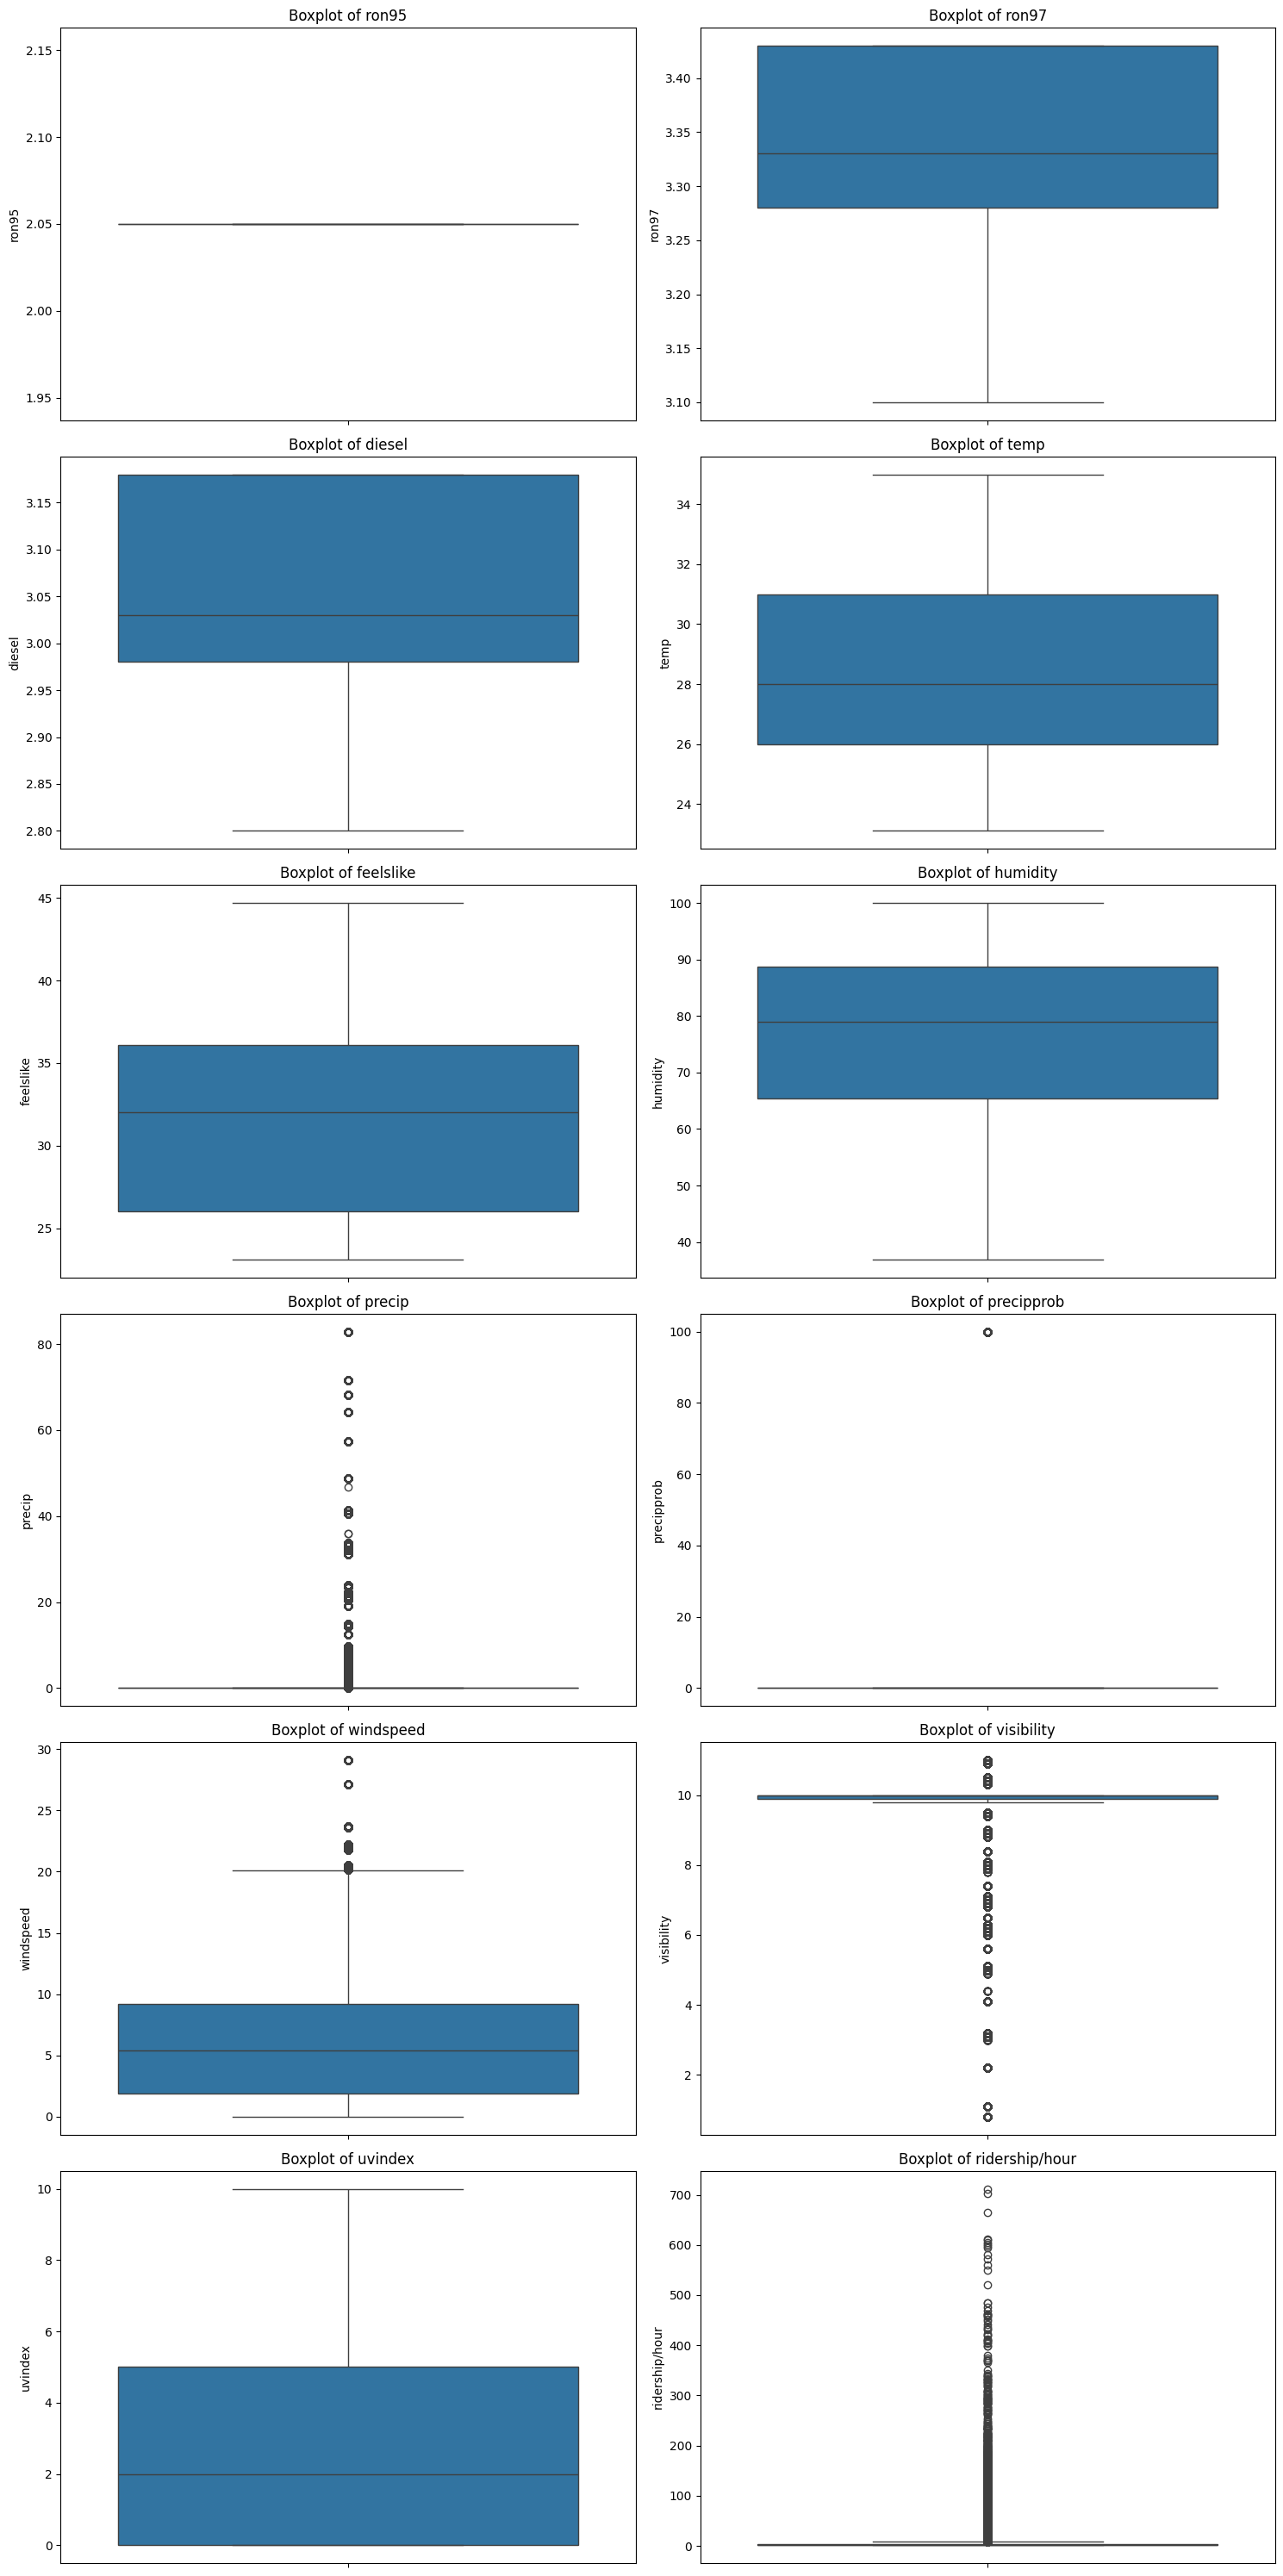

In [ ]:
# Select only numerical columns, excluding 'date' and 'time'
numerical_cols_for_outlier_check = merged_df3.select_dtypes(include=np.number).columns.tolist()

# Remove 'date' and 'time' if they were mistakenly included
if 'date' in numerical_cols_for_outlier_check:
    numerical_cols_for_outlier_check.remove('date')
if 'time' in numerical_cols_for_outlier_check:
    numerical_cols_for_outlier_check.remove('time')

# Determine the number of columns and rows for the subplots
n_cols = 2
n_rows = (len(numerical_cols_for_outlier_check) + n_cols - 1) // n_cols # Calculate the number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() # Flatten the axes array for easier iteration

# Plot boxplot for each numerical column
for i, col in enumerate(numerical_cols_for_outlier_check):
    sns.boxplot(y=merged_df3[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Specify the column you want to check for outliers
for col in numerical_cols_for_outlier_check:
  column_to_check = col

  print(f"Verifying outliers for column: {column_to_check} using Upper and Lower Fences")

  # Calculate Q1, Q3, and IQR
  Q1 = merged_df3[column_to_check].quantile(0.25)
  Q3 = merged_df3[column_to_check].quantile(0.75)
  IQR = Q3 - Q1

  # Calculate the lower and upper fences
  lower_fence = Q1 - 1.5 * IQR
  upper_fence = Q3 + 1.5 * IQR

  print(f"Q1 ({column_to_check}): {Q1}")
  print(f"Q3 ({column_to_check}): {Q3}")
  print(f"IQR ({column_to_check}): {IQR}")
  print(f"Lower Fence ({column_to_check}): {lower_fence}")
  print(f"Upper Fence ({column_to_check}): {upper_fence}")

  # Identify potential outliers
  outliers = merged_df3[(merged_df3[column_to_check] < lower_fence) | (merged_df3[column_to_check] > upper_fence)]

  if not outliers.empty:
      print(f"\nPotential outliers found in '{column_to_check}':")
      # Display relevant columns for the outlier rows
      print(outliers[['date', 'time', column_to_check]])
  else:
      print(f"\nNo data points found outside the Upper and Lower Fences in '{column_to_check}'.\n")

Verifying outliers for column: ron95 using Upper and Lower Fences
Q1 (ron95): 2.05
Q3 (ron95): 2.05
IQR (ron95): 0.0
Lower Fence (ron95): 2.05
Upper Fence (ron95): 2.05

No data points found outside the Upper and Lower Fences in 'ron95'.

Verifying outliers for column: ron97 using Upper and Lower Fences
Q1 (ron97): 3.28
Q3 (ron97): 3.43
IQR (ron97): 0.15000000000000036
Lower Fence (ron97): 3.0549999999999993
Upper Fence (ron97): 3.6550000000000007

No data points found outside the Upper and Lower Fences in 'ron97'.

Verifying outliers for column: diesel using Upper and Lower Fences
Q1 (diesel): 2.98
Q3 (diesel): 3.18
IQR (diesel): 0.20000000000000018
Lower Fence (diesel): 2.6799999999999997
Upper Fence (diesel): 3.4800000000000004

No data points found outside the Upper and Lower Fences in 'diesel'.

Verifying outliers for column: temp using Upper and Lower Fences
Q1 (temp): 26.0
Q3 (temp): 31.0
IQR (temp): 5.0
Lower Fence (temp): 18.5
Upper Fence (temp): 38.5

No data points found out

### Handling Outliers
**Handling Outliers**<br>
To mitigate the potential negative impact of extreme 'windspeed' values on machine learning models. Capping limits these extreme values to a more reasonable upper bound determined by the data distribution (the upper fence). This prevents a few very high windspeed values from overly influencing the model. The successful modification of the 'windspeed' distribution, evidenced by the capped boxplot, confirms that the outlier handling step was applied as intended. Only 'windspeed' outliers were specifically handled in this code, implying a decision was made to leave outliers in other columns (like 'ridership/hour', which often has meaningful extreme values) or handle them differently later.<br><br>

**Explaination for Not Handle Outliers:**


1.   **ridership/hour (Target Variable)**<br>
      We are likely to predict ridership/hour. Removing or heavily modifying these values could make our model unable to predict ridership accurately, which might be a critical part of the problem.<br><br>

2.   **precip (Precipitation) and precipprob (Precipitation Probability)**<br>
      High precipitation values or high probabilities of precipitation might be considered outliers compared to the average, but they represent real and significant weather events (heavy rain, thunderstorms). Heavy rain or a high chance of rain is likely to have a genuine impact on Komuter ridership (e.g., people might be less likely to take the train or delays might occur). It might not have rain every single hour, hence the value of 0 in the 'precip' column is high. Same goes to precipprob, it gives high 0 data points as it is a recorded dataset, if there is no rain, the precipprob will be 0 as well.<br><br>
3. **visibility**<br>
   Low visibility values (which would appear as outliers on the lower end of a boxplot) can represent fog, heavy rain, or haze.Poor visibility can impact travel and potentially influence transport choices or cause delays, affecting ridership. These low visibility events are real.<br><br>

The outliers in these features are likely considered meaningful and representative of real-world conditions that could influence ridership.
Removing or modifying them could reduce the predictive power of the model for those specific, impactful conditions.



In [ ]:
# Calculate the upper fence for windspeed
Q1_windspeed = merged_df3['windspeed'].quantile(0.25)
Q3_windspeed = merged_df3['windspeed'].quantile(0.75)
IQR_windspeed = Q3_windspeed - Q1_windspeed
upper_fence_windspeed = Q3_windspeed + 1.5 * IQR_windspeed

# Cap the windspeed values at the upper fence
merged_df3['windspeed'] = merged_df3['windspeed'].clip(upper=upper_fence_windspeed)

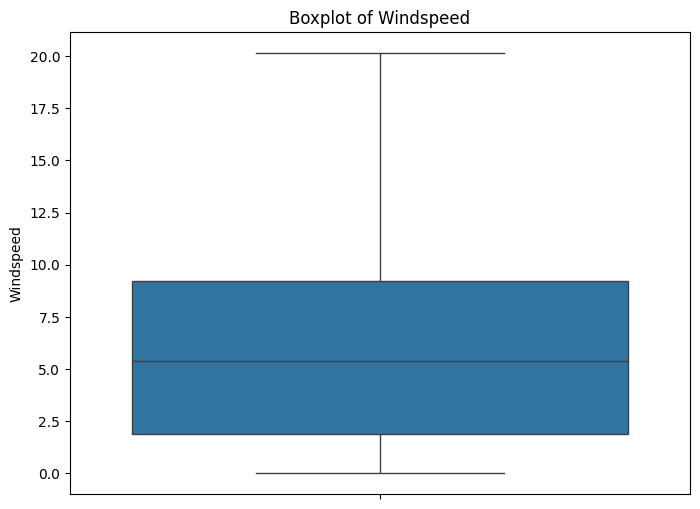

In [ ]:
# Show again the boxplot for the 'windspeed' column
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_df3['windspeed'])
plt.title('Boxplot of Windspeed')
plt.ylabel('Windspeed')
plt.show()

In [ ]:
# 'drop=True' discards the old index, otherwise it becomes a new column
merged_df3 = merged_df3.reset_index(drop=True)

# EDA for Supervised Learning


## Univariate
**Univariate**<br>
 Literally means "one variable".

In data analysis and statistics, univariate analysis is the simplest form of examining data. It focuses on describing or analyzing a single characteristic or variable of a population or sample at a time.

### ridership/hour
**What do you think about the distribution of the ridership/hour?**<br><br>

**Hypothesis:** <br>
The most hours have the lower ridership/hour, while a smaller number od hours experience much higher ridership/hour.<br><br>
**Actual:** <br>
The distribution of ridership/hour is highly skewed, with a significant presence of outliers representing peak ridership hours. This right skewed graph showing that the most hours have the lower ridership/hour.

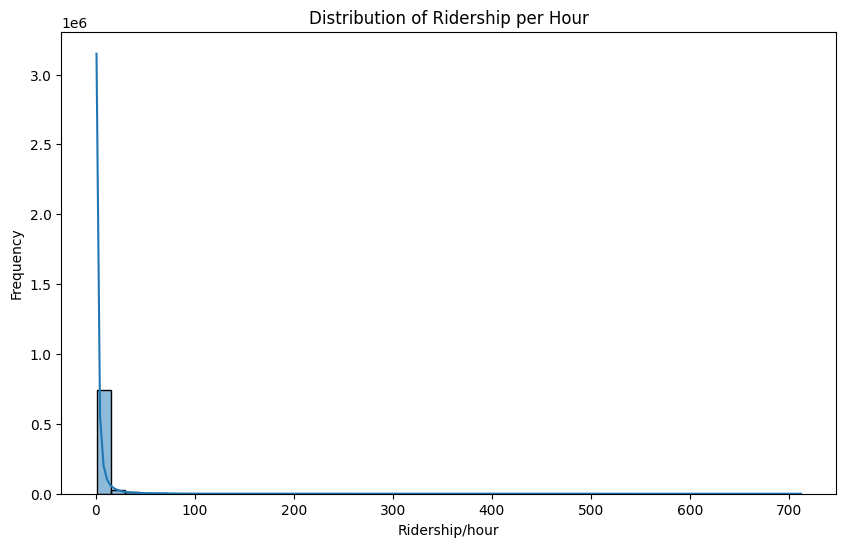

In [ ]:
# Show the ridership/hour distribution
plt.figure(figsize=(10, 6))
sns.histplot(merged_df3['ridership/hour'], bins=50, kde=True)
plt.title('Distribution of Ridership per Hour')
plt.xlabel('Ridership/hour')
plt.ylabel('Frequency')
plt.show()

## Bivariate
**Bivariate**<br>
Literally means "two variables".

In data analysis and statistics, bivariate analysis examines the relationship between two variables simultaneously. It focuses on understanding how changes in one variable are associated with changes in the other(in our case is **ridership/hour**).

### time vs ridership/hour
**What is the time that will experience higher ridership/hour?**<br><br>
**Hypothesis:** <br>
There will be distinct peaks in ridership corresponding to the morning commute (around 7:00 AM - 9:00 AM) and the evening commute (around 5:00 PM - 7:00 PM).<br><br>

**Actual:**<br>
There is three peak hours, which are 3:00 AM, 7:00 AM to 8:00 AM and 6:00 PM to 7:00 PM. Further investigation into the abnormal ridership peak observed at 3 AM revealed that it coincides with the Thaipusam celebration on February 11th, suggesting a potential link between the event and early morning travel.



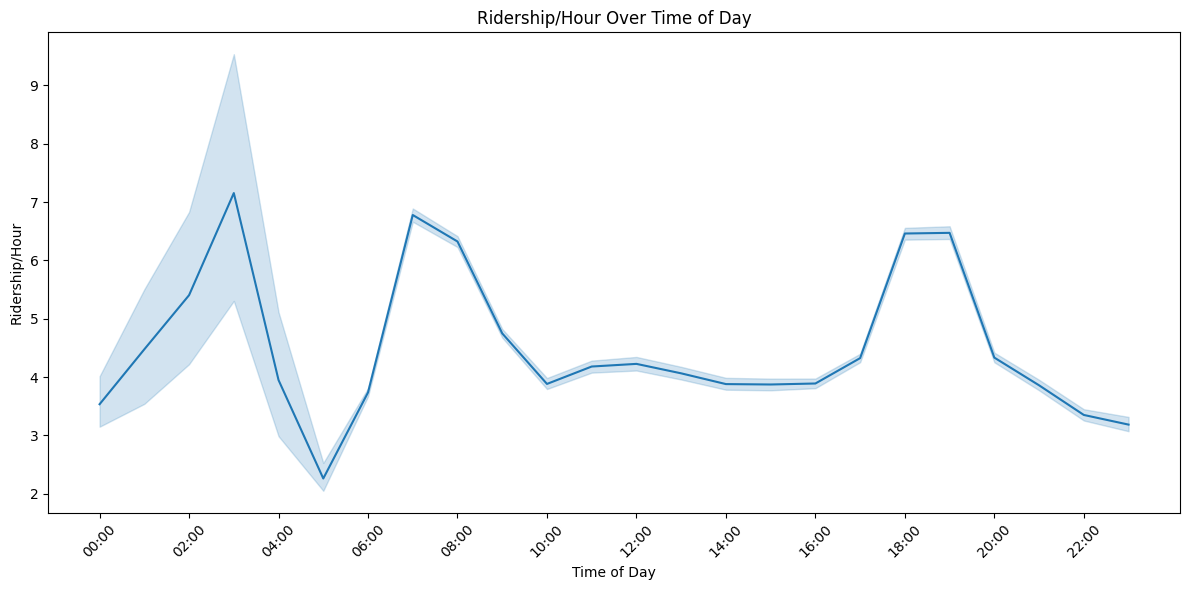

In [ ]:
# Create a plot for 'time' vs 'ridership'
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df3, x='time', y='ridership/hour')
plt.title('Ridership/Hour Over Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Ridership/Hour')

# Improve readability of x-axis labels if there are many unique times
num_labels = 12
if len(merged_df3['time'].unique()) > num_labels:
    tick_positions = merged_df3['time'].unique()[::len(merged_df3['time'].unique()) // num_labels]
    plt.xticks(tick_positions, rotation=45)
else:
    plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

In [ ]:
# Filter the DataFrame for entries at 3:00 AM
ridership_at_3am = merged_df3[merged_df3['time'] == '03:00'].copy()

# Find the row with the maximum ridership at 3:00 AM
if not ridership_at_3am.empty:
    highest_ridership_3am_row = ridership_at_3am.loc[ridership_at_3am['ridership/hour'].idxmax()]

    # Extract the date and the ridership value for the peak at 3 AM
    date_with_highest_3am_ridership = highest_ridership_3am_row['date']
    highest_3am_ridership_value = highest_ridership_3am_row['ridership/hour']

    print(f"The date with the highest ridership at 3:00 AM is: {date_with_highest_3am_ridership.strftime('%Y-%m-%d')}")
    print(f"The ridership on this date at 3:00 AM was: {highest_3am_ridership_value}")
else:
    print("No data available for 3:00 AM.")

The date with the highest ridership at 3:00 AM is: 2025-02-11
The ridership on this date at 3:00 AM was: 327


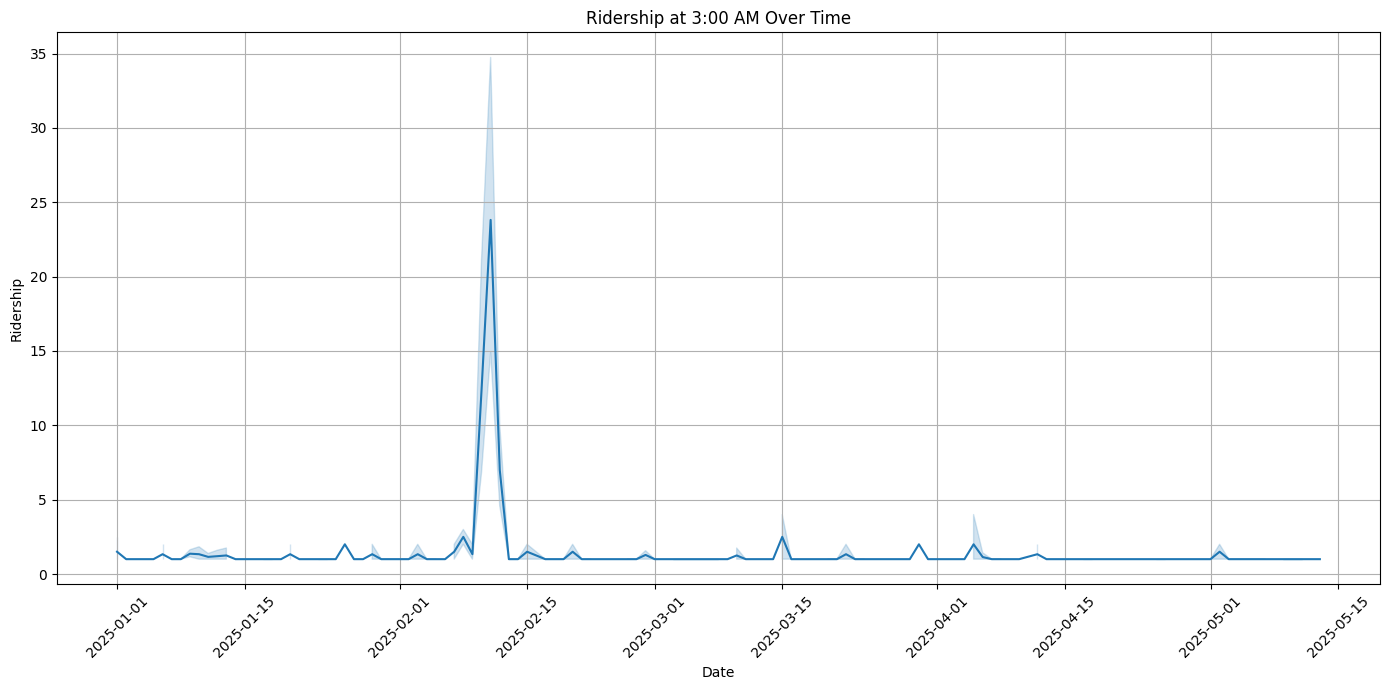

In [ ]:
# Sort by date to ensure the line plot is chronological
ridership_at_3am = ridership_at_3am.sort_values(by='date')

# Create a line plot of 'date' vs 'ridership' for the 3:00 AM data
plt.figure(figsize=(14, 7)) # Adjust figure size for better readability
sns.lineplot(data=ridership_at_3am, x='date', y='ridership/hour')
plt.title('Ridership at 3:00 AM Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Excluding Date 2025-02-11
This approach is to uncover the average hourly ridership if the 2025-02-11 is removed from the dataset due to Thaipusam, which unexpectedly pull the ridership/hour at 3am.<br><br>

**Result:**<br>
It shows the peak hour changed to 7:00 AM - 8:00 AM and 6:00 PM - 7:00 PM, which are similar as our hypothesis.


Original rows: 786170
Rows after excluding 2025-02-11: 777957
Rows removed: 8213


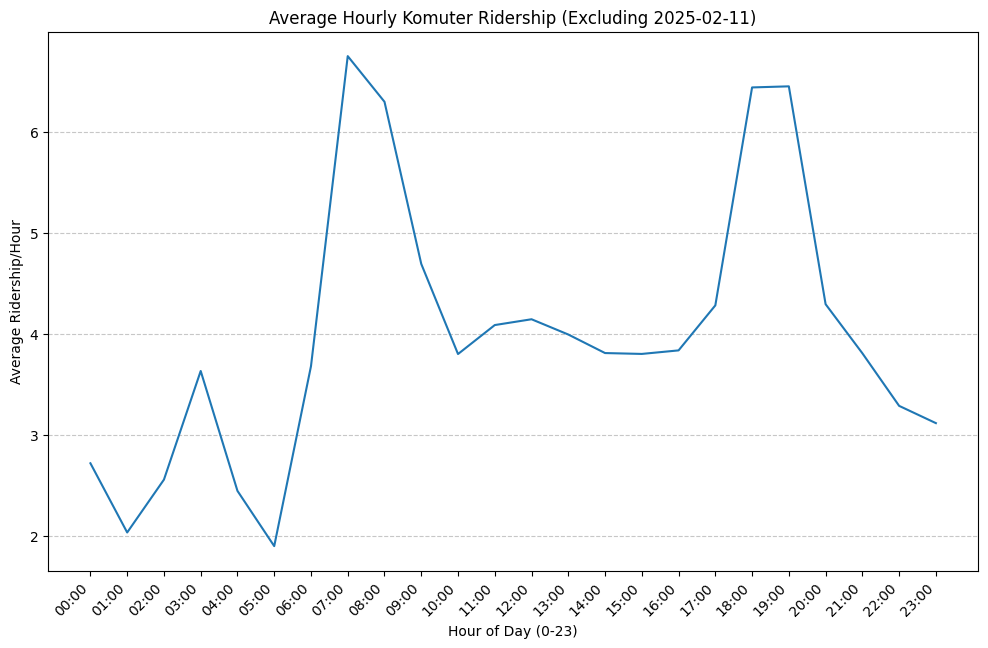


Average ridership per hour (Excluding 2025-02-11):
     time  ridership/hour
0   00:00        2.717664
1   01:00        2.032032
2   02:00        2.555746
3   03:00        3.632159
4   04:00        2.444158
5   05:00        1.896672
6   06:00        3.679379
7   07:00        6.752304
8   08:00        6.299711
9   09:00        4.693314
10  10:00        3.800130
11  11:00        4.087311
12  12:00        4.144856
13  13:00        3.993568
14  14:00        3.809922
15  15:00        3.801277
16  16:00        3.836303
17  17:00        4.282265
18  18:00        6.442135
19  19:00        6.452894
20  20:00        4.294078
21  21:00        3.807954
22  22:00        3.286623
23  23:00        3.115521


In [ ]:
# Define the date to exclude
excluded_date = '2025-02-11'

# Filter out the rows for the excluded date
# Create a boolean mask where the date is NOT the excluded date
filtered_df = merged_df3[merged_df3['date'].dt.strftime('%Y-%m-%d') != excluded_date].copy()

# Check how many rows were removed (optional)
original_rows = len(merged_df3)
filtered_rows = len(filtered_df)
print(f"Original rows: {original_rows}")
print(f"Rows after excluding {excluded_date}: {filtered_rows}")
print(f"Rows removed: {original_rows - filtered_rows}")

# Group the filtered DataFrame by hour and calculate the average ridership
hourly_ridership_filtered = filtered_df.groupby('time')['ridership/hour'].mean().reset_index()

# Sort by hour
hourly_ridership_filtered = hourly_ridership_filtered.sort_values(by='time')

# Plotting the average ridership per hour (excluding the specific date)
plt.figure(figsize=(12, 7))
sns.lineplot(data=hourly_ridership_filtered, x='time', y='ridership/hour')
plt.title(f'Average Hourly Komuter Ridership (Excluding {excluded_date})')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Ridership/Hour')
plt.xticks(range(0, 24), rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Look at the data table for the filtered result
print(f"\nAverage ridership per hour (Excluding {excluded_date}):")
print(hourly_ridership_filtered)

### date vs ridership/hour
**What is the date will experience higher ridership/hour?**<br><br>
**Hypothesis:**<br>
Ridership on date in which is a public holiday will have the higher ridership/hour.<br><br>

**Actual:**<br>
We observe an interesting peak around 10 Feb, furthur investigation found out the exact date is 11 Feb, which is the date of Thaipusam 2025. Hence, it match with our hypothesis.


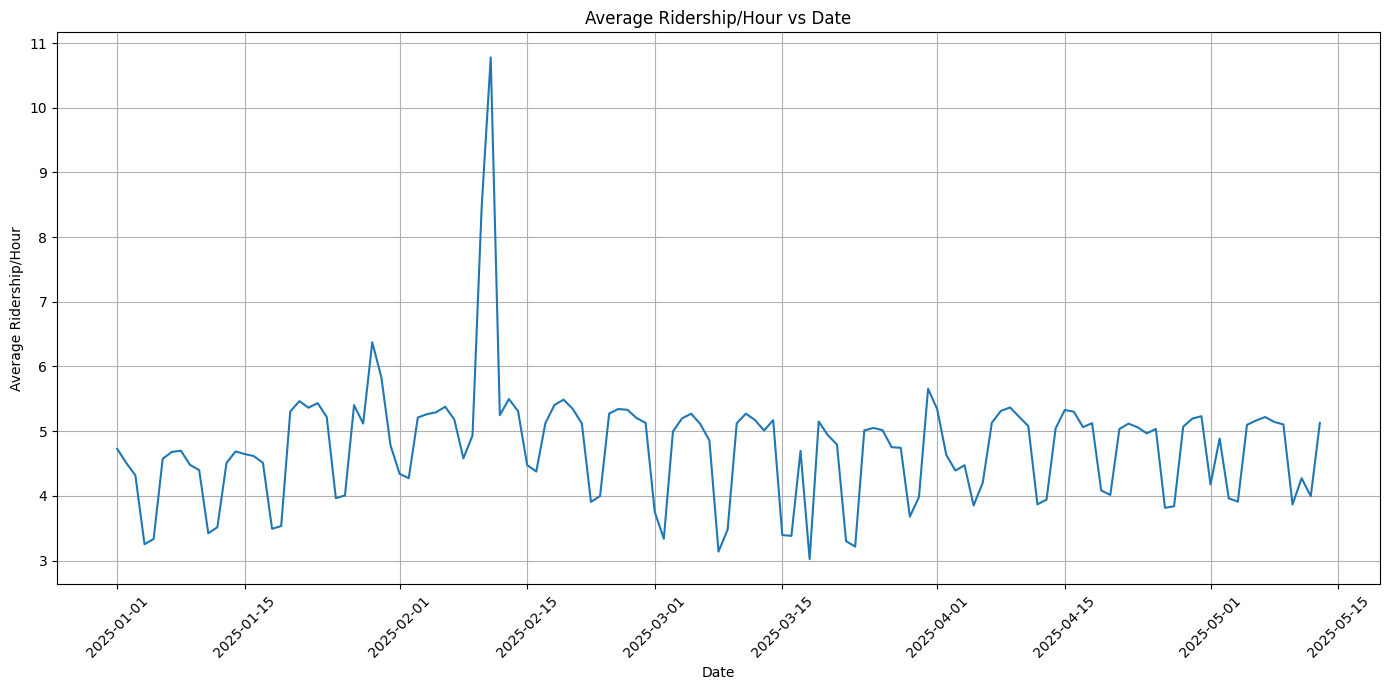

In [ ]:
# Calculate the average ridership for each date
# This is necessary as you likely have multiple ridership entries per day
daily_average_ridership = merged_df3.groupby('date')['ridership/hour'].mean().reset_index()

# Create a line plot of 'date' vs 'average_ridership'
plt.figure(figsize=(14, 7)) # Adjust figure size for better readability
sns.lineplot(data=daily_average_ridership, x='date', y='ridership/hour')
plt.title('Average Ridership/Hour vs Date')
plt.xlabel('Date')
plt.ylabel('Average Ridership/Hour')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the average ridership for each date
daily_average_ridership = merged_df3.groupby('date')['ridership/hour'].mean().reset_index()

# Find the row with the maximum ridership
highest_ridership_date_row = daily_average_ridership.loc[daily_average_ridership['ridership/hour'].idxmax()]

# Extract the date and the ridership value
date_with_highest_ridership = highest_ridership_date_row['date']
highest_ridership_value = highest_ridership_date_row['ridership/hour']

print(f"The date with the highest average ridership/hour is: {date_with_highest_ridership.strftime('%Y-%m-%d')}")
print(f"The average ridership/hour on this date was: {highest_ridership_value:.2f}")

The date with the highest average ridership/hour is: 2025-02-11
The average ridership/hour on this date was: 10.78


### origin vs ridership/hour
**Which origin station has the highest average ridership/hour?**<br><br>

**Hypothesis:**<br>
1. KL Sentral - it is Malaysia's largest and busiest transportation hub.
2. Batu Caves - it is a major tourist attraction and many tourists use commuter because it's the most convenient and direct way to reach the site from downtown KL.
3. Kajang - it is an interchange with the MRT, which will increase the foot traffic.
<br><br>
**Actual:**<br>
We found that Batu Caves has the highest and significant amount of ridership/hour.

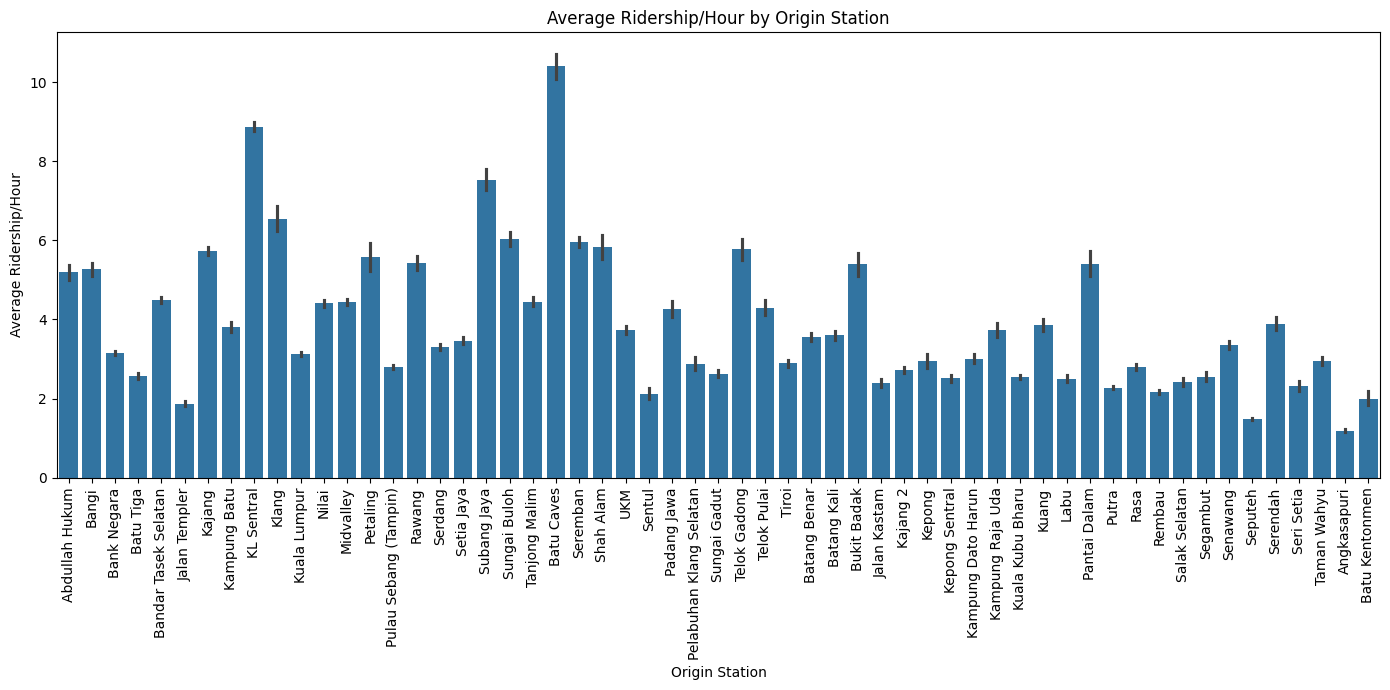

In [ ]:
# Create a bar plot of 'origin' vs 'ridership/hour'
plt.figure(figsize=(14, 7))
sns.barplot(data=merged_df3, x='origin', y='ridership/hour', errorbar='ci') # 'ci' shows confidence interval
plt.title('Average Ridership/Hour by Origin Station')
plt.xlabel('Origin Station')
plt.ylabel('Average Ridership/Hour')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'origin' and calculate the average ridership
average_ridership_by_origin = merged_df3.groupby('origin')['ridership/hour'].mean().reset_index()

# Sort the origins by average ridership in descending order
top_10_origins = average_ridership_by_origin.sort_values(by='ridership/hour', ascending=False).head(10)

# Display the top 10 origins and their average ridership
print("Top 10 Origin Stations by Average Ridership:")
print(top_10_origins)

Top 10 Origin Stations by Average Ridership:
          origin  ridership/hour
7     Batu Caves       10.405919
13    KL Sentral        8.872919
48   Subang Jaya        7.529378
21         Klang        6.538129
49  Sungai Buloh        6.035089
43      Seremban        5.947894
47     Shah Alam        5.833370
53  Telok Gadong        5.773171
14        Kajang        5.739518
31      Petaling        5.582839


### destination vs ridership/hour
**Which origin station has the highest average ridership/hour?**<br><br>

**Hypothesis:**<br>

1. KL Sentral - it is Malaysia's largest and busiest transportation hub.
2. Batu Caves - it is a major tourist attraction and many tourists use commuter because it's the most convenient and direct way to reach the site from downtown KL.
3. Subang Jaya - it serves as an interchange for multiple rail lines. Besides, the station is located near several major colleges and universities, such as Taylor's University, Monash University Malaysia, Sunway University and so on.
<br><br>
**Actual:**<br>
We found that Subang Jaya has the highest and significant amount of ridership/hour.

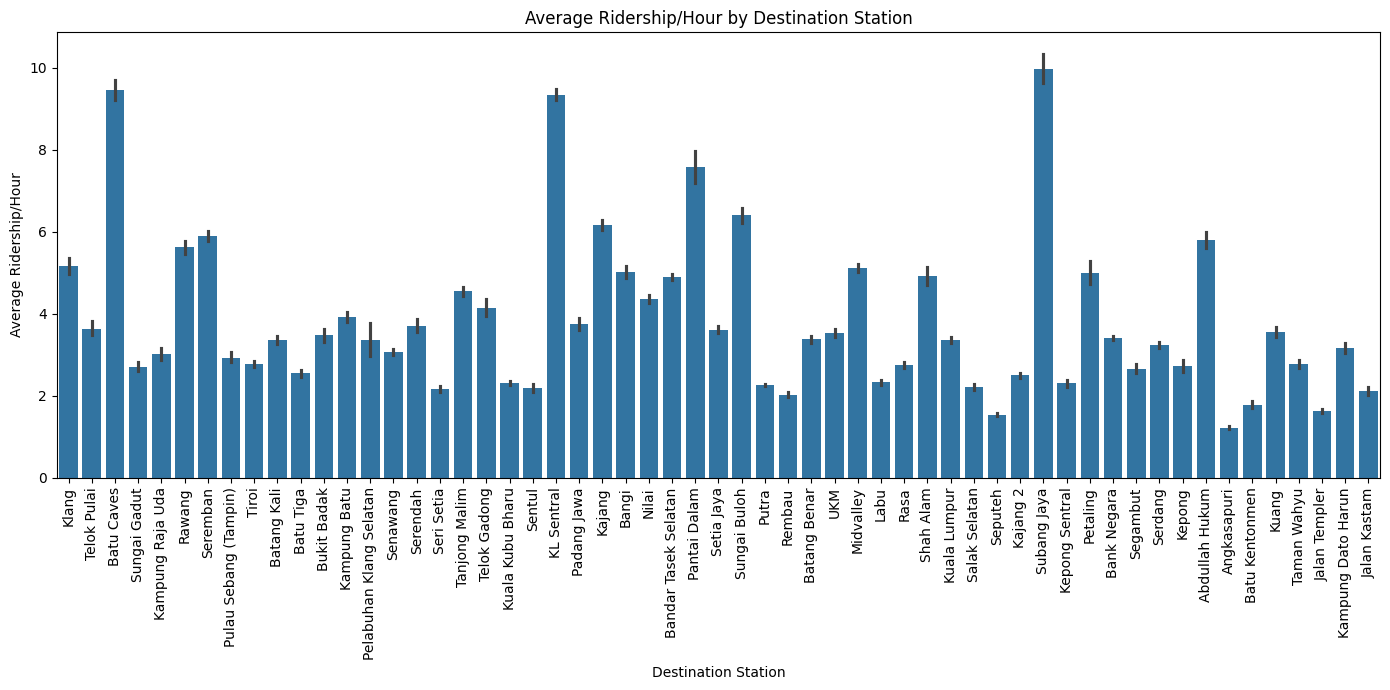

In [ ]:
# Create a bar plot of 'destination' vs 'ridership'
plt.figure(figsize=(14, 7))
sns.barplot(data=merged_df3, x='destination', y='ridership/hour', errorbar='ci') # 'ci' shows confidence interval
plt.title('Average Ridership/Hour by Destination Station')
plt.xlabel('Destination Station')
plt.ylabel('Average Ridership/Hour')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'destination' and calculate the average ridership
average_ridership_by_destination = merged_df3.groupby('destination')['ridership/hour'].mean().reset_index()

# Sort the destinations by average ridership in descending order
top_10_destinations = average_ridership_by_destination.sort_values(by='ridership/hour', ascending=False).head(10)

# Display the top 10 destinations and their average ridership
print("\nTop 10 Destination Stations by Average Ridership:")
print(top_10_destinations)


Top 10 Destination Stations by Average Ridership:
       destination  ridership/hour
48     Subang Jaya        9.980741
7       Batu Caves        9.466402
13      KL Sentral        9.335750
29    Pantai Dalam        7.566212
49    Sungai Buloh        6.395356
14          Kajang        6.163439
43        Seremban        5.891262
0   Abdullah Hukum        5.791275
35          Rawang        5.620341
21           Klang        5.158405


### isHoliday vs ridership/hour
**How holiday affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The ridership/hour will increase if it is a holiday since students and workers will take the chance to go shopping and enjoy their holiday.<br><br>

**Actual:**<br>
Ridership/hour will be higher during the holidays.

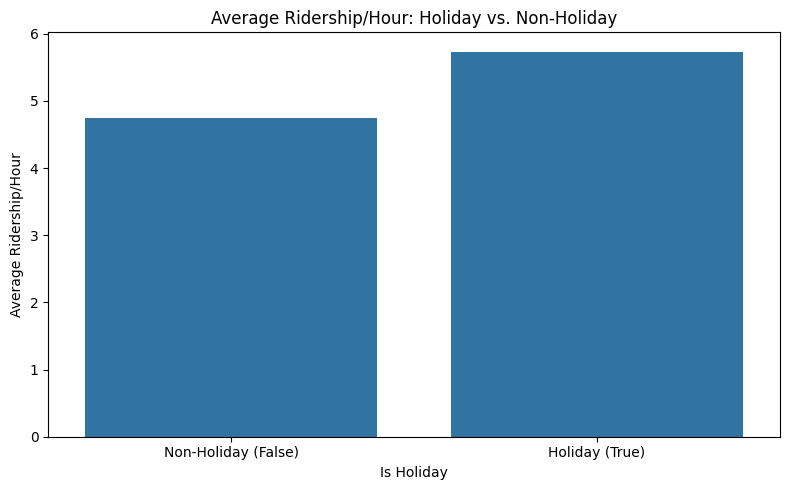

In [ ]:
# Calculate the average ridership for each 'isHoliday' category
average_ridership_by_holiday = merged_df3.groupby('isHoliday')['ridership/hour'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(8, 5)) # Adjust figure size as needed
sns.barplot(data=average_ridership_by_holiday, x='isHoliday', y='ridership/hour')
plt.title('Average Ridership/Hour: Holiday vs. Non-Holiday')
plt.xlabel('Is Holiday')
plt.ylabel('Average Ridership/Hour')
plt.xticks(ticks=[0, 1], labels=['Non-Holiday (False)', 'Holiday (True)']) # Improve x-axis labels
plt.tight_layout()
plt.show()

### isWeekend vs ridership/hour
**How weekend affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The ridership/hour will increase if it is a weekend.<br><br>

**Actual:**<br>
Ridership/hour will be higher during the weekdays.

<ipython-input-71-37ccc56dd403>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_ridership_by_weekend, x='isWeekend', y='ridership/hour', palette='coolwarm') # Use a color palette


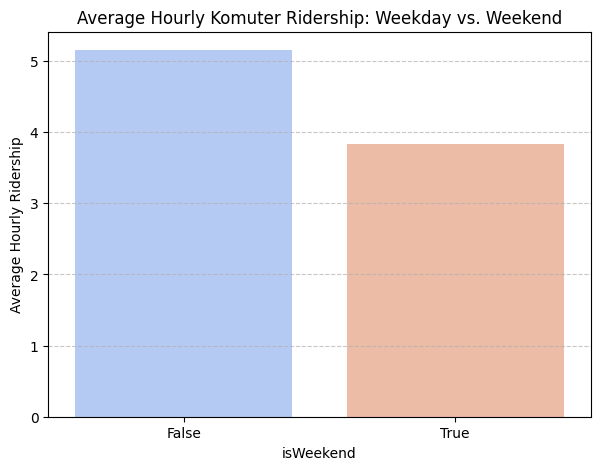

In [ ]:
# Calculate the average ridership for each 'isHoliday' category
average_ridership_by_weekend = merged_df3.groupby('isWeekend')['ridership/hour'].mean().reset_index()

# Plotting the average hourly ridership for weekdays and weekends using a bar plot
plt.figure(figsize=(7, 5)) # Smaller figure as there are only two bars
sns.barplot(data=average_ridership_by_weekend, x='isWeekend', y='ridership/hour', palette='coolwarm') # Use a color palette
plt.title('Average Hourly Komuter Ridership: Weekday vs. Weekend')
plt.xlabel('isWeekend')
plt.ylabel('Average Hourly Ridership')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ron95 vs ridership/hour
**How ron95 affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The higher the price of ron95, the higher the ridership/hour.
<br><br>
**Actual:**<br>
Since the fuel price of ron95 is consistent over the year, this feature seems not affected the ridership/hour.

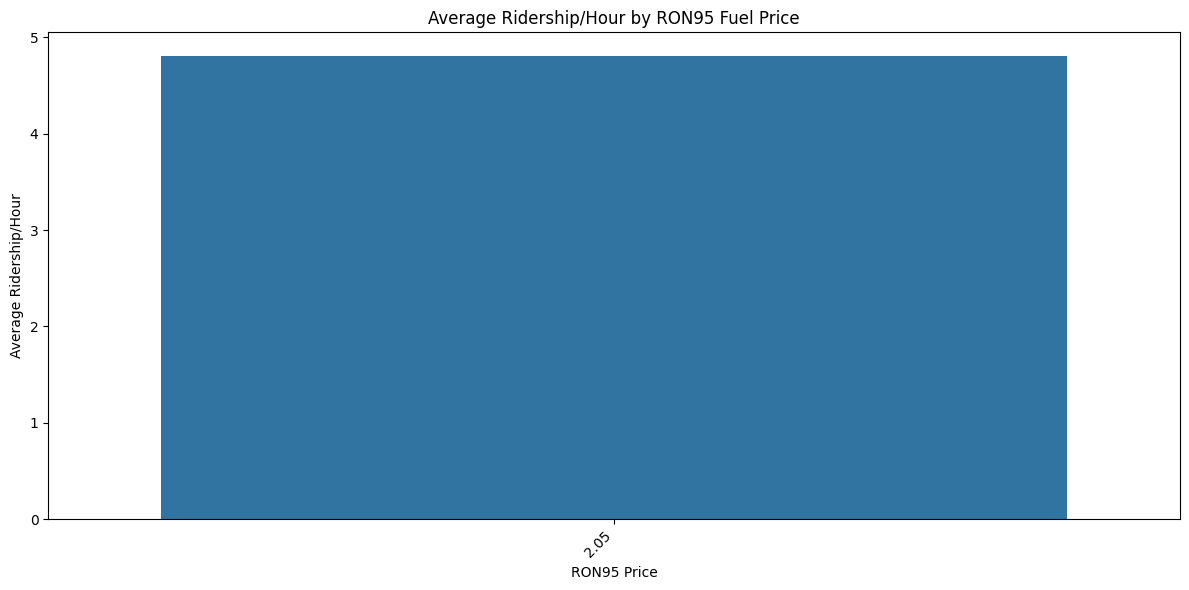

In [ ]:
# Calculate the average ridership for each unique RON95 price
average_ridership_by_ron95 = merged_df3.groupby('ron95')['ridership/hour'].mean().reset_index()

# Sort by RON95 price for better visualization
average_ridership_by_ron95 = average_ridership_by_ron95.sort_values(by='ron95')

# Create a bar plot
plt.figure(figsize=(12, 6)) # Adjust figure size
sns.barplot(data=average_ridership_by_ron95, x='ron95', y='ridership/hour', errorbar='ci') # 'ci' shows confidence interval
plt.title('Average Ridership/Hour by RON95 Fuel Price')
plt.xlabel('RON95 Price')
plt.ylabel('Average Ridership/Hour')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### ron97 vs ridership/hour
**How ron97 affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The higher the price of ron97, the higher the ridership/hour. This suggests that as ron97 becomes more expensive, individuals may be more inclined to choose the Komuter as an alternative to driving.
<br><br>
**Actual:**<br>
When the ron97 price reached 3.43, the average ridership was at its peak, which in turn prove our hypothesis.

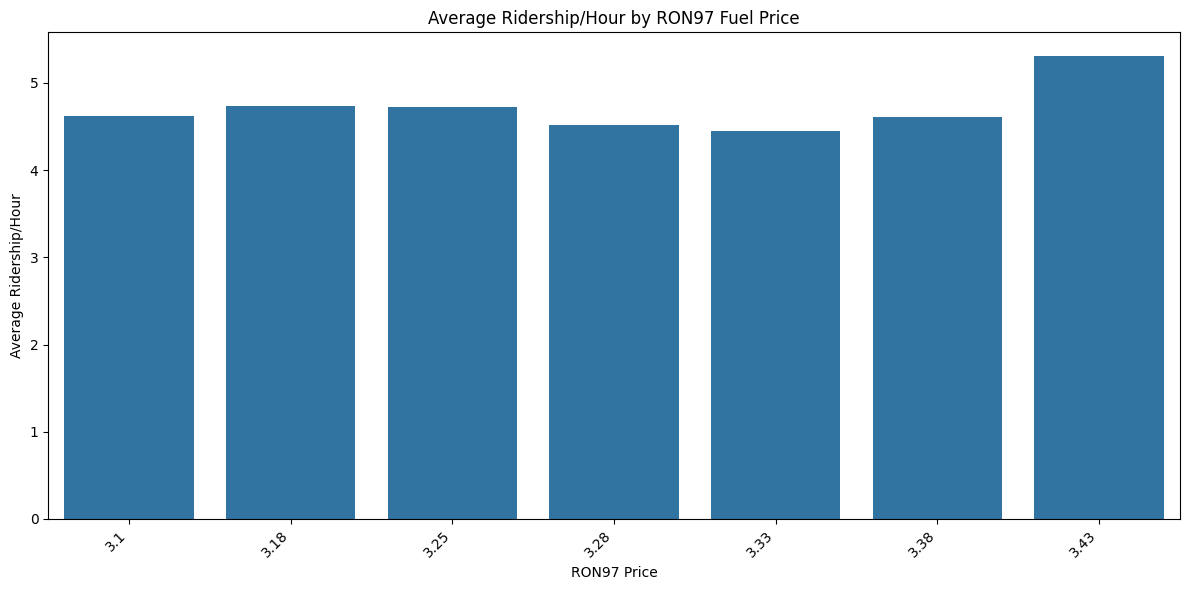

In [ ]:
# Calculate the average ridership for each unique RON97 price
average_ridership_by_ron97 = merged_df3.groupby('ron97')['ridership/hour'].mean().reset_index()

# Sort by RON97 price for better visualization
average_ridership_by_ron97 = average_ridership_by_ron97.sort_values(by='ron97')

# Create a bar plot
plt.figure(figsize=(12, 6)) # Adjust figure size
sns.barplot(data=average_ridership_by_ron97, x='ron97', y='ridership/hour', errorbar='ci') # 'ci' shows confidence interval
plt.title('Average Ridership/Hour by RON97 Fuel Price')
plt.xlabel('RON97 Price')
plt.ylabel('Average Ridership/Hour')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### diesel vs ridership/hour
**How diesel affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The higher the price of diesel, the higher the ridership/hour.
<br><br>
**Actual:**<br>
When the diesel price reached 3.18, the average ridership was at its peak, which in turn prove our hypothesis.

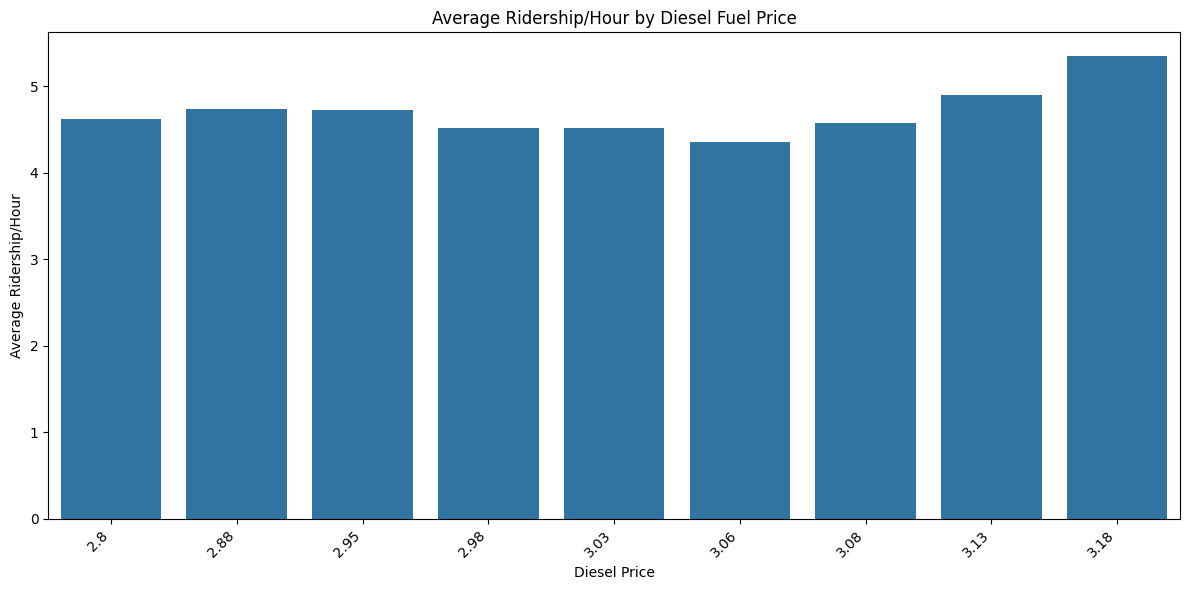

In [ ]:
# Calculate the average ridership for each unique Diesel price
average_ridership_by_diesel = merged_df3.groupby('diesel')['ridership/hour'].mean().reset_index()

# Sort by Diesel price for better visualization
average_ridership_by_diesel = average_ridership_by_diesel.sort_values(by='diesel')

# Create a bar plot
plt.figure(figsize=(12, 6)) # Adjust figure size
sns.barplot(data=average_ridership_by_diesel, x='diesel', y='ridership/hour', errorbar='ci') # 'ci' shows confidence interval
plt.title('Average Ridership/Hour by Diesel Fuel Price')
plt.xlabel('Diesel Price')
plt.ylabel('Average Ridership/Hour')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### temp vs ridership/hour
**How temperature affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The temperature in the range of 26°C to 30°C will having the highest ridership/hour.
<br><br>
**Actual:**<br>
The highest ridership/hour occurs at a temperature around 26°C.

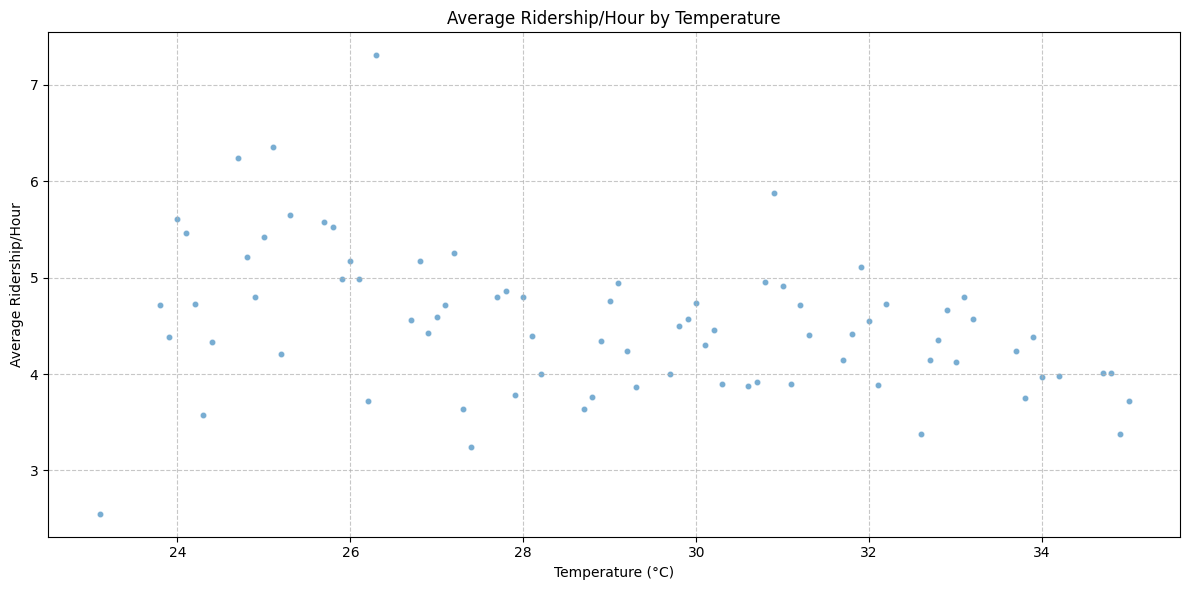

In [ ]:
# Calculate the average ridership for each unique temperature value
average_ridership_by_temp = merged_df3.groupby('temp')['ridership/hour'].mean().reset_index()

# Sort by temperature for better visualization
average_ridership_by_temp = average_ridership_by_temp.sort_values(by='temp')

# Create a scatter plot instead of a bar plot for a continuous variable like temperature
plt.figure(figsize=(12, 6)) # Adjust figure size
# Use scatterplot as temp is continuous
sns.scatterplot(data=average_ridership_by_temp, x='temp', y='ridership/hour', alpha=0.6, s=20) # Adjust point size/alpha
plt.title('Average Ridership/Hour by Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average Ridership/Hour')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### feelslike vs ridership/hour
**How feelslike(temperature) affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The feelslike in the range of 26°C to 30°C will having the highest ridership/hour.
<br><br>
**Actual:**<br>
The highest ridership/hour occurs at a temperature around 26°C.

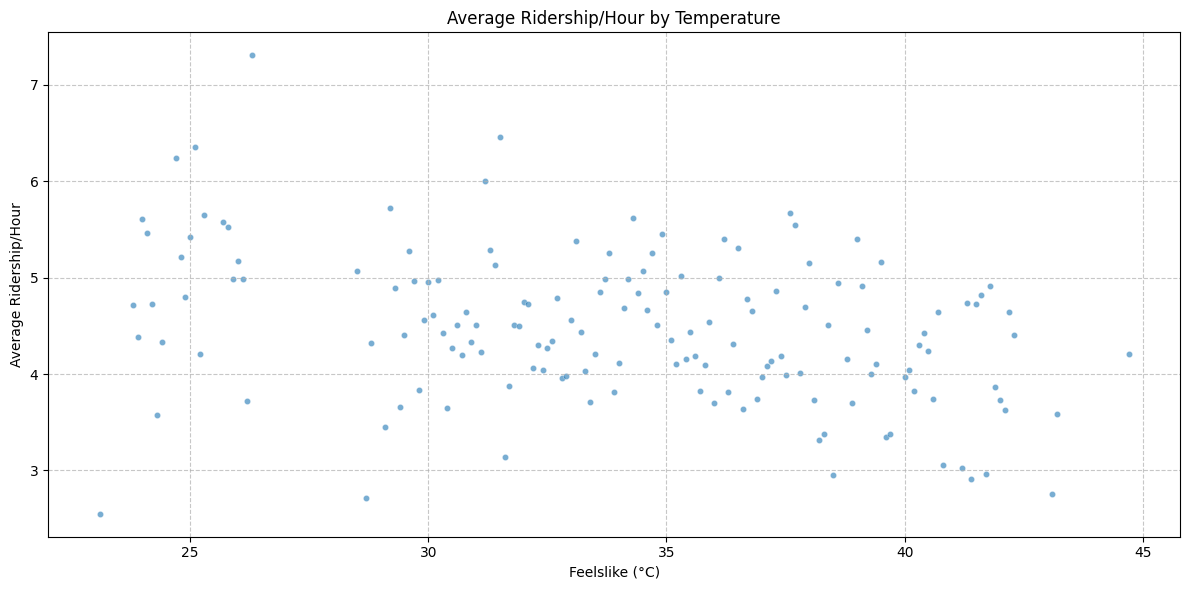

In [ ]:
# Calculate the average ridership for each unique feelslike value
average_ridership_by_feelslike = merged_df3.groupby('feelslike')['ridership/hour'].mean().reset_index()

# Sort by feelslike for better visualization
average_ridership_by_feelslike = average_ridership_by_feelslike.sort_values(by='feelslike')

# Create a scatter plot instead of a bar plot for a continuous variable like temperature
plt.figure(figsize=(12, 6)) # Adjust figure size
# Use scatterplot as feelslike is continuous
sns.scatterplot(data=average_ridership_by_feelslike, x='feelslike', y='ridership/hour', alpha=0.6, s=20) # Adjust point size/alpha
plt.title('Average Ridership/Hour by Temperature')
plt.xlabel('Feelslike (°C)')
plt.ylabel('Average Ridership/Hour')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Multivariate
**Multivariate**<br>
Literally means "many variables".

In data analysis and statistics, multivariate analysis examines the relationships among three or more variables simultaneously. It focuses on understanding how multiple variables interact with each other and how they collectively influence an outcome (which, in our case, is ridership/hour).

### origin vs time vs ridership/hour
**How origin and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The peak hours on the business districts or near office commuter line will more likely to have the higher ridership/hour such as 7:00 AM - 9:00 AM and 5:00 PM to 7:00 PM at the Subang Jaya, KL Sentral and Kepong.
<br><br>
**Actual:**<br>
Further investigation found that:
1. Taman Wahyu (1:00 AM and 3:00 AM) - around 30 riderships for 1:00 AM and around 20 for 3:00 AM
2. tanjong Malim (7:00 AM to 11:00 AM) - around 7 riderships
3. Bukit Badak (7:00 AM) - around 9 riderships
4. KL Sentral (5:00 PM to 7:00 PM) - around 20 riderships
5. Batu Caves (3:00 AM) - around 30 riderships
6. Rawang (7:00 AM) - around 20 riderships
7. Sentul (3:00 AM) - around 12 riderships
8. Bangi (7:00 AM) - around 15 riderships
9. Petaling (8:00 AM) - around 18 riderships
10. Kajang (7:00 PM) - around 15 riderships
11. Kuang (7:00 AM to 8:00 AM) - around 9 riderships
12. Seri Setia (12:00 AM) -  around 18 riderships
13. Shah Alam (7:00 AM) - around 14 riderships
14. Subang Jaya (7:00 PM) - around 25 riderships
15. Serendah (7:00 AM) - around 10 riderships
16. Sungai Buloh (6:00 PM to 7:00 PM) - around 16 riderships
17. Pantai Dalam (7:00 AM) - around 16 riderships
18. Seremban (7:00 AM) - around 14 riderships
19. UKM (7:00 AM) - around 10 riderships
20. Bandar Tasek Selatan (8:00 AM and 6:00 PM to 7:00 PM) - around 7 riderships for both

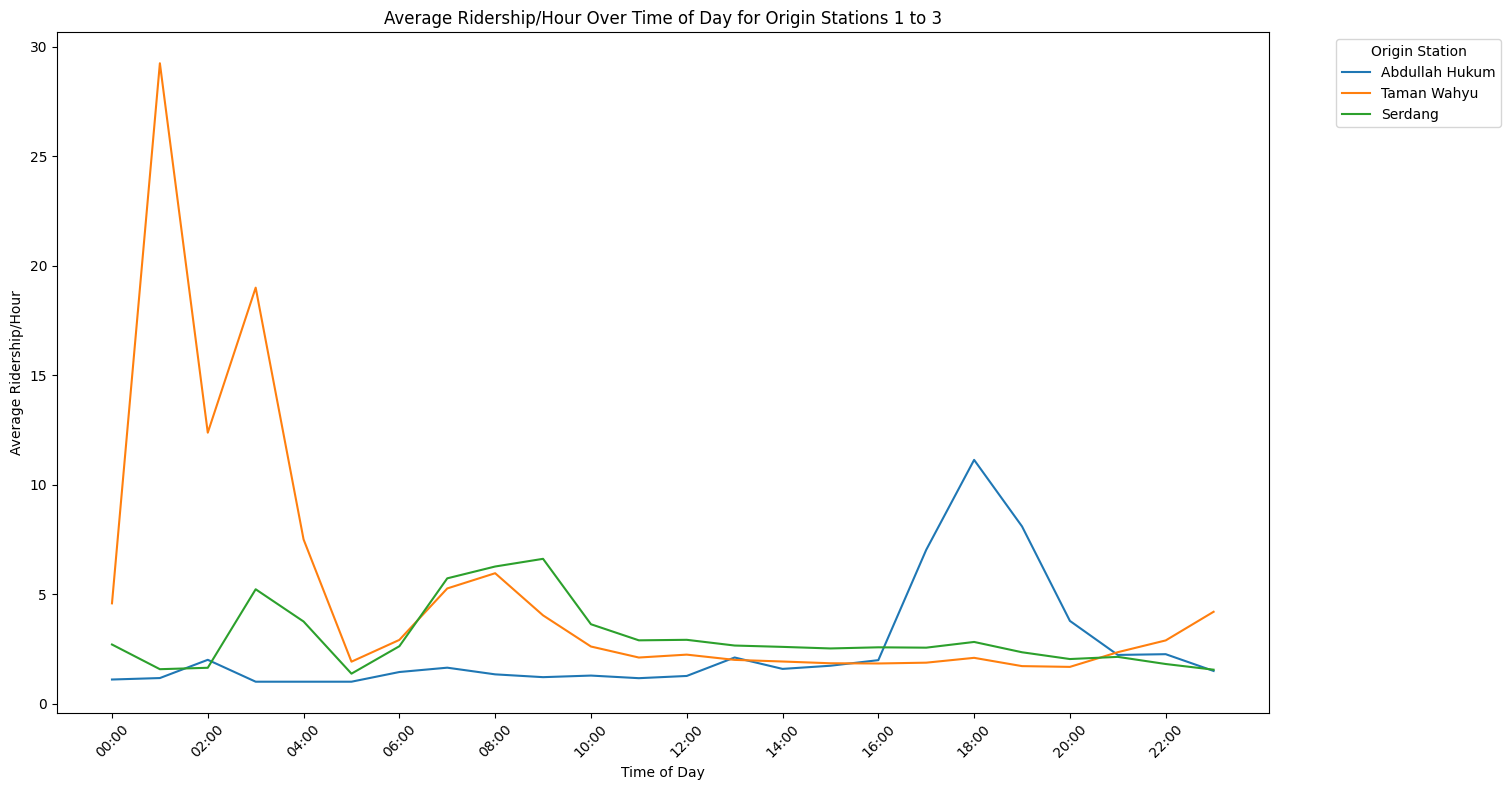

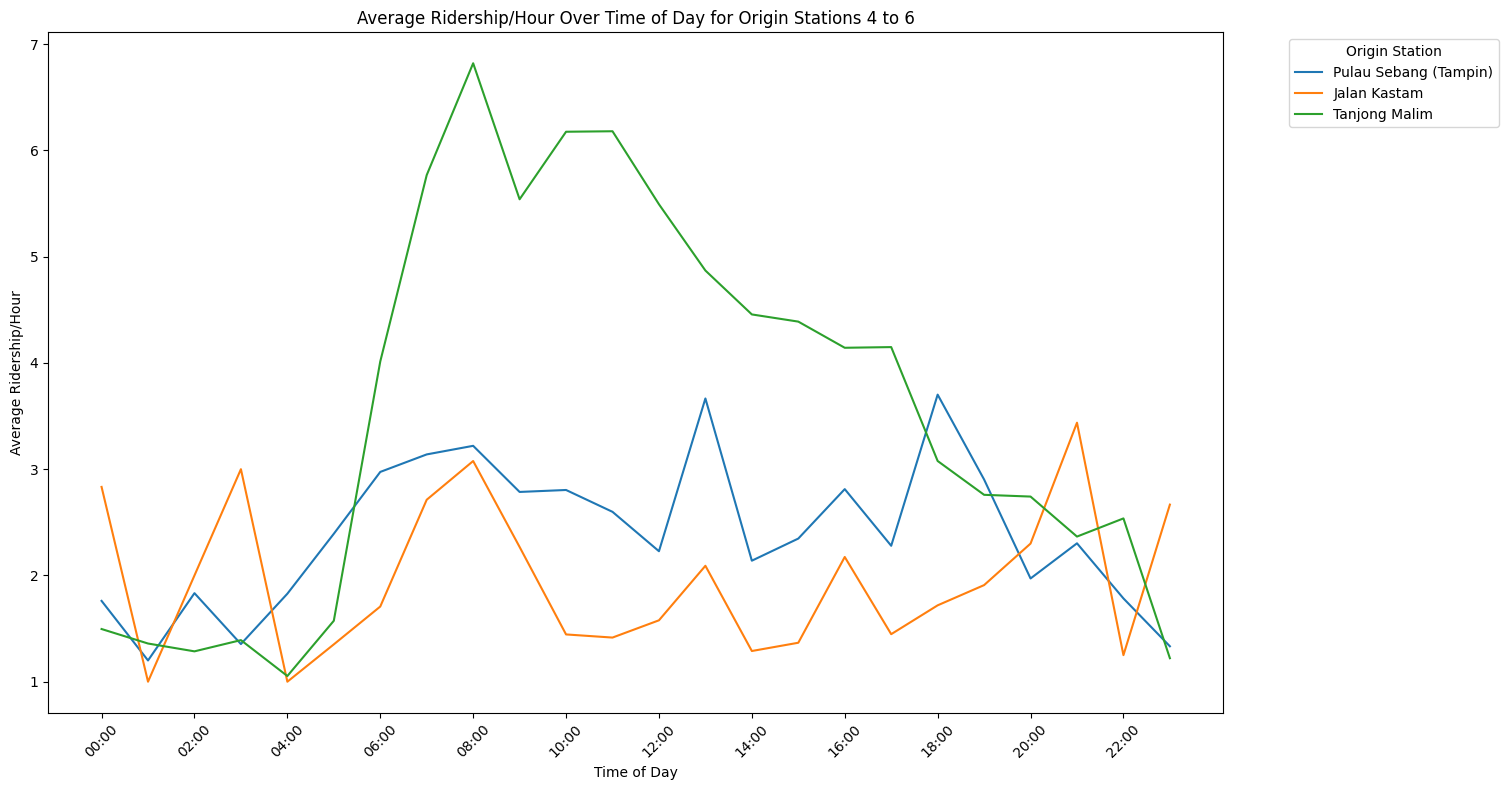

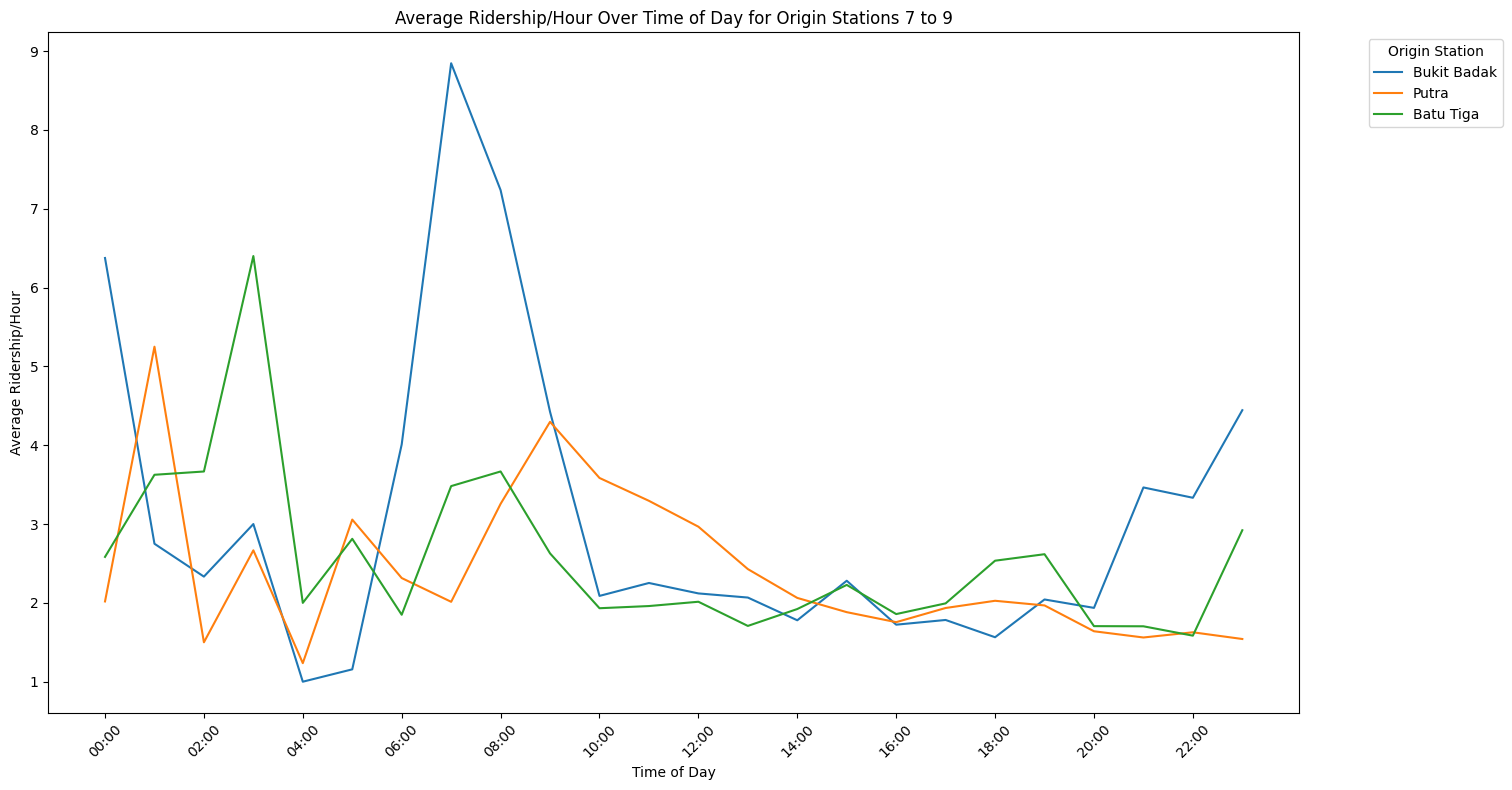

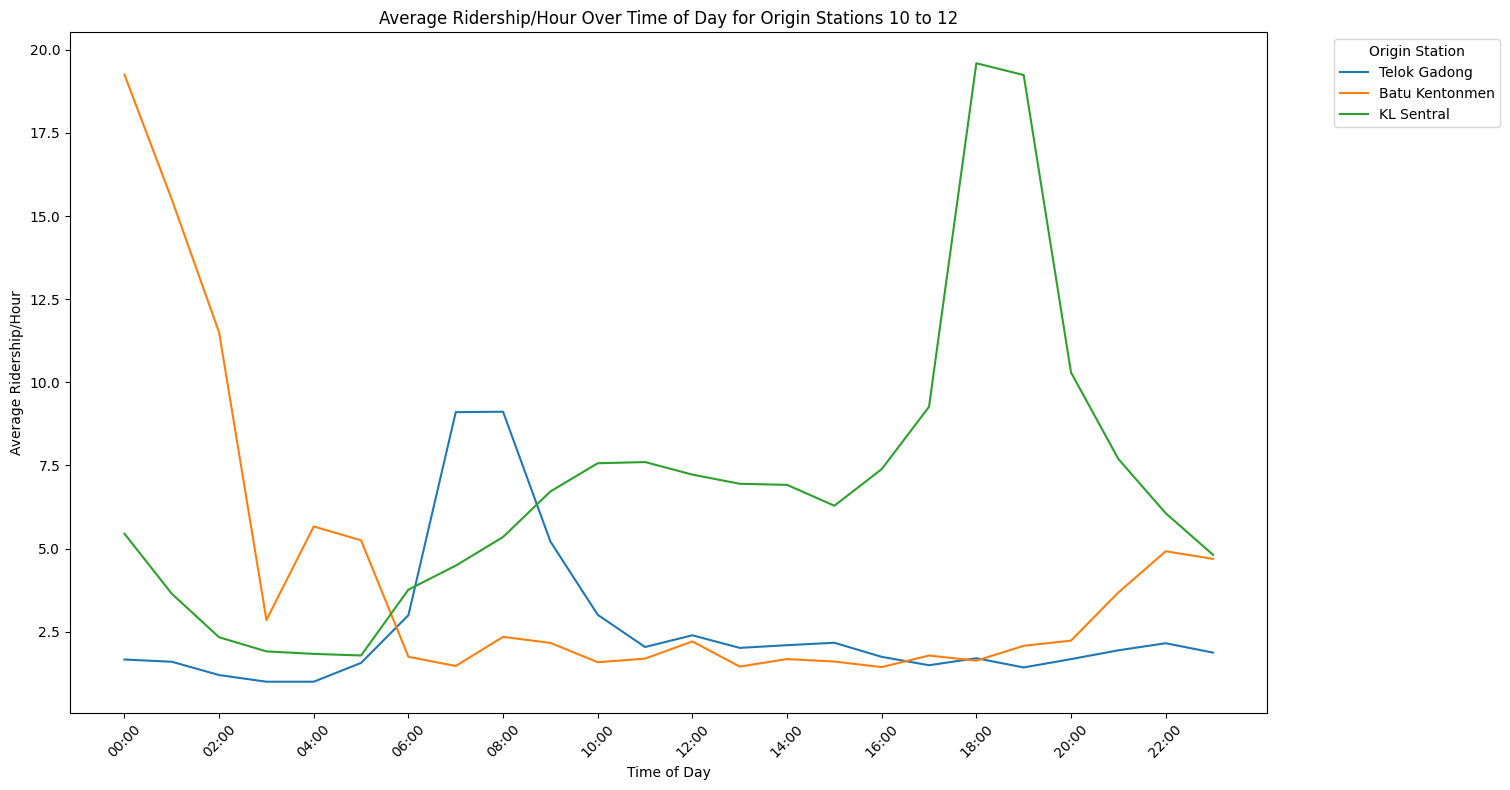

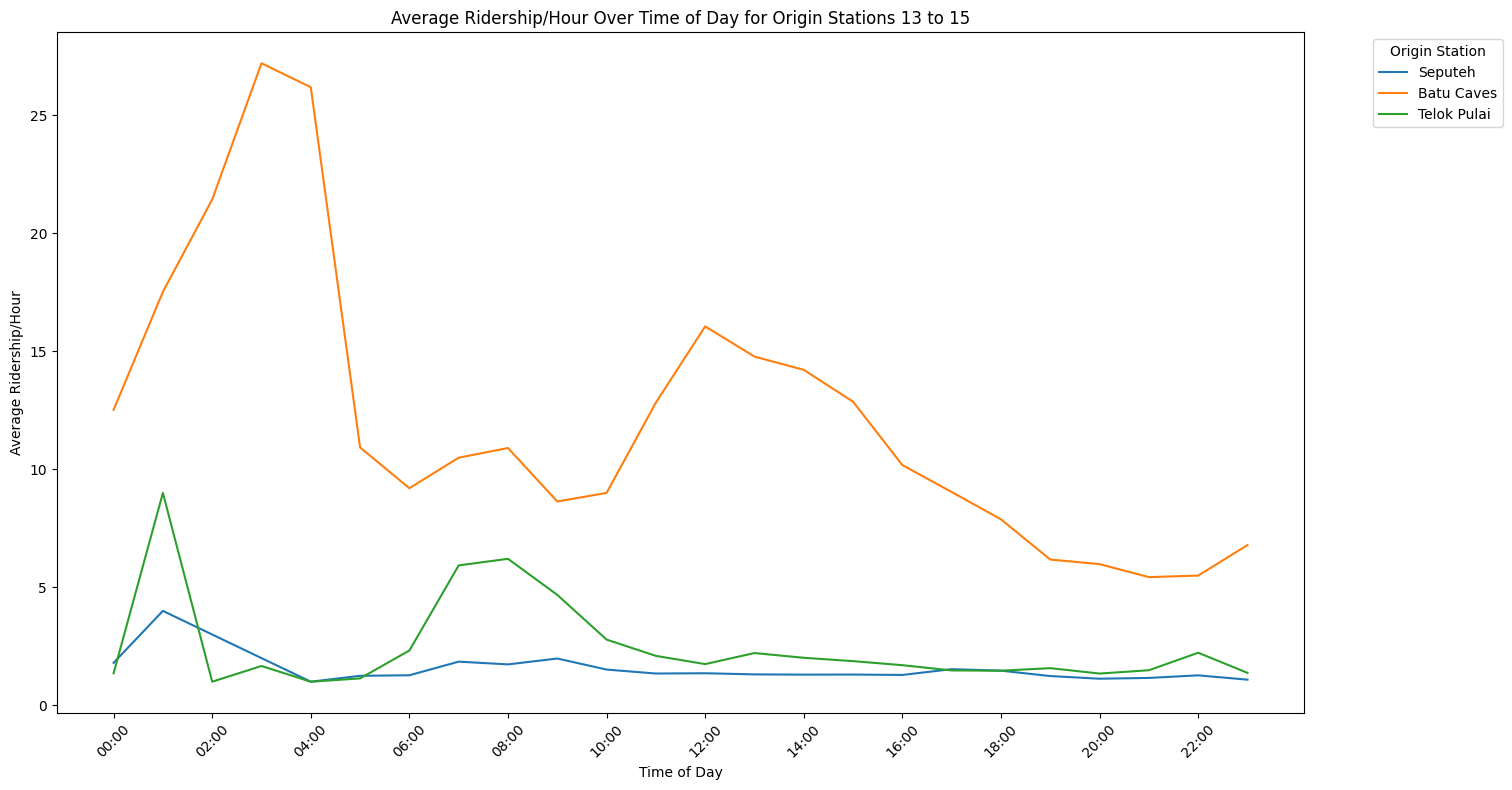

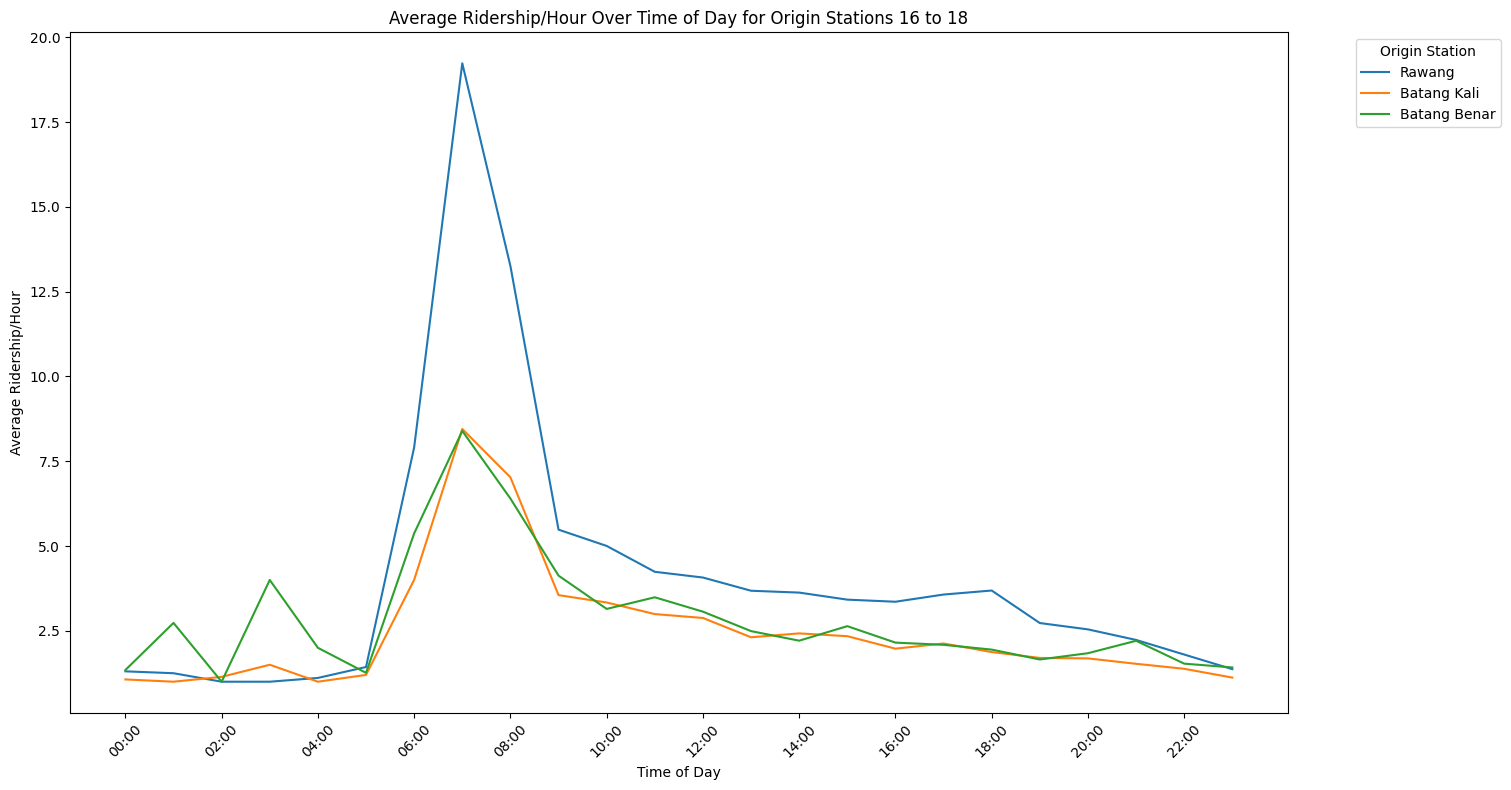

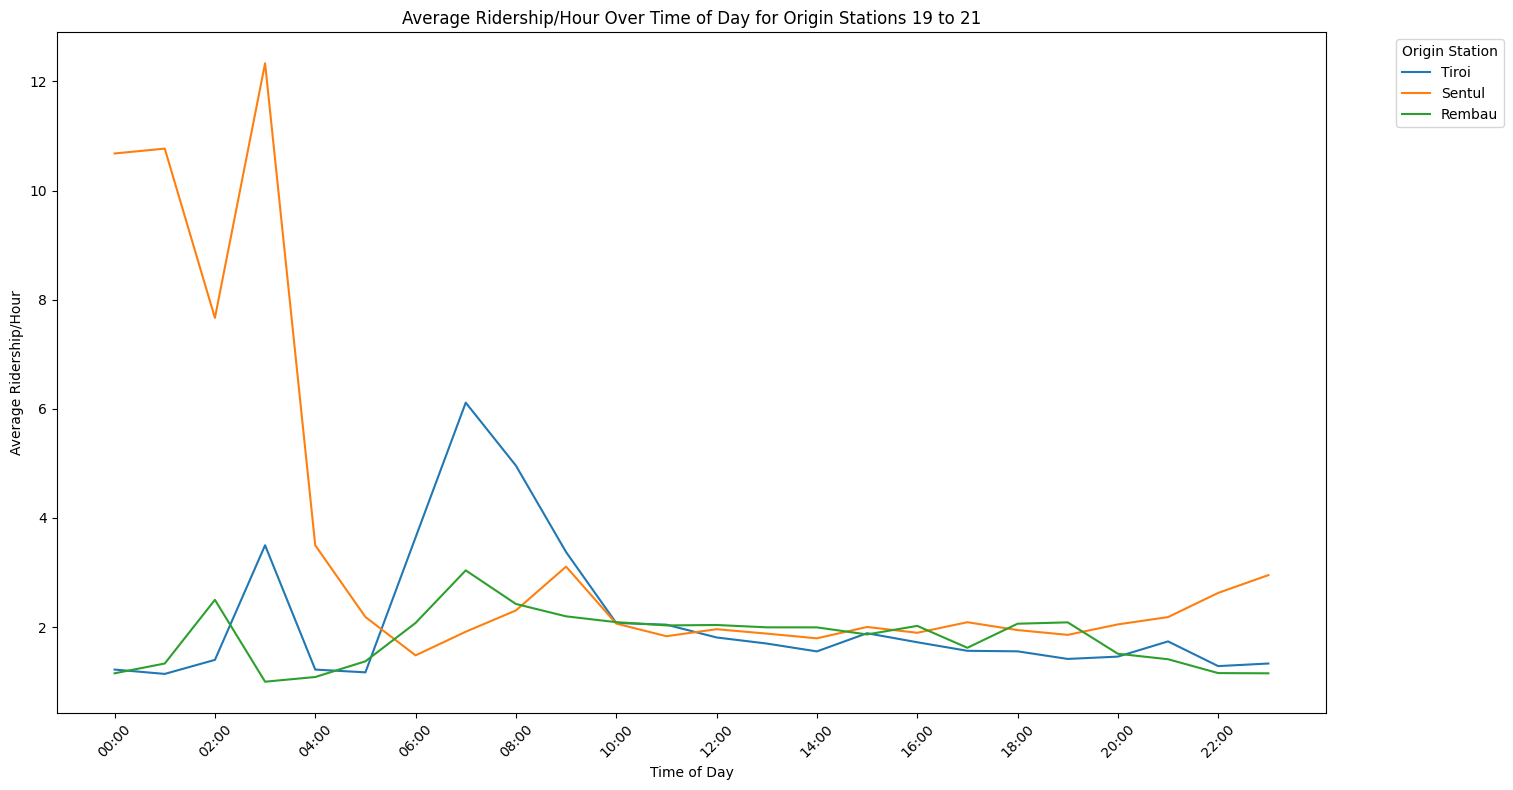

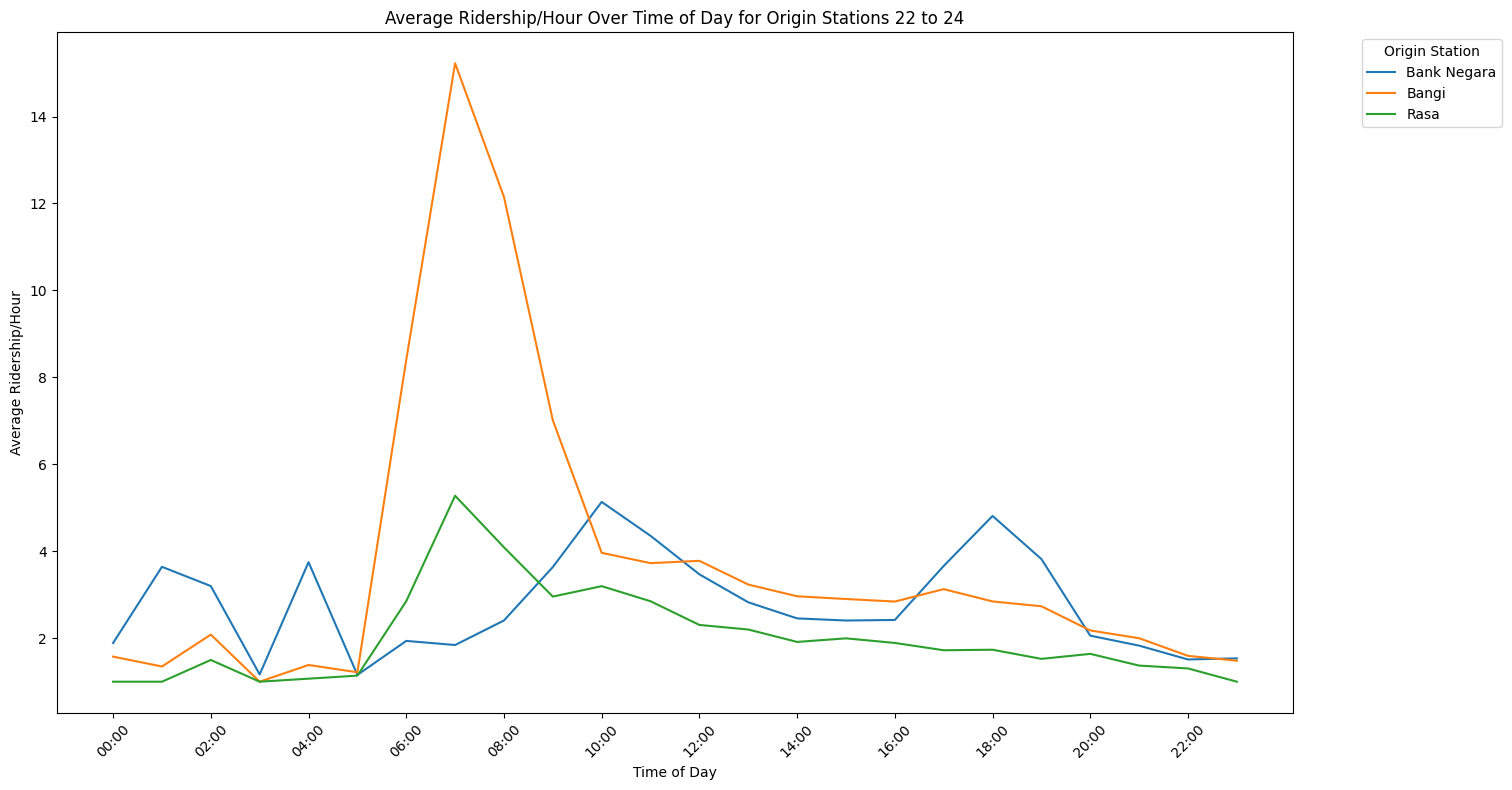

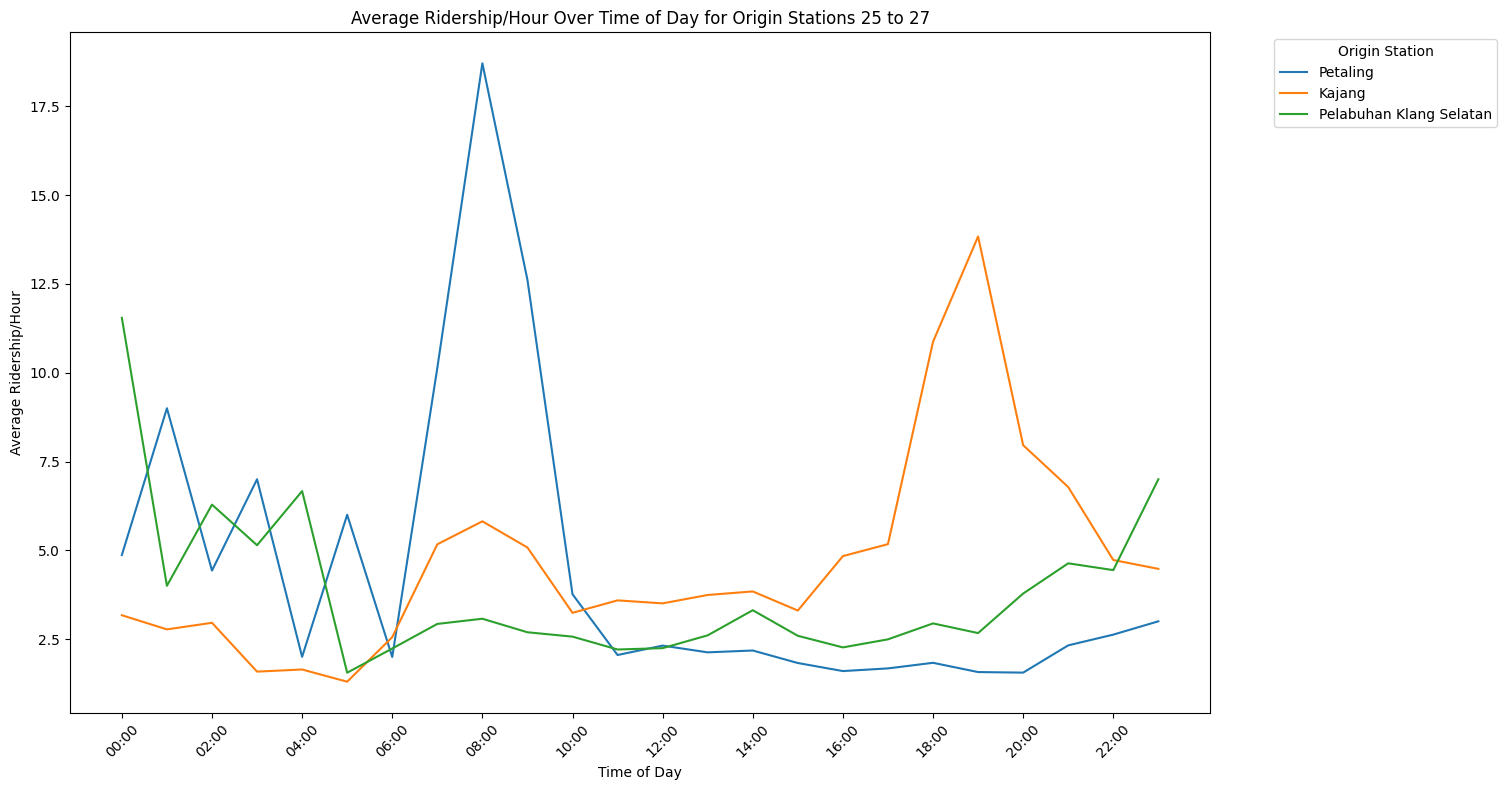

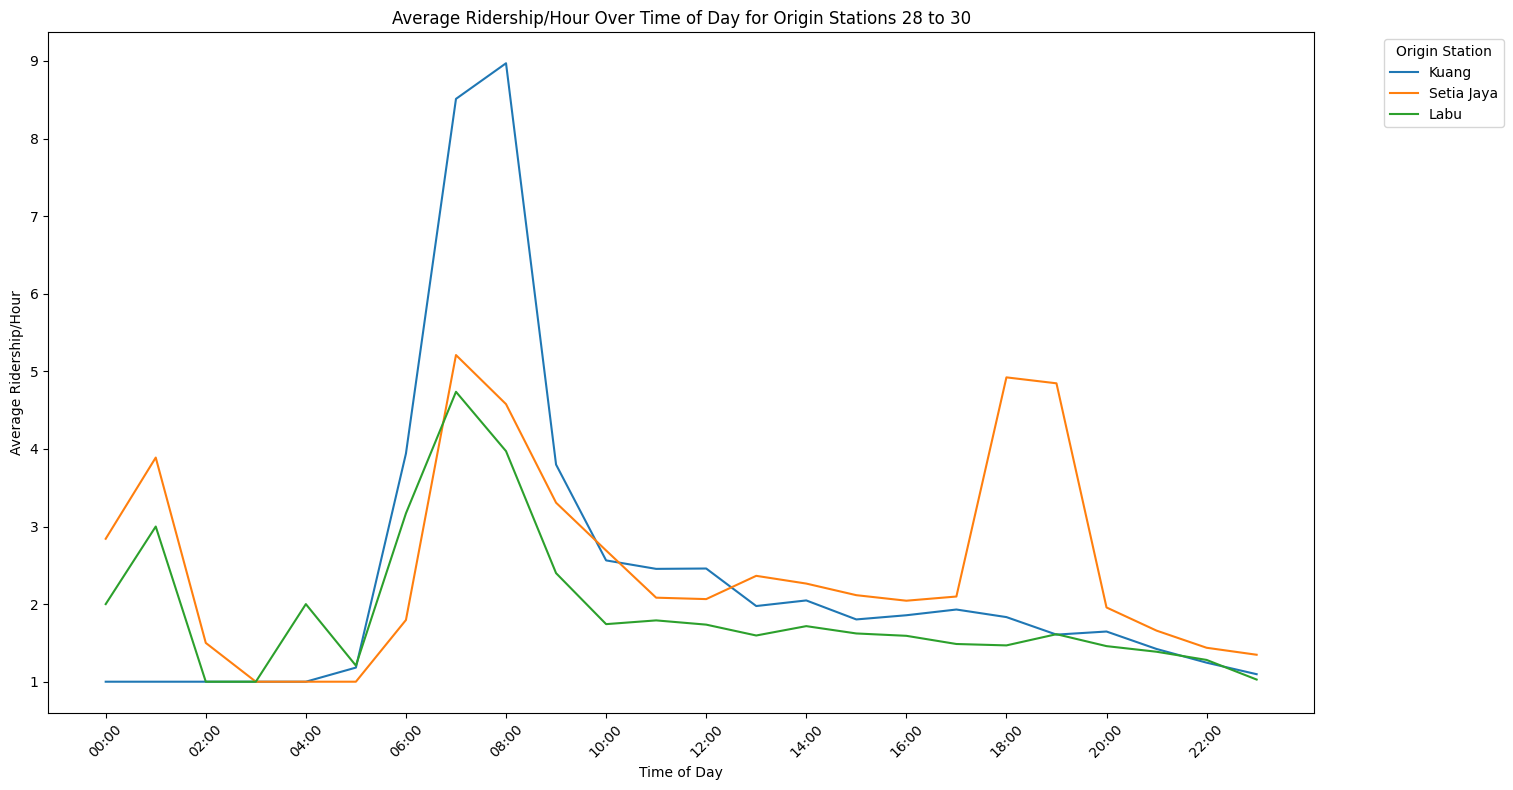

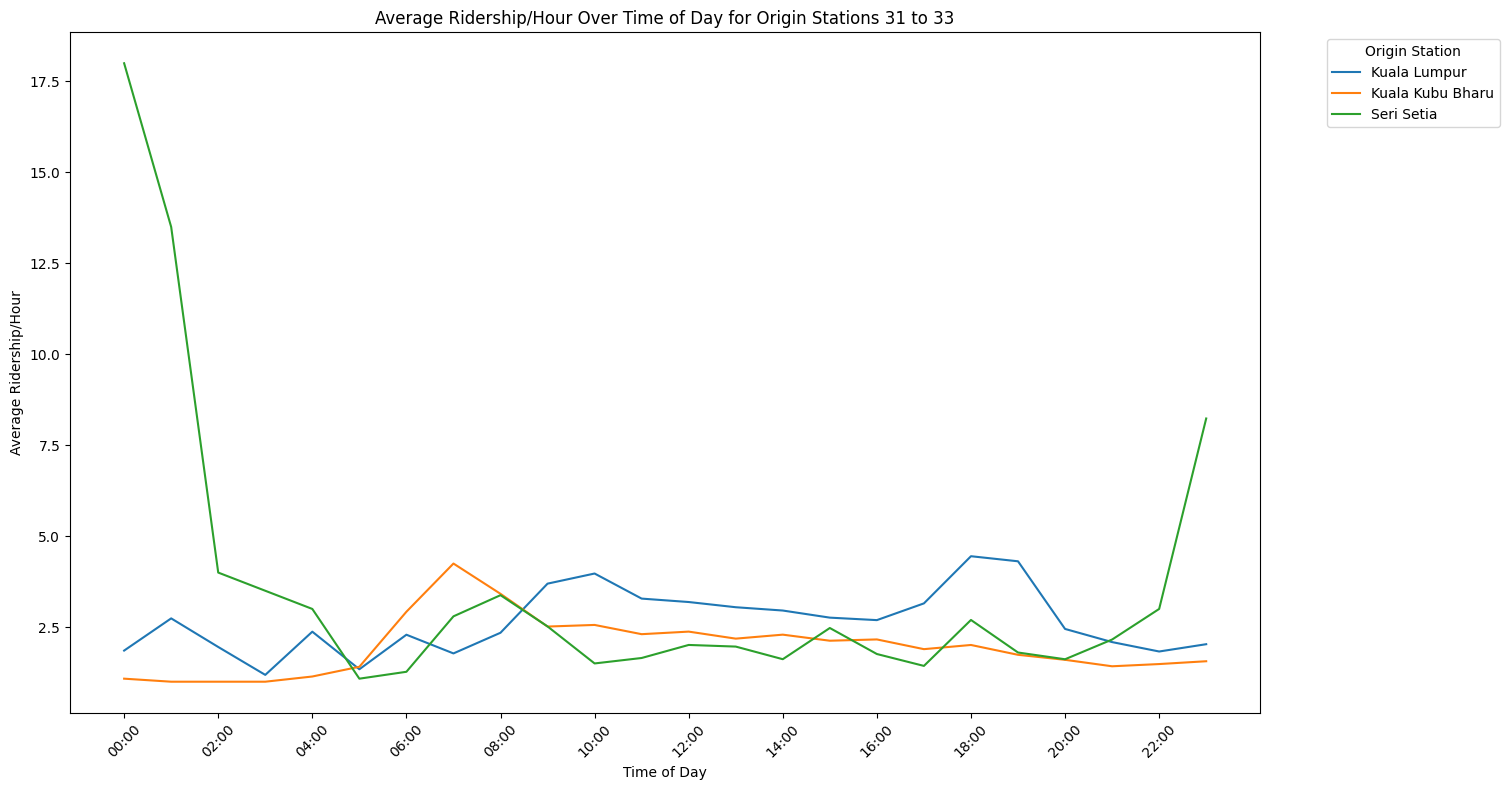

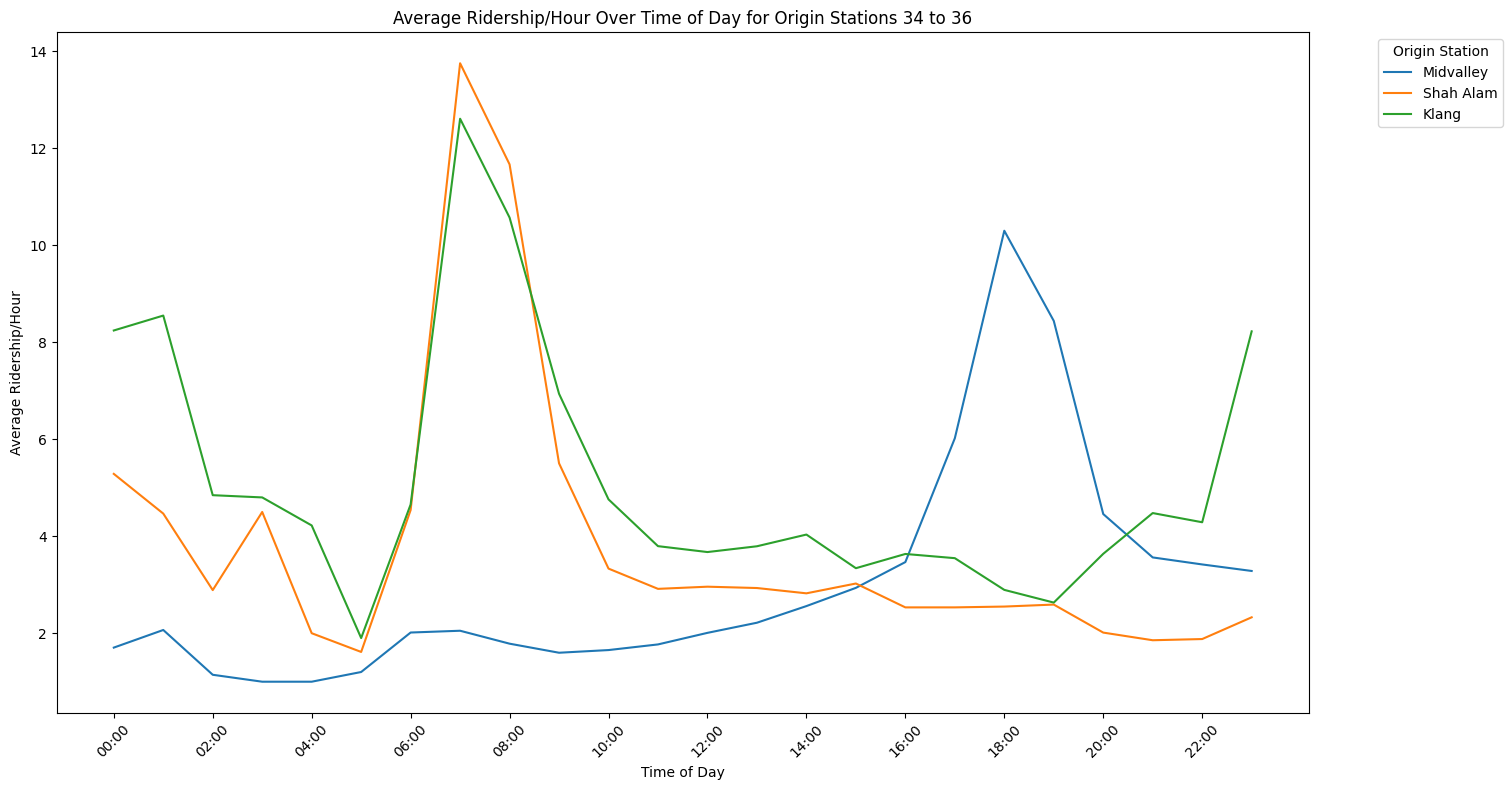

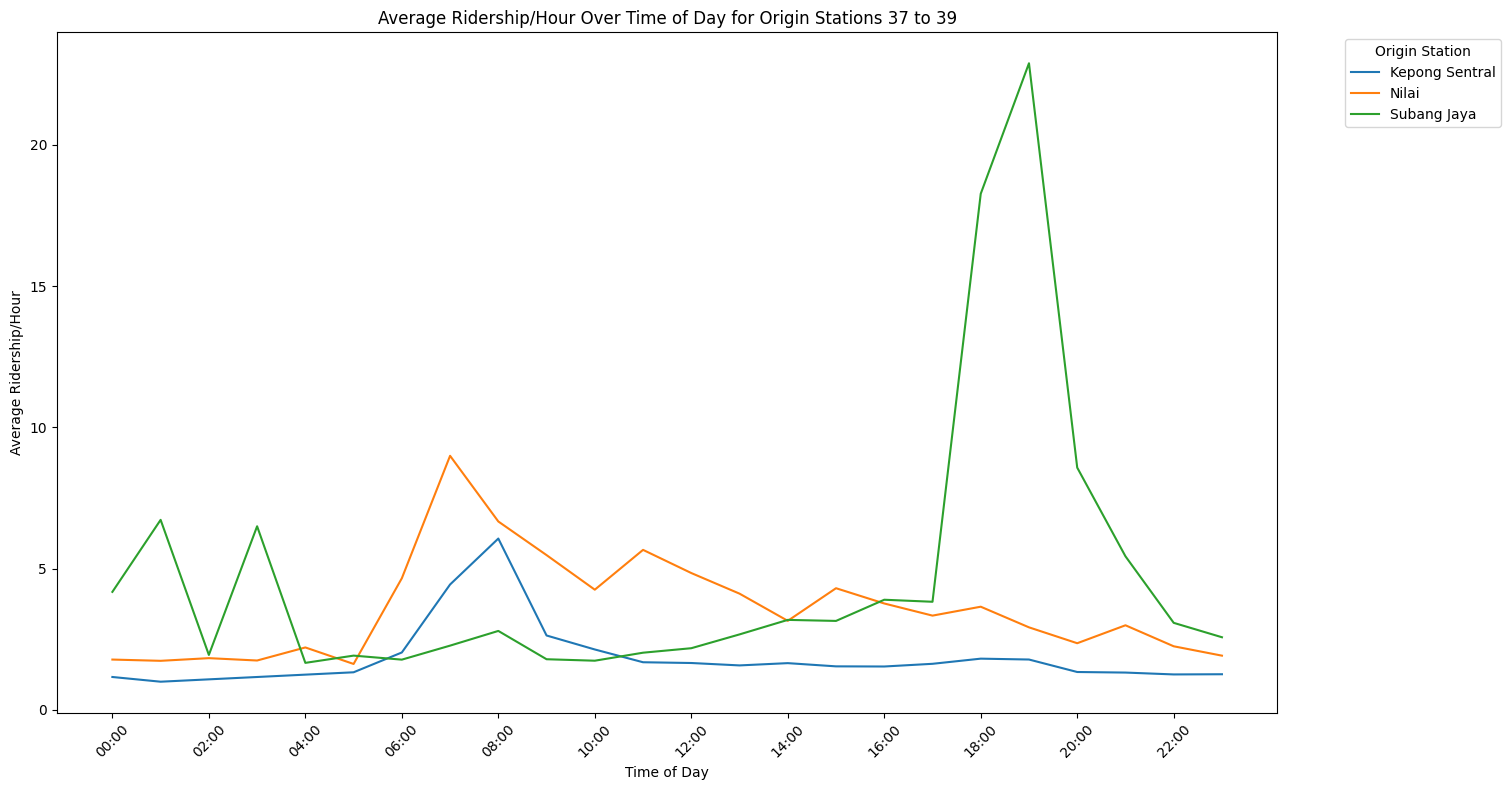

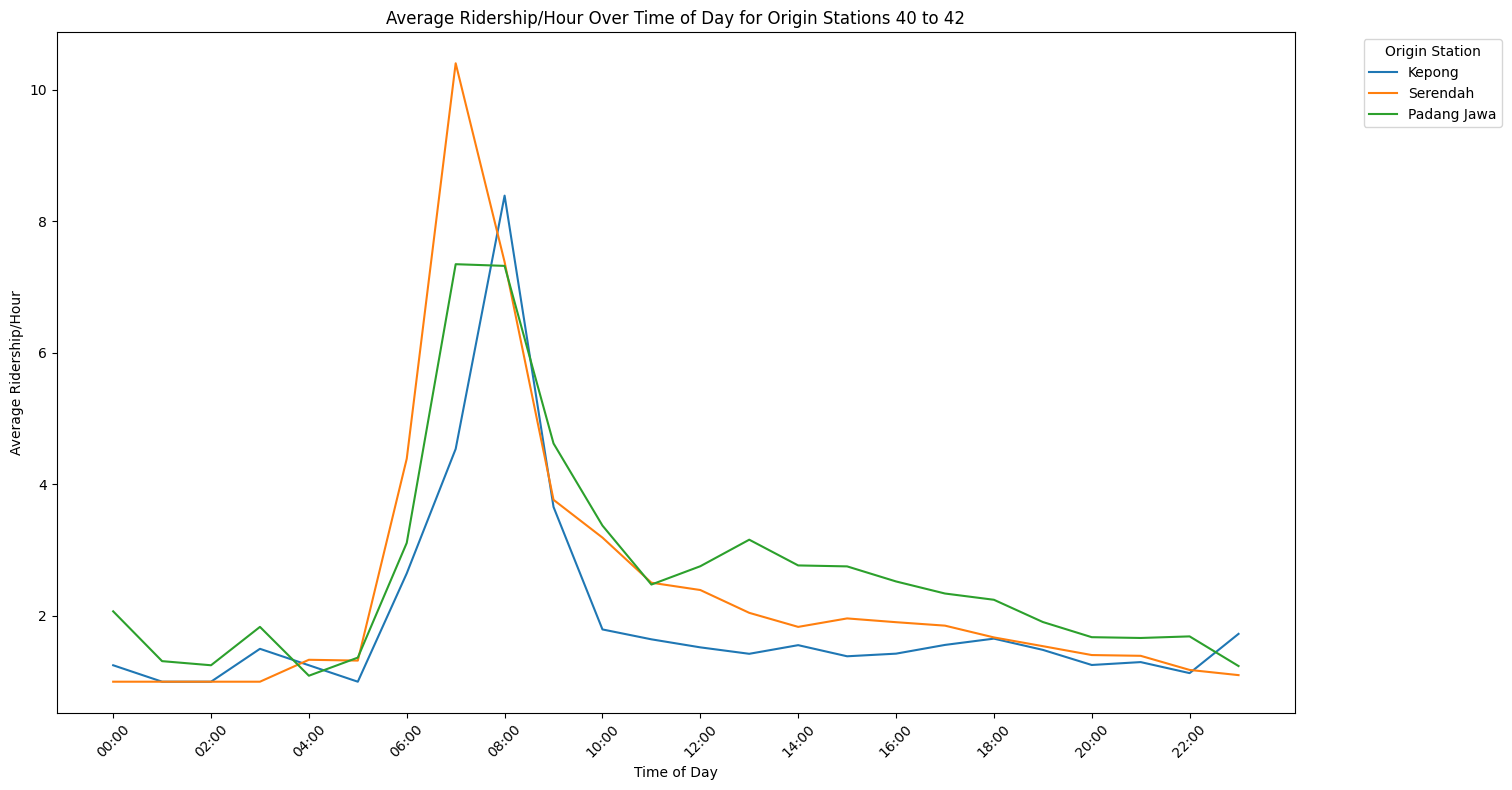

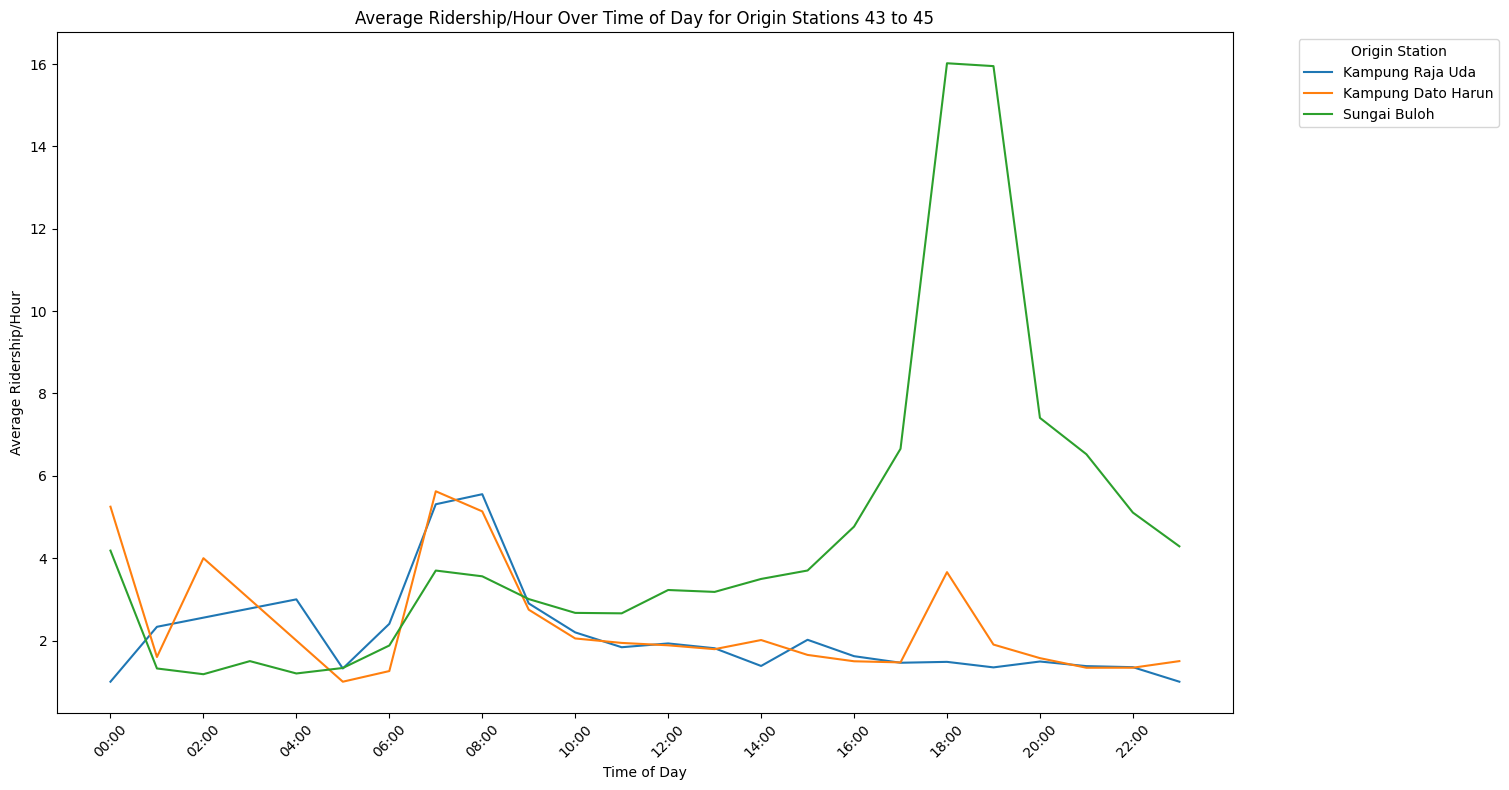

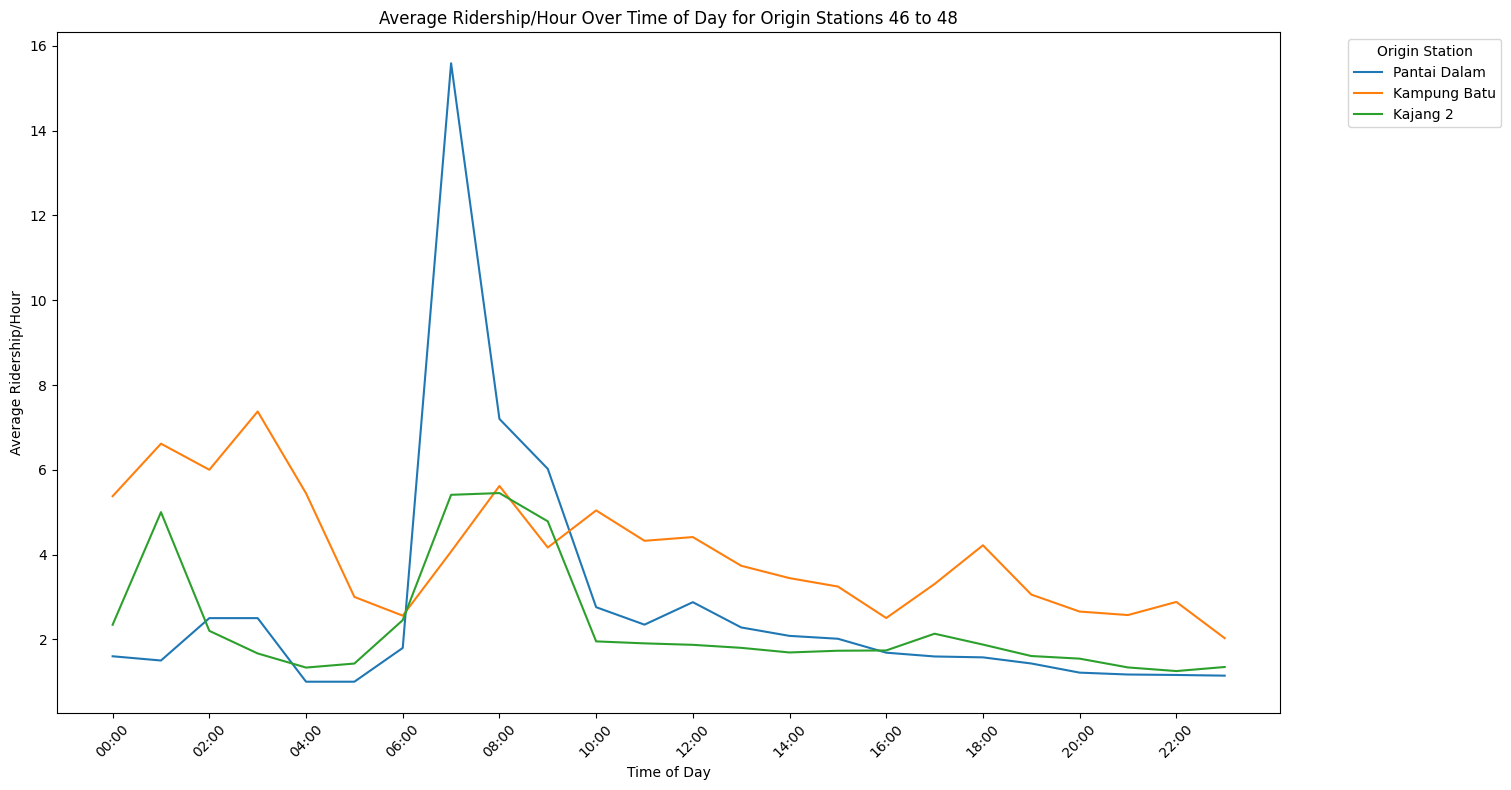

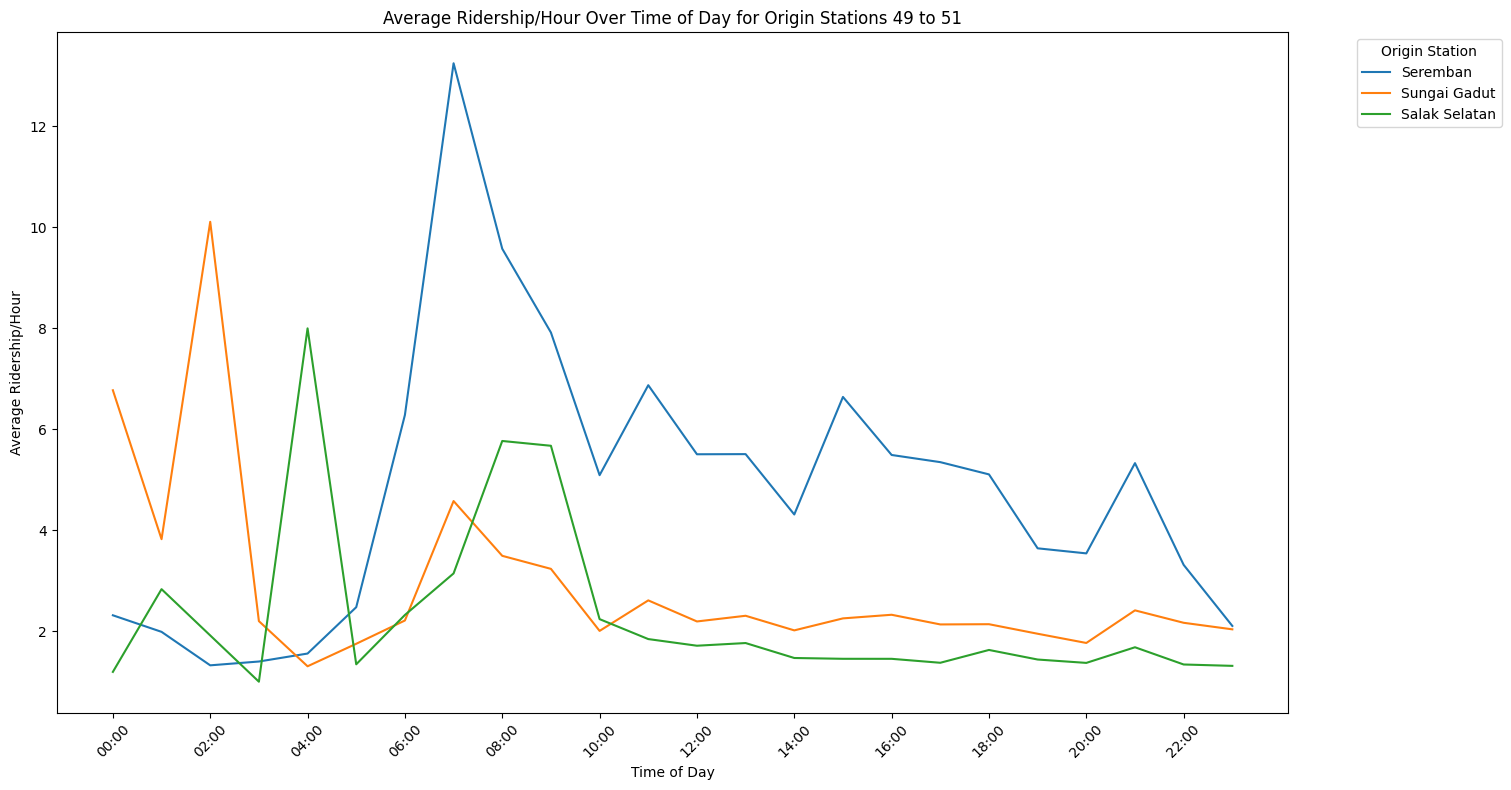

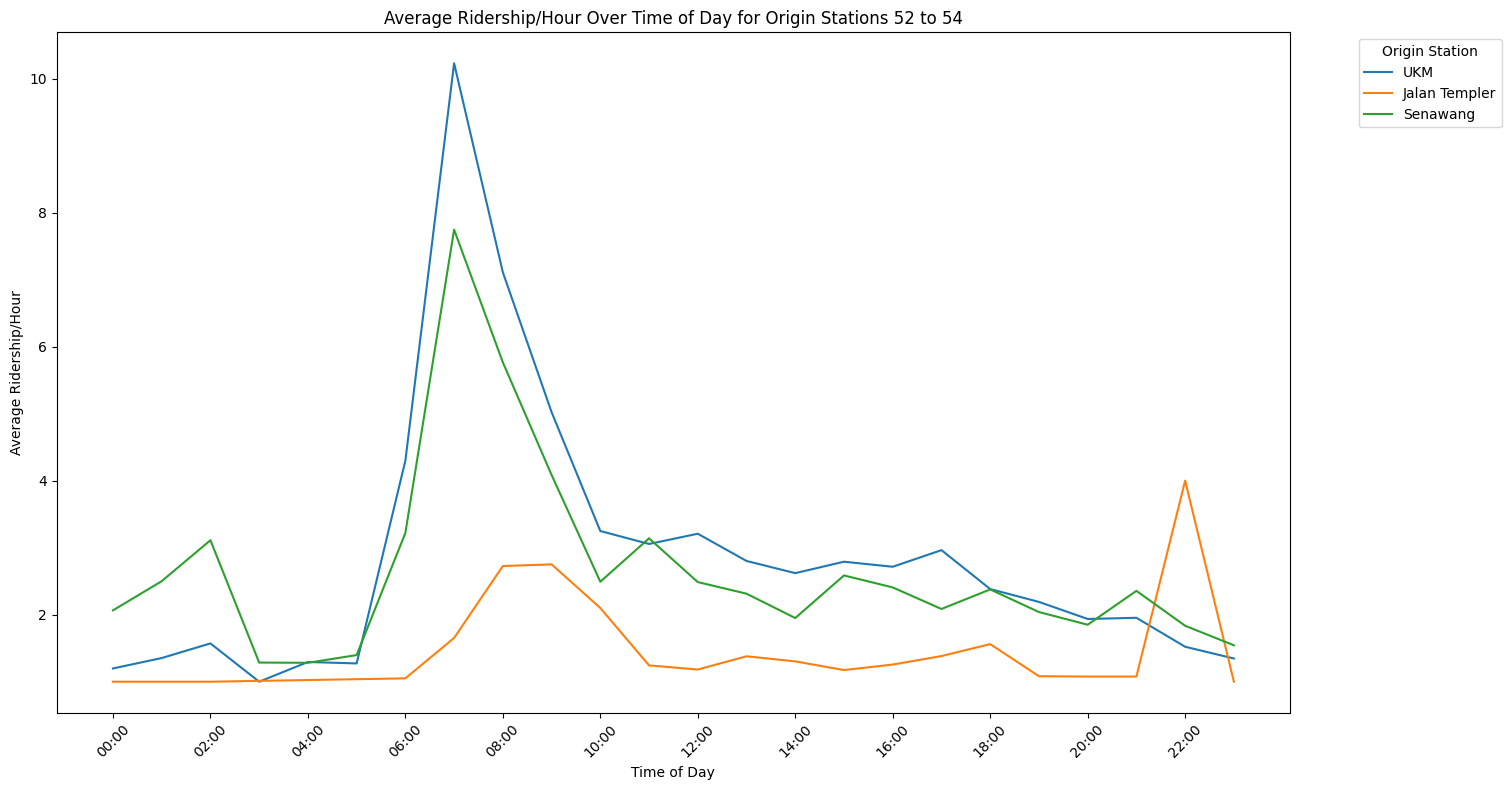

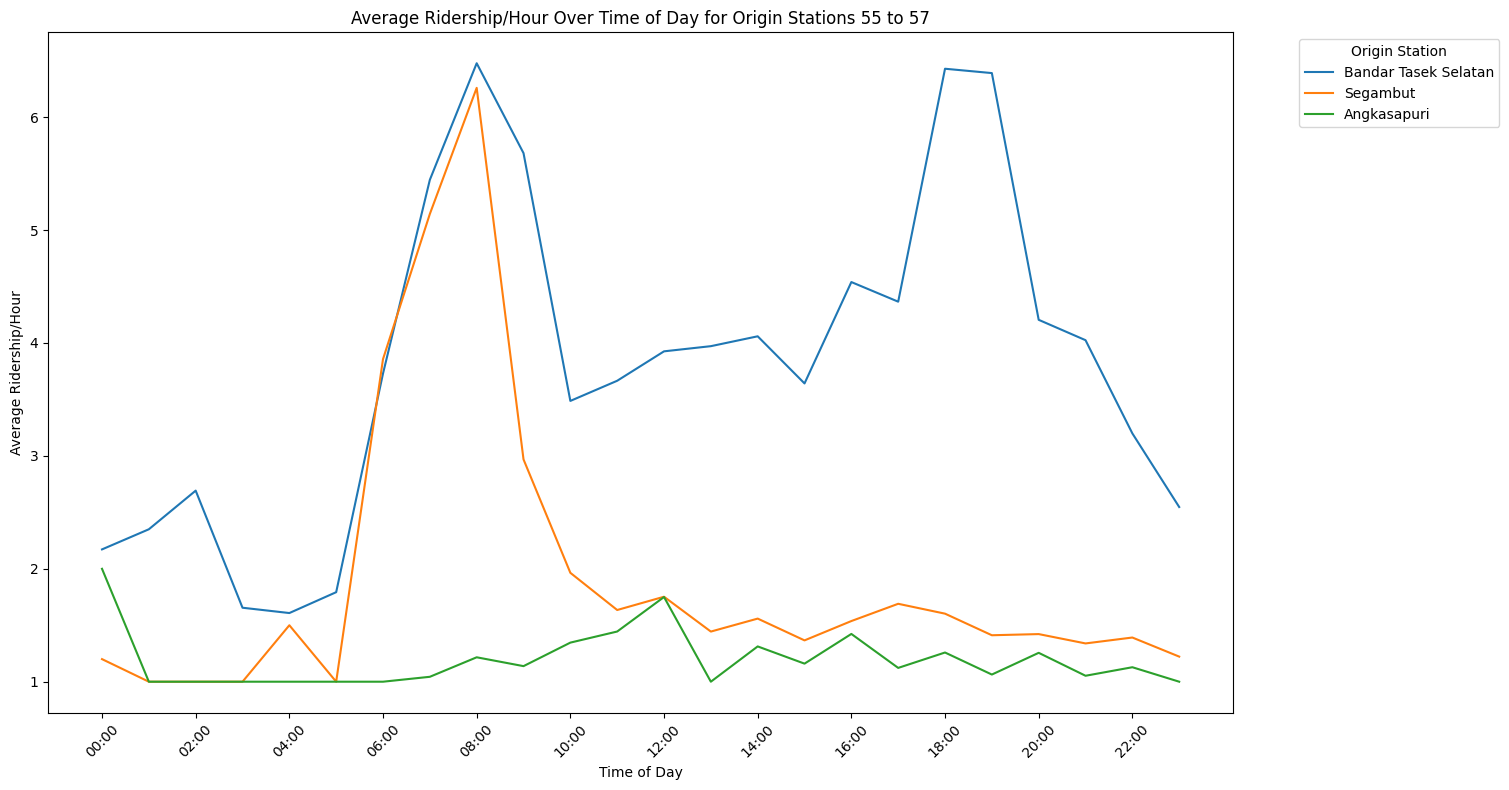

In [ ]:
# Group by 'origin' and 'time' and calculate the mean ridership
origin_time_ridership = merged_df3.groupby(['origin', 'time'])['ridership/hour'].mean().reset_index()

# Sort by time to ensure the line plots are chronological within each subplot
origin_time_ridership = origin_time_ridership.sort_values(by='time')

# Get the list of unique origin stations
unique_origins = origin_time_ridership['origin'].unique()
num_origins = len(unique_origins)
origins_per_plot = 3

# Calculate the number of plots needed
num_plots = (num_origins + origins_per_plot - 1) // origins_per_plot

# Iterate through the unique origins and create a plot for each group
for i in range(num_plots):
    # Determine the subset of origins for the current plot
    start_index = i * origins_per_plot
    end_index = min((i + 1) * origins_per_plot, num_origins)
    current_origins = unique_origins[start_index:end_index]

    # Filter the data for the current set of origins
    data_to_plot = origin_time_ridership[origin_time_ridership['origin'].isin(current_origins)].copy()

    # Create a line plot for the current subset of origins
    plt.figure(figsize=(18, 8)) # Adjust figure size
    sns.lineplot(data=data_to_plot, x='time', y='ridership/hour', hue='origin')

    plt.title(f'Average Ridership/Hour Over Time of Day for Origin Stations {start_index + 1} to {end_index}')
    plt.xlabel('Time of Day')
    plt.ylabel('Average Ridership/Hour')

    # Improve readability of x-axis labels if there are many unique times
    num_labels = 12 # Display roughly 12 labels
    if len(data_to_plot['time'].unique()) > num_labels:
        tick_positions = data_to_plot['time'].unique()[::len(data_to_plot['time'].unique()) // num_labels]
        plt.xticks(tick_positions, rotation=45)
    else:
        plt.xticks(rotation=45)

    # Place the legend outside the plot to avoid clutter
    plt.legend(title='Origin Station', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
    plt.show()

### destination vs time vs ridership/hour
**How destination and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The peak hours on the business districts or near office commuter line will more likely to have the higher ridership/hour such as 7:00 AM - 9:00 AM and 5:00 PM to 7:00 PM at the Subang Jaya, KL Sentral and Kepong.
<br><br>
**Actual:**<br>
Further investigation found that:
1. Abdullah Hukum (9:00 AM) - around 10 riderships
2. Subang Jaya (7:00 AM) - around 30 riderships
3. Salak Selatan (3:00 AM) - around 10 riderships
4. Rawang (7:00 PM) - around 14 riderships
5. Bangi (7:00 PM) - around 16 riderships
6. Klang (3:00 AM) - around 25 riderships
7. Kampung Batu (1:00 AM to 3:00 AM) - around 22 riderships
8. Sentul (3:00 AM) - around 40 riderships
9. Batu Kentonmen (1:00 AM) - around 25 riderships
10. Sungai Buloh (7:00 AM) - around 25 riderships
11. Seri Setia (3:00 AM) - around 20 riderships
12. Batu Caves (1:00 AM, 10:00 AM and 6:00 PM) - around 20 riderships for 1:00 AM, 15 riderships for 10:00 AM and 13 riderships for 6:00 PM
13. Seremban (7:00 PM) - around 14 riderships
14. KL Sentral (7:00 AM to 8:00 AM) - around 20 riderships
15. Taman Wahyu (1:00 AM) - around 40 riderships
16. Kajang (7:00 AM) - around 20 riderships
17. Bandar Tasek Selatan (7:00 AM and 6:00 PM) - around 8 riderships for both
18. Pelabuhan Klang Selatan (3:00 AM) - around 25 riderships
19. Pantai Dalam (5:00 PM to 7:00 PM) - around 15 riderships
20. MidValley (8:00 AM) - around 12 riderships
21. Petaling (3:00 AM and 6:00 PM)- around 20 riderships for 3:00 AM and around 18 riderships for 6:00 PM
22. Kuang (6:00 PM) - around 9 riderships

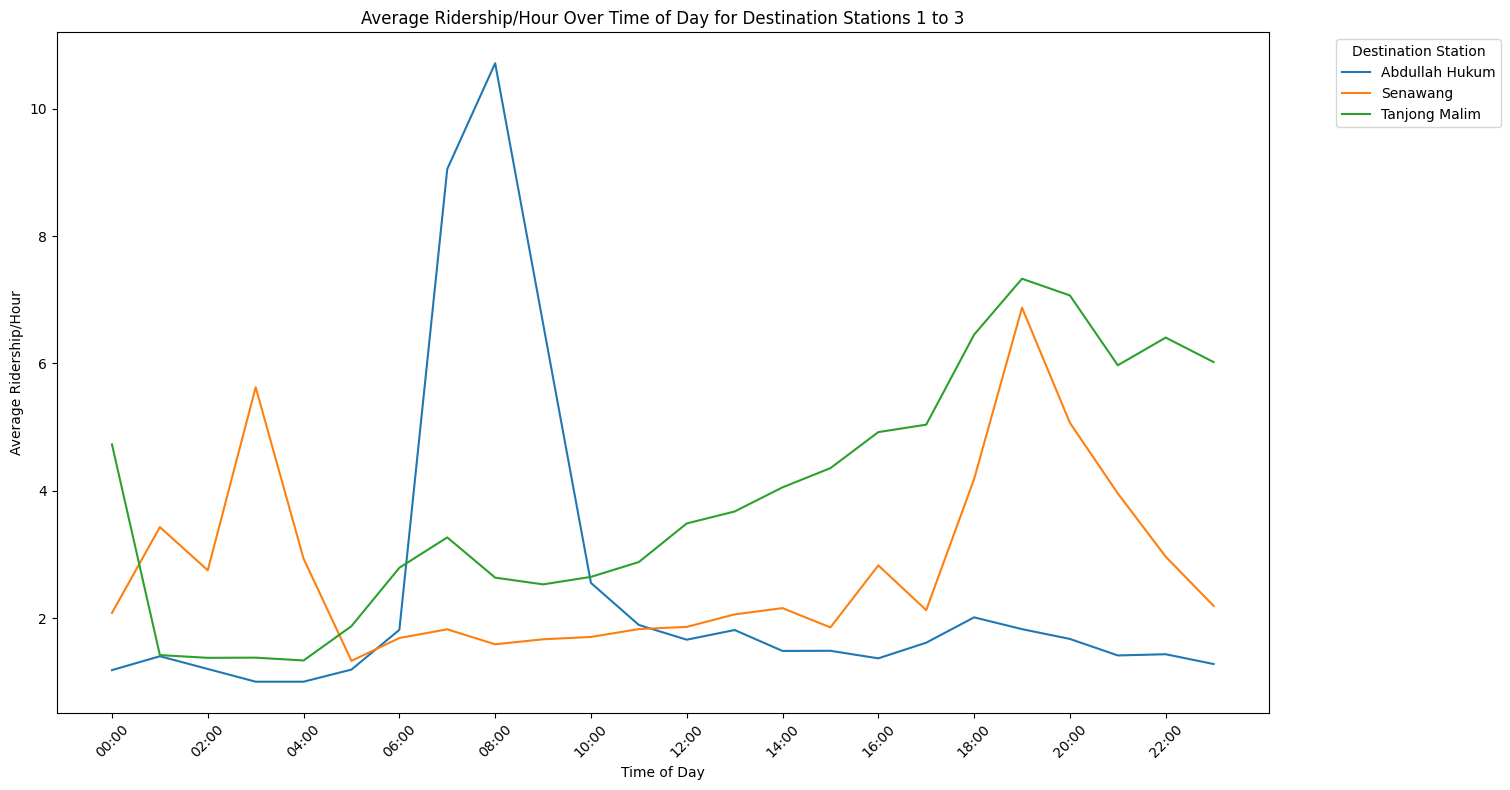

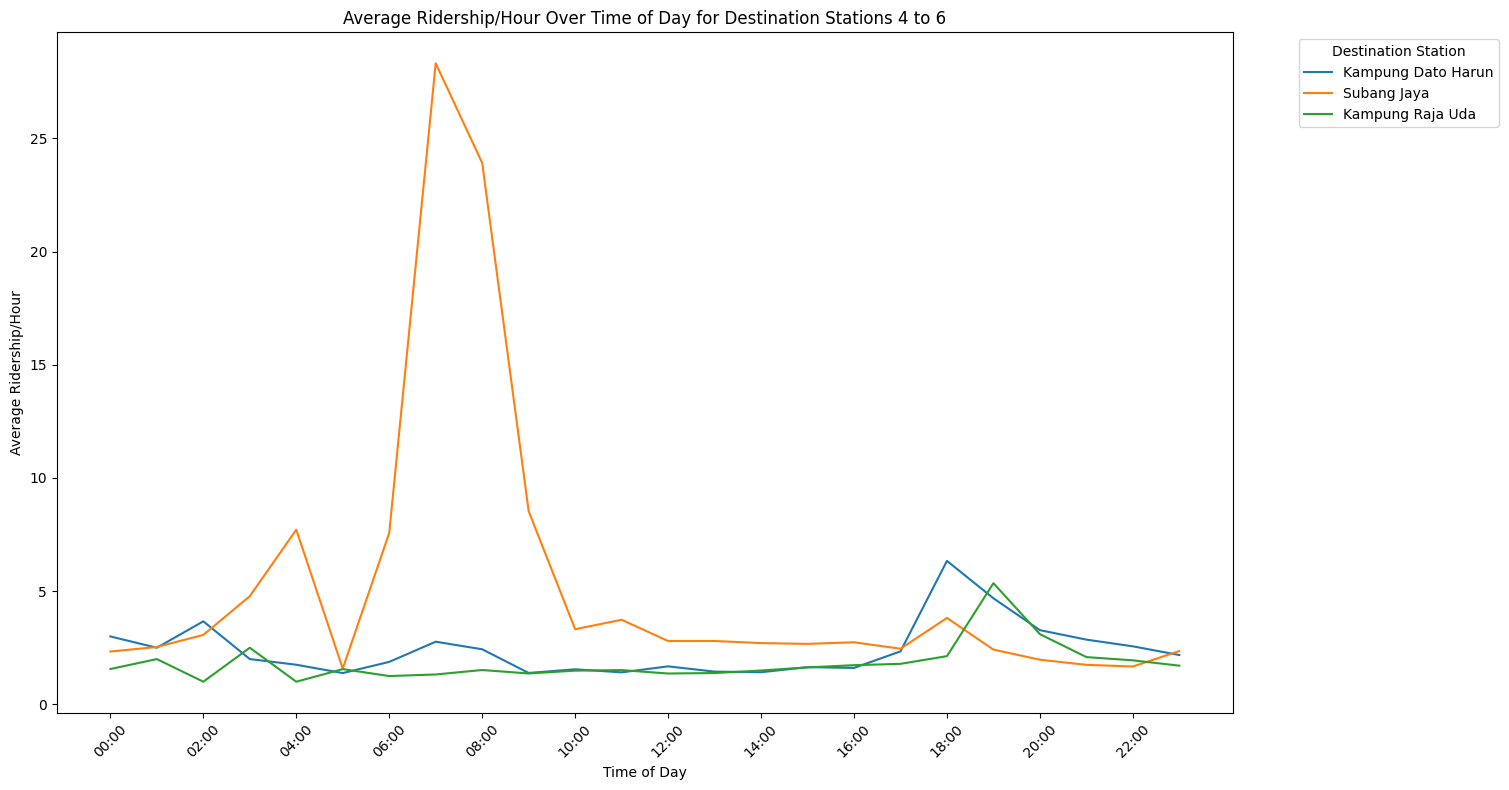

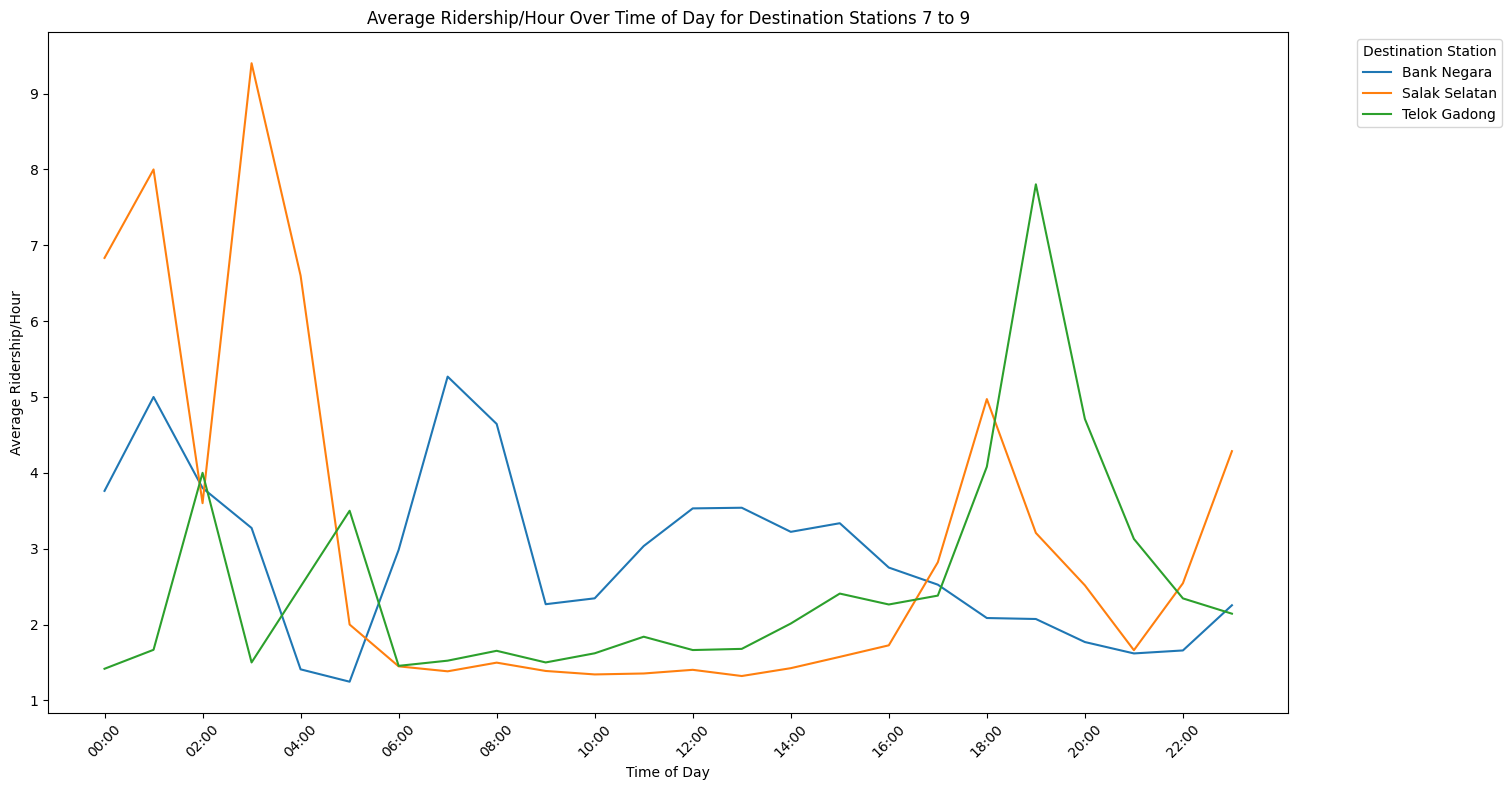

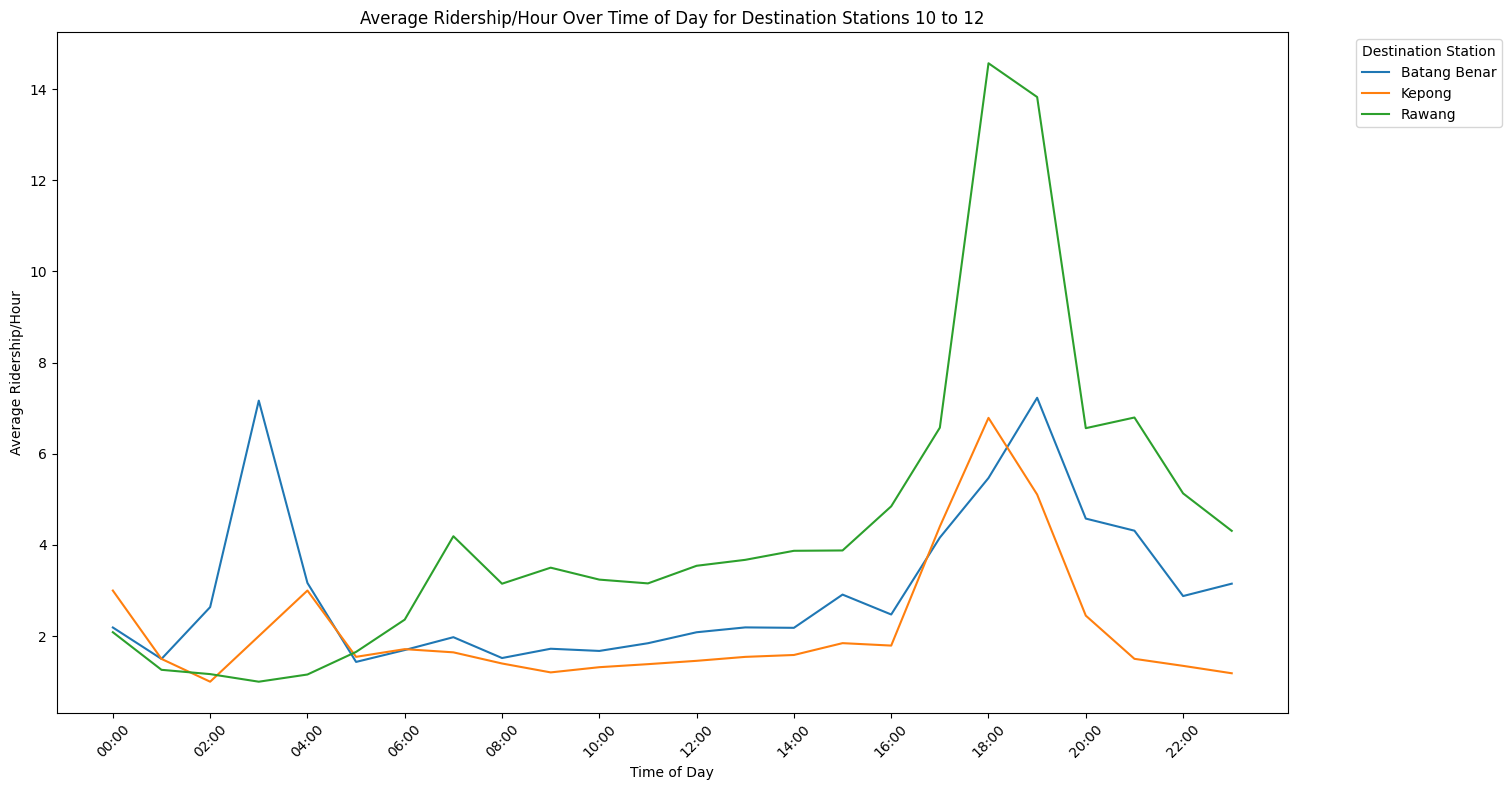

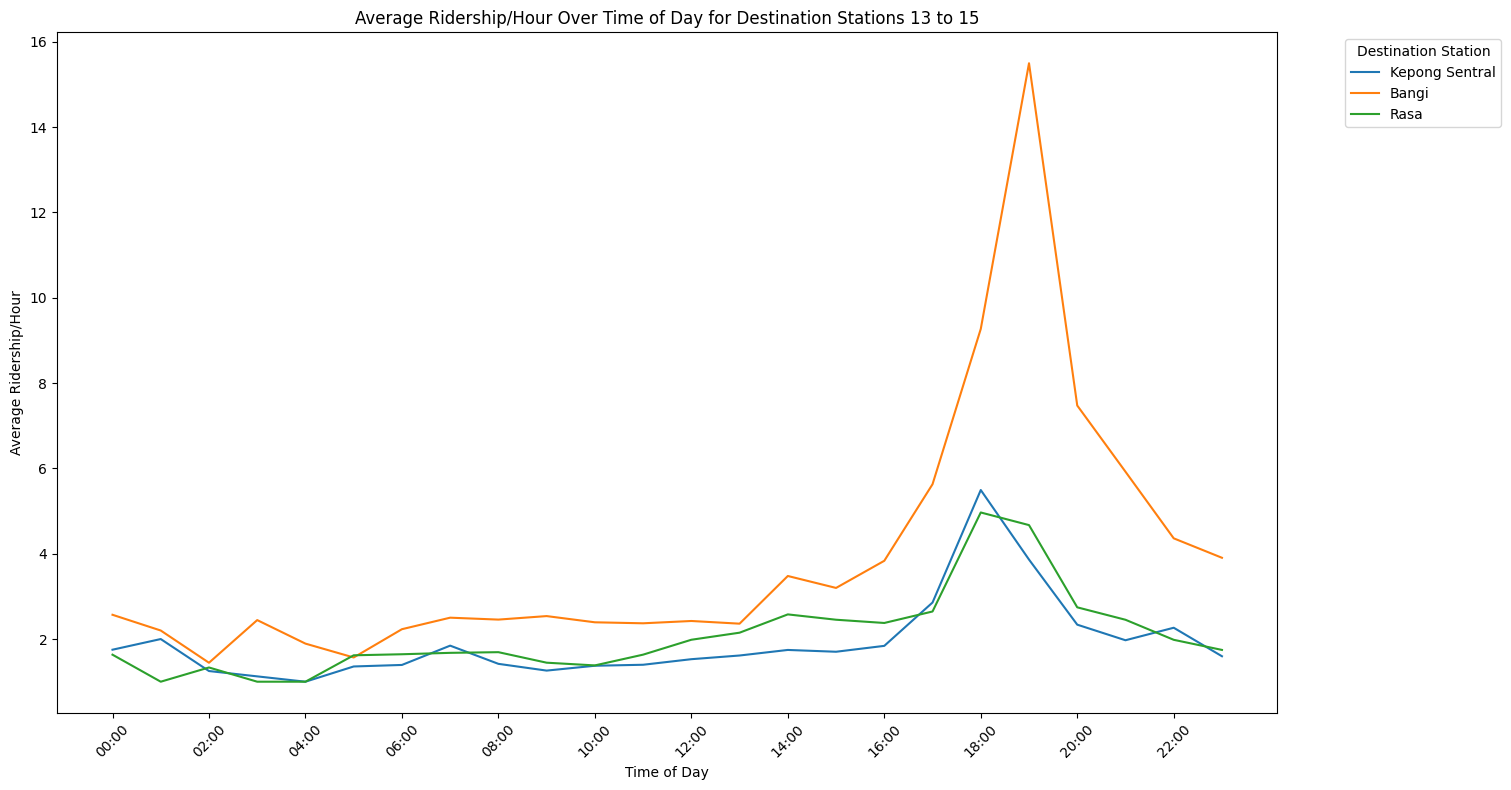

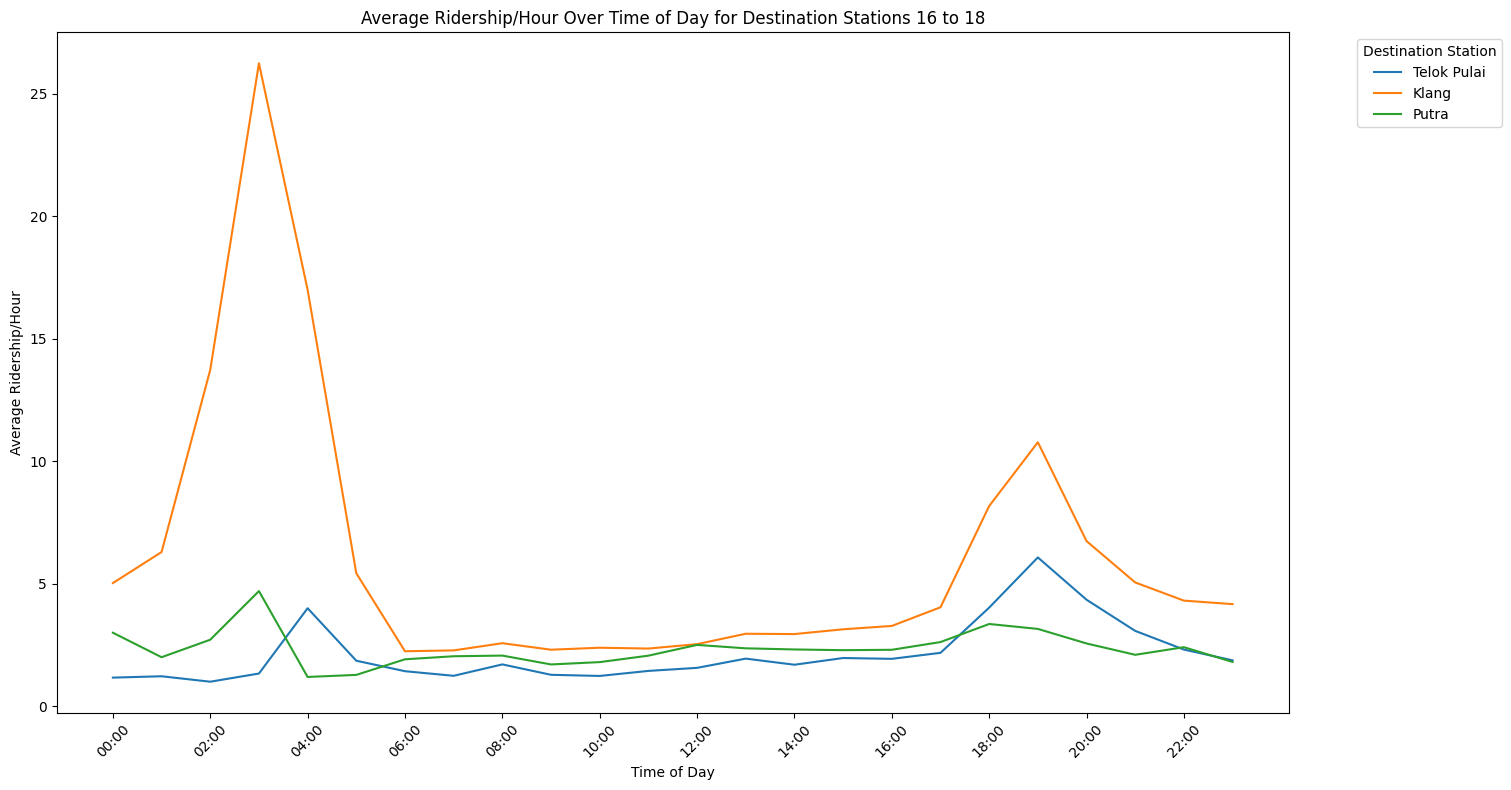

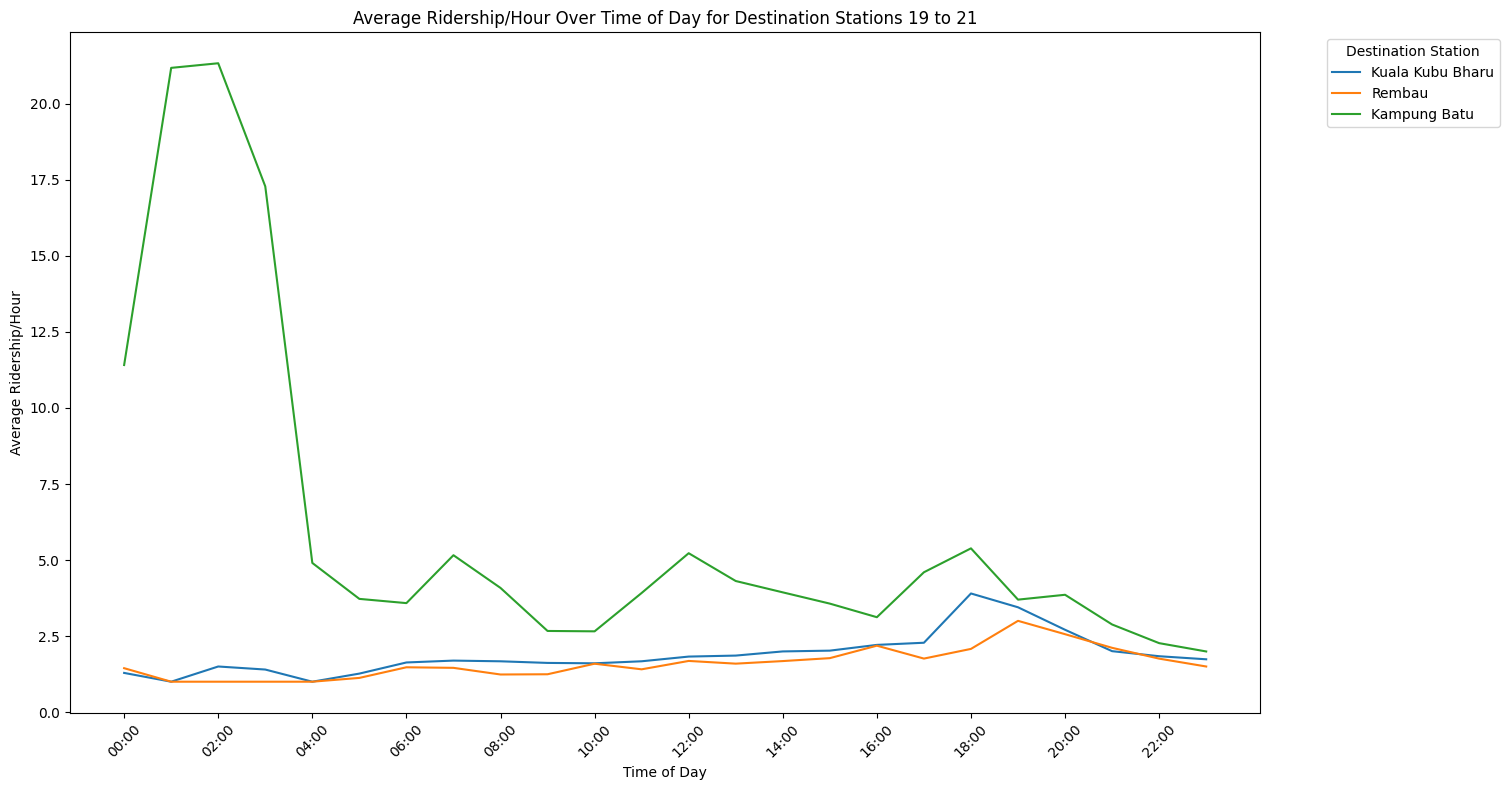

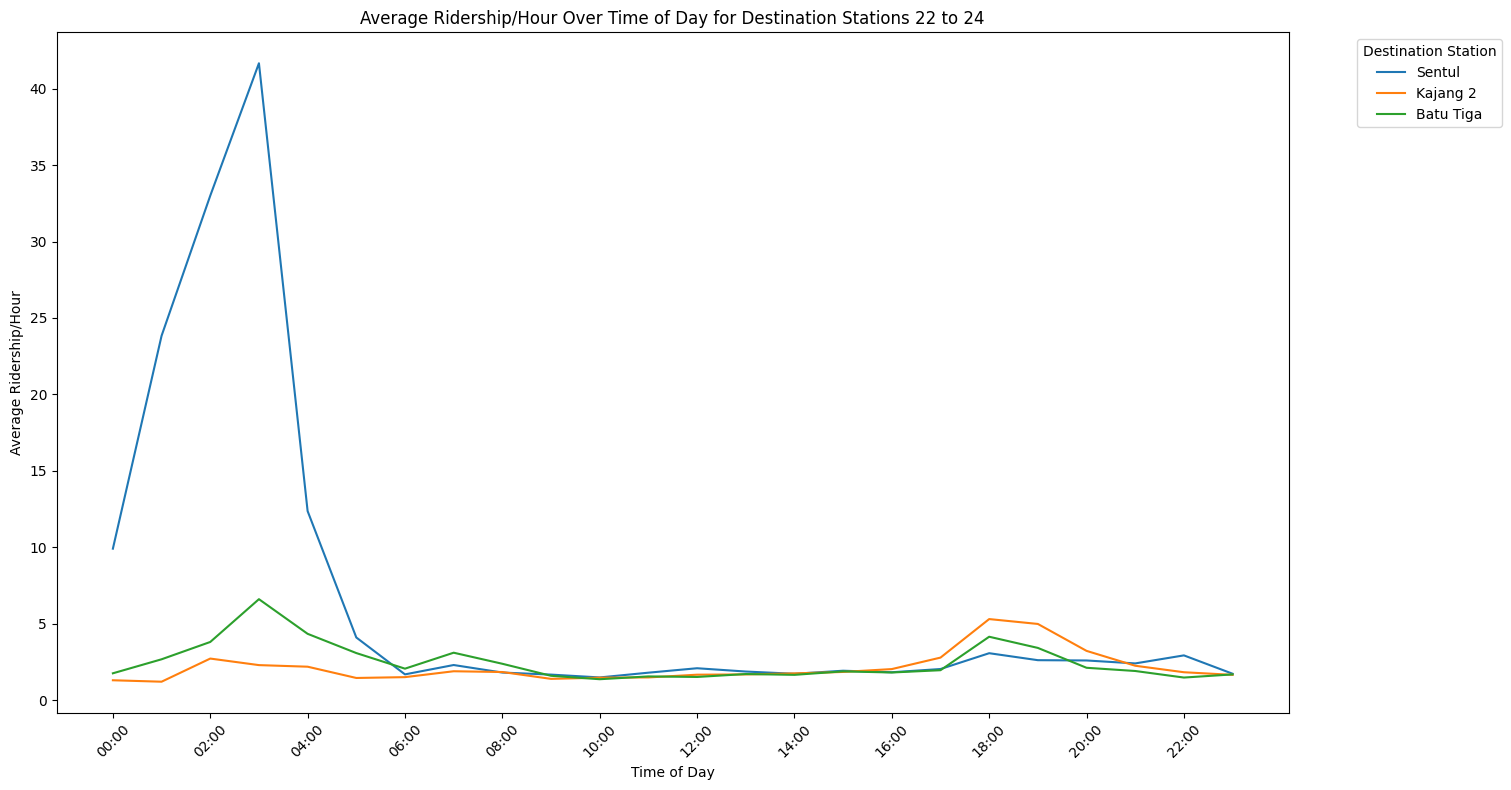

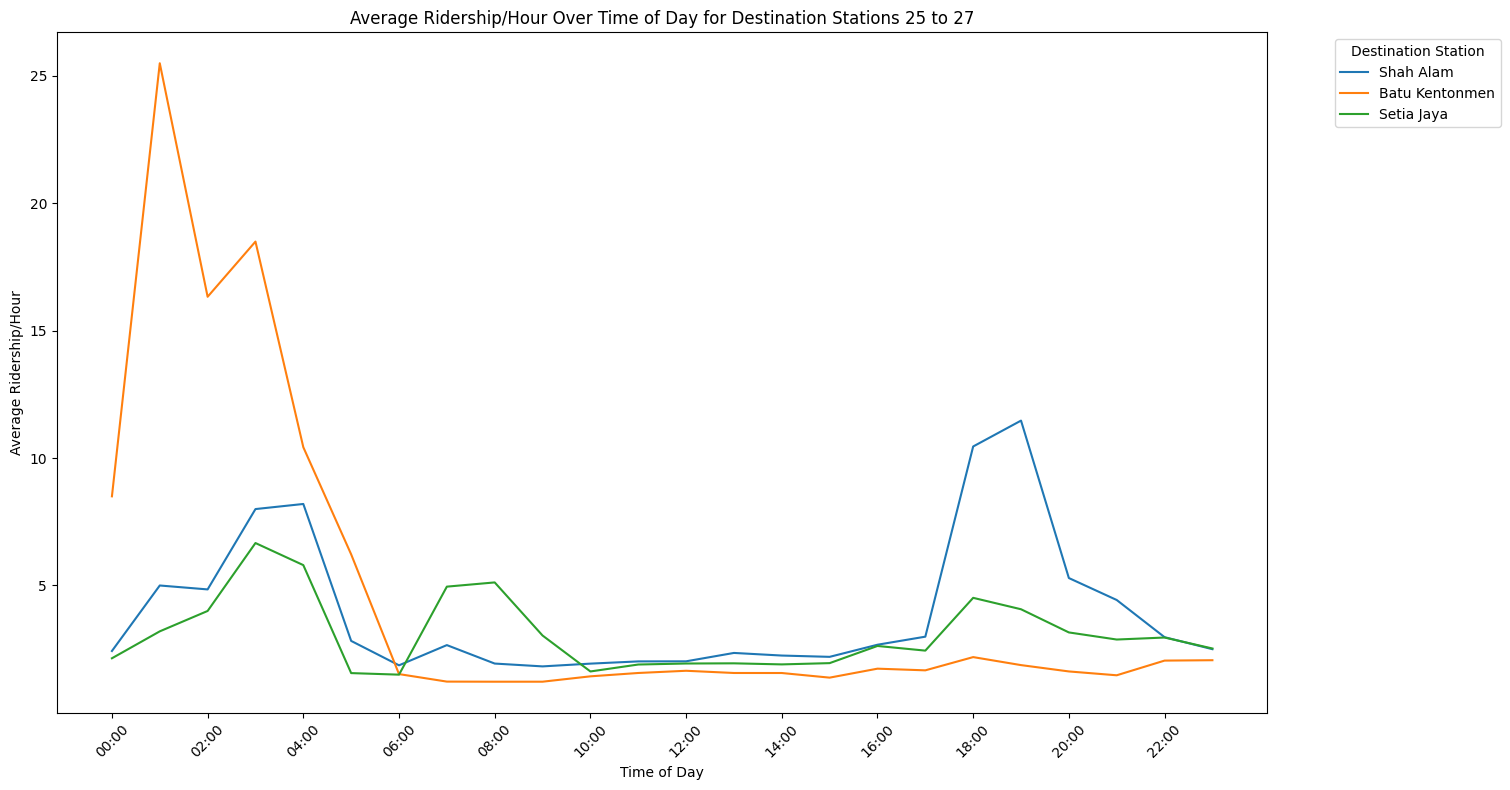

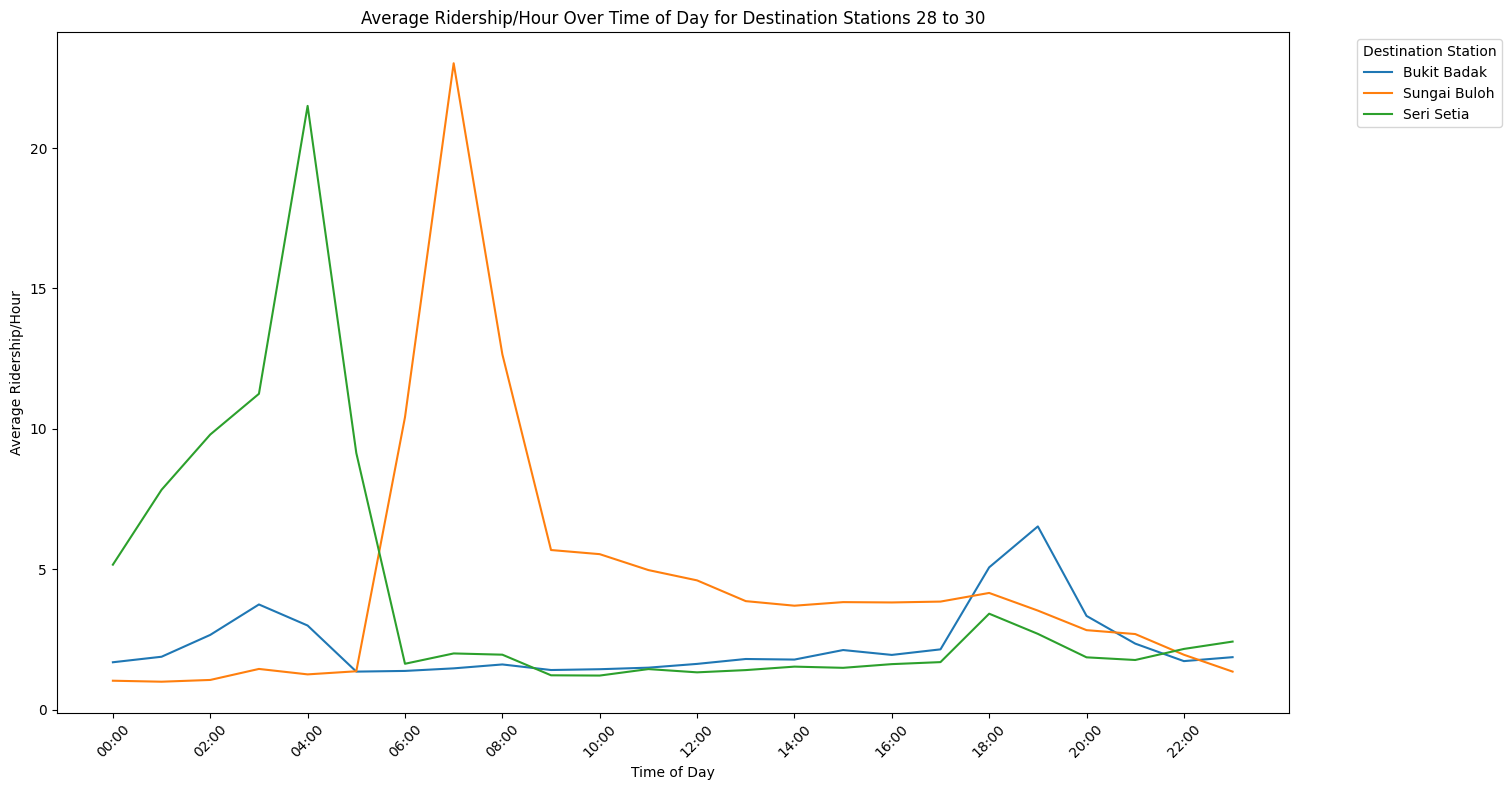

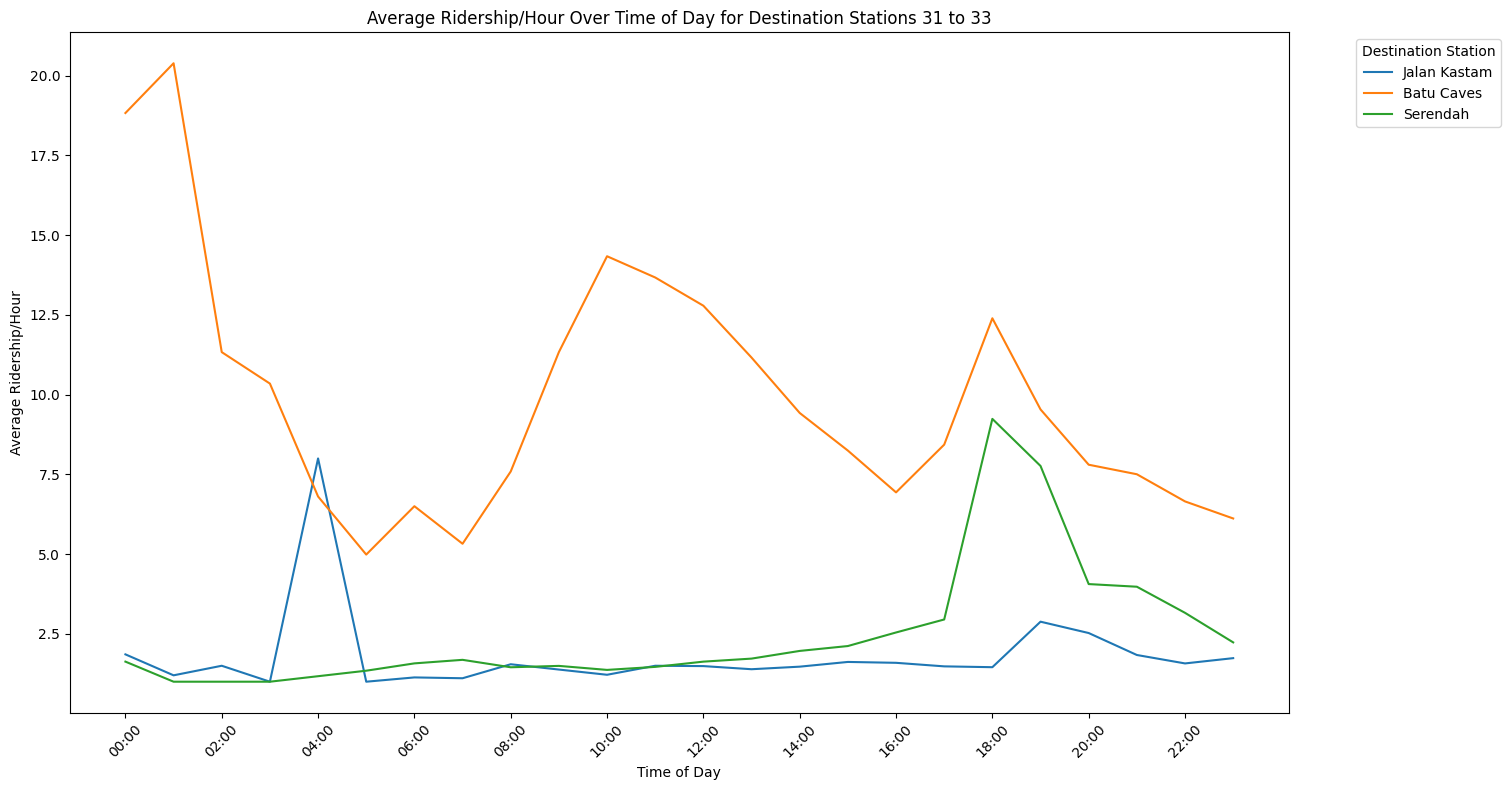

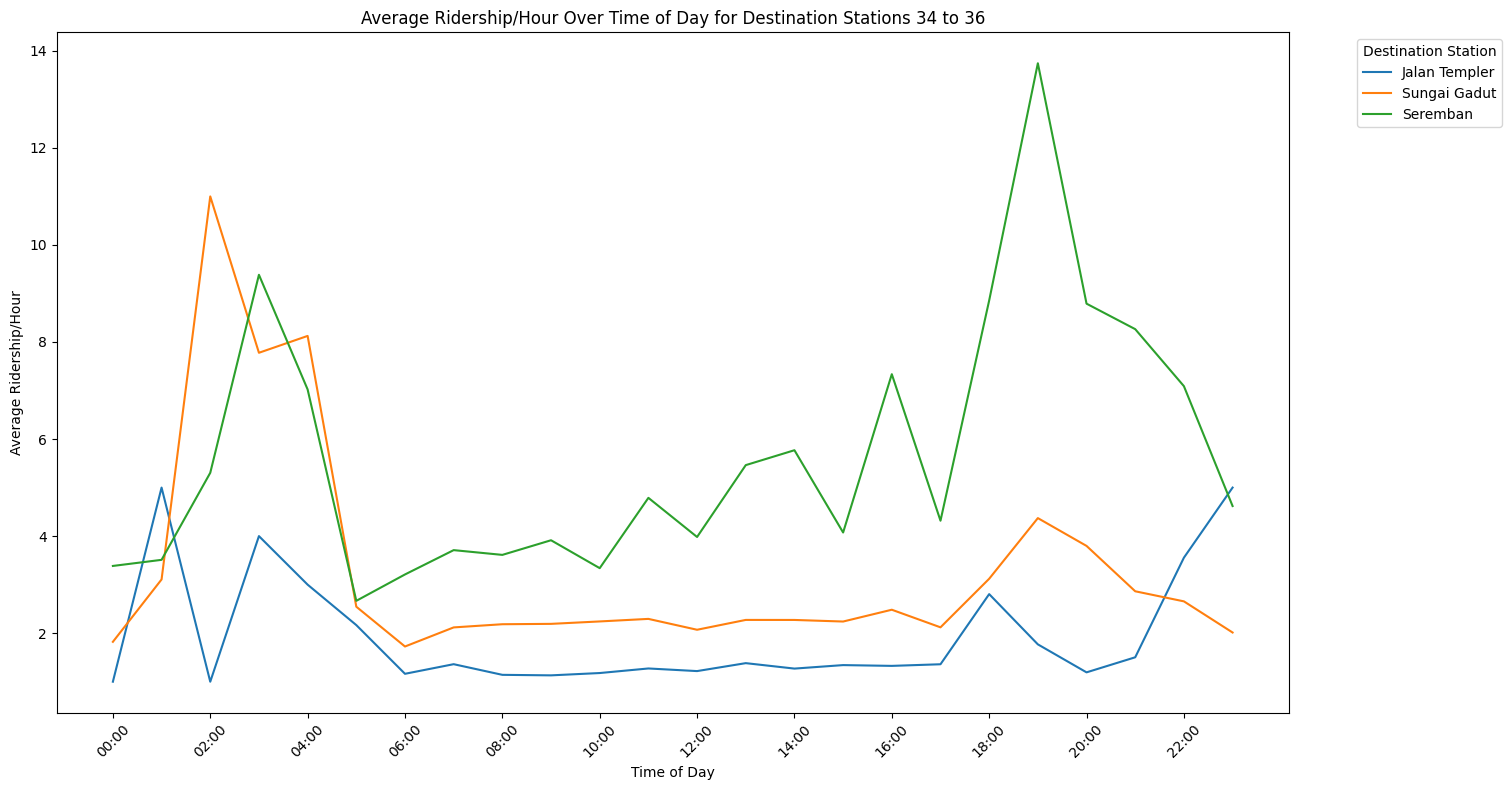

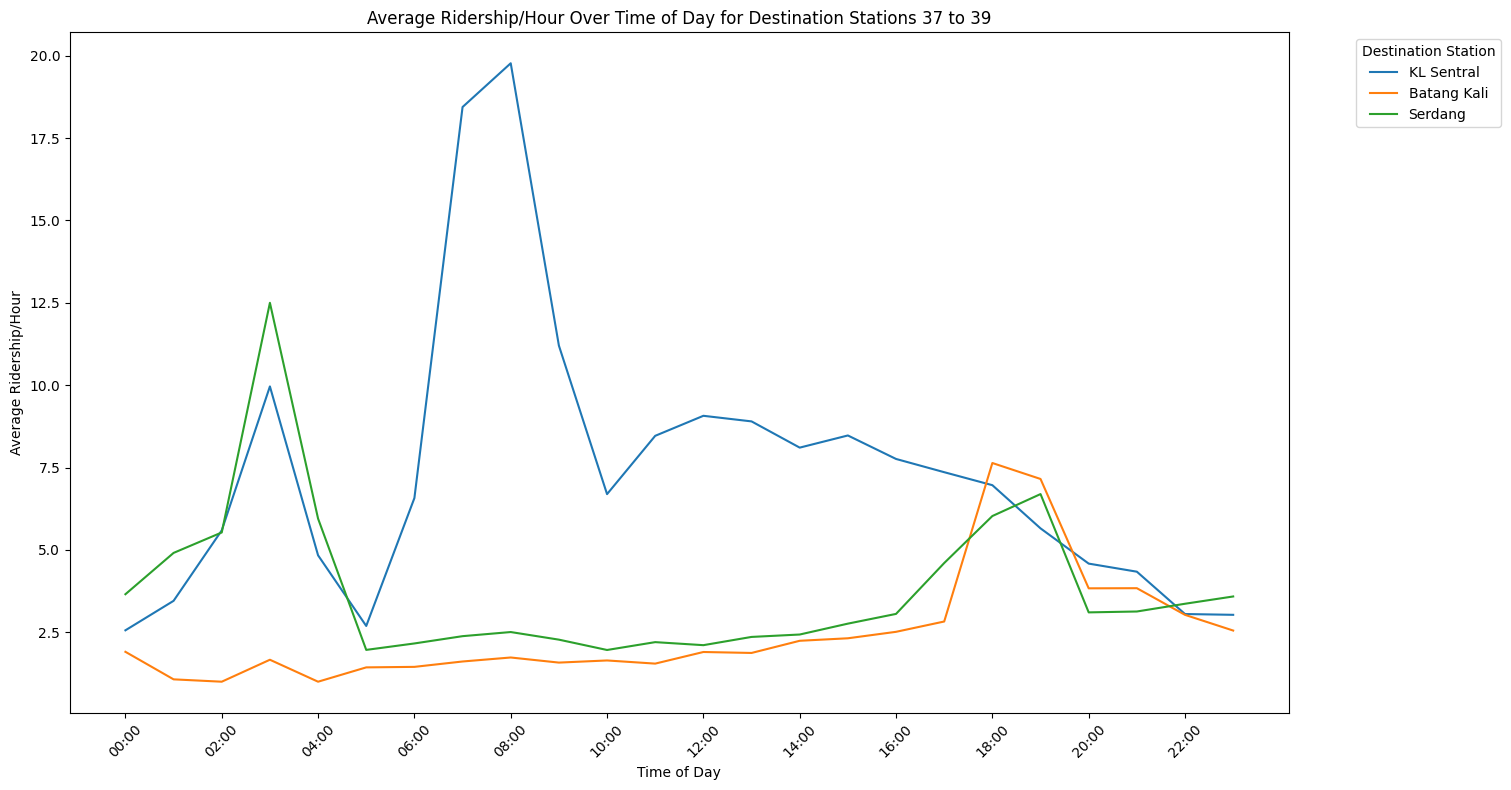

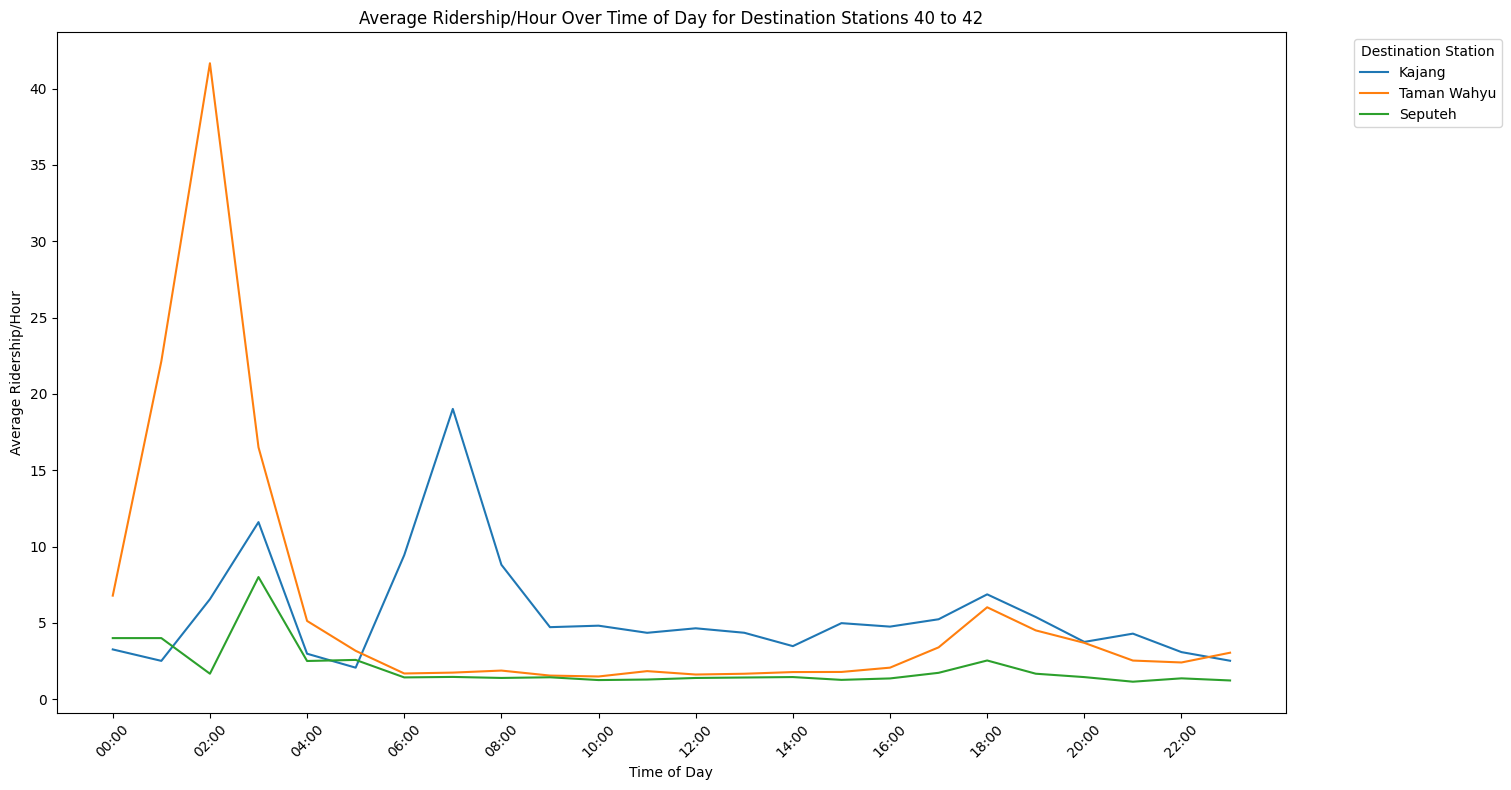

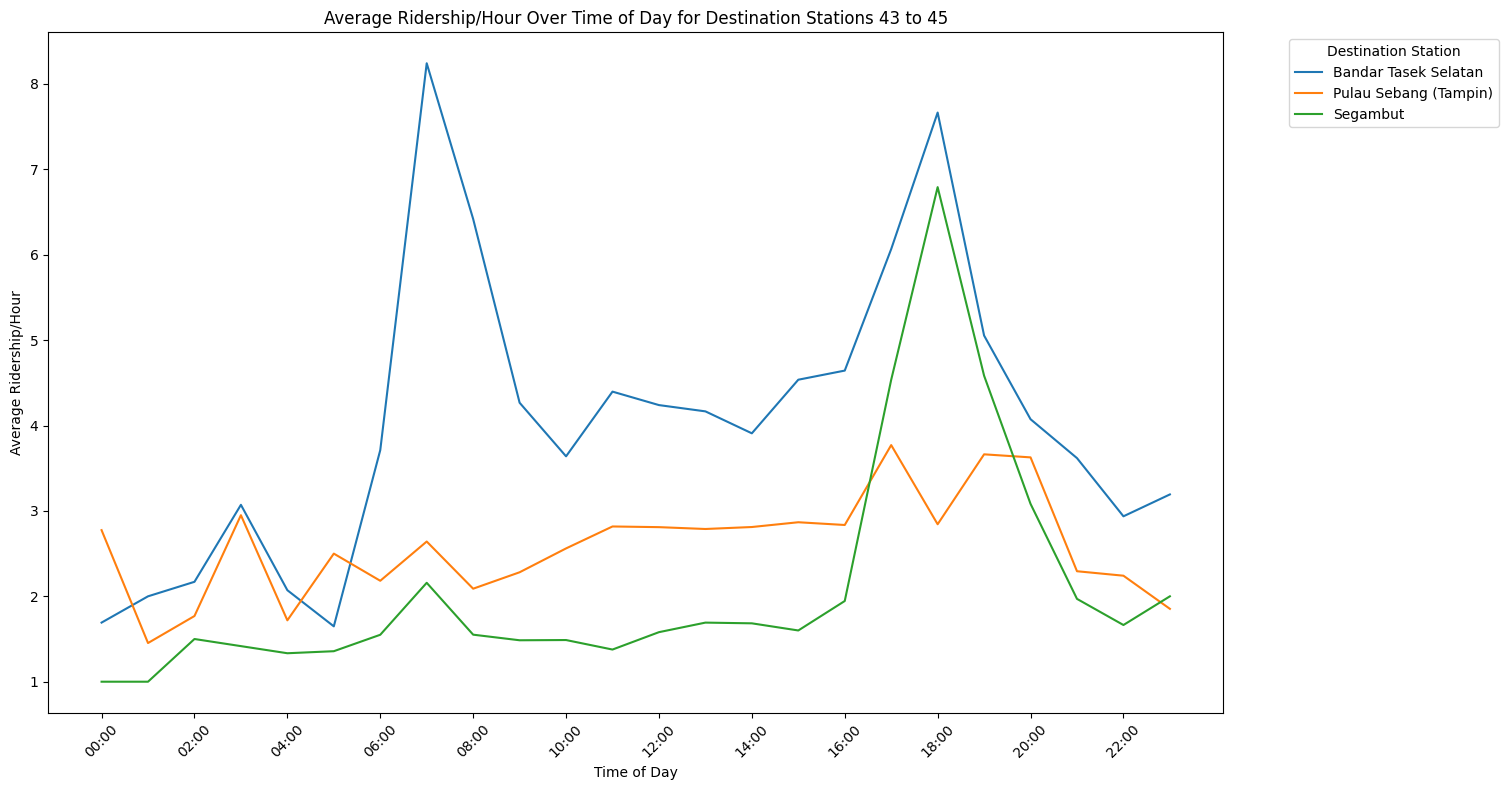

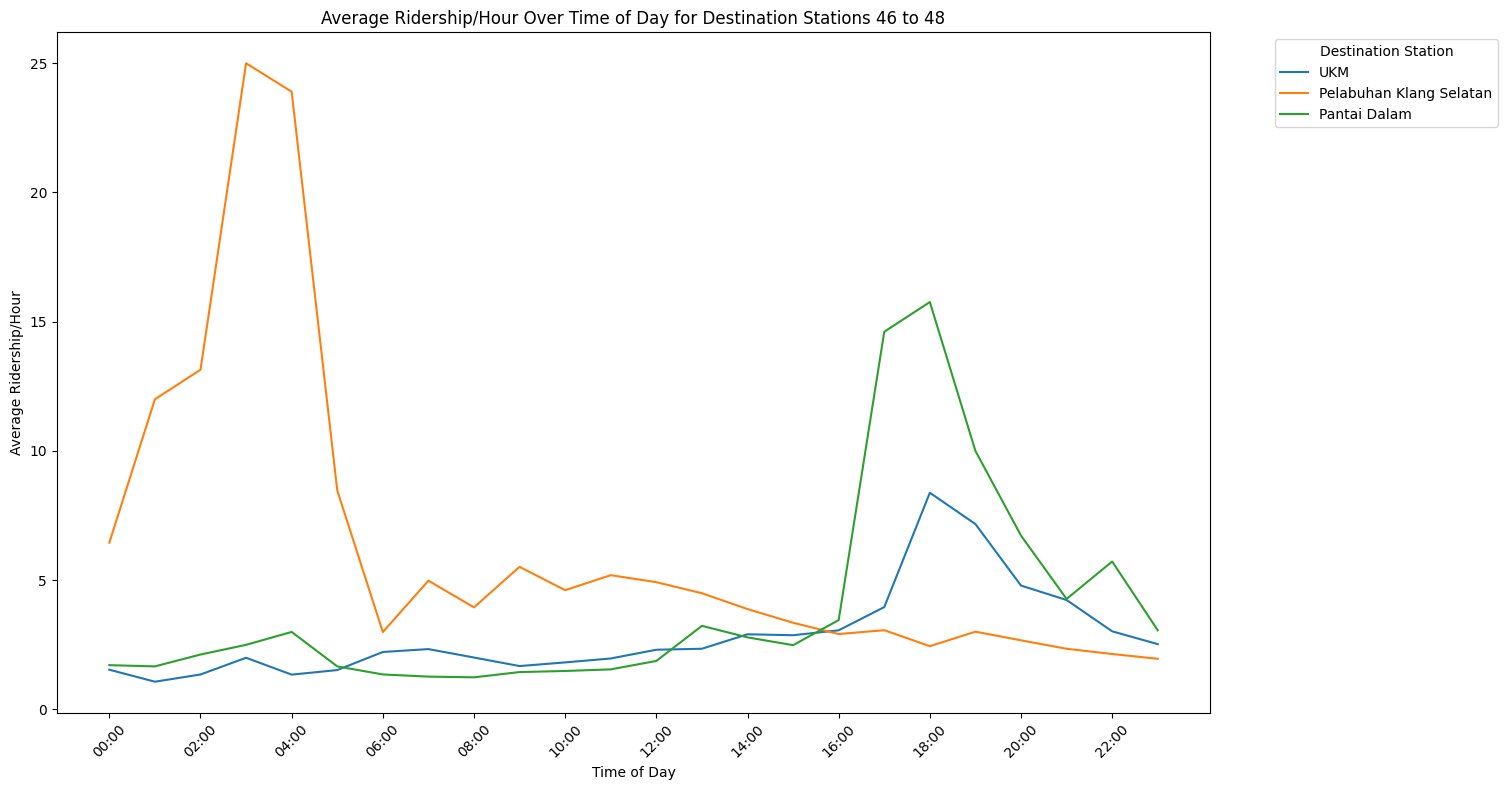

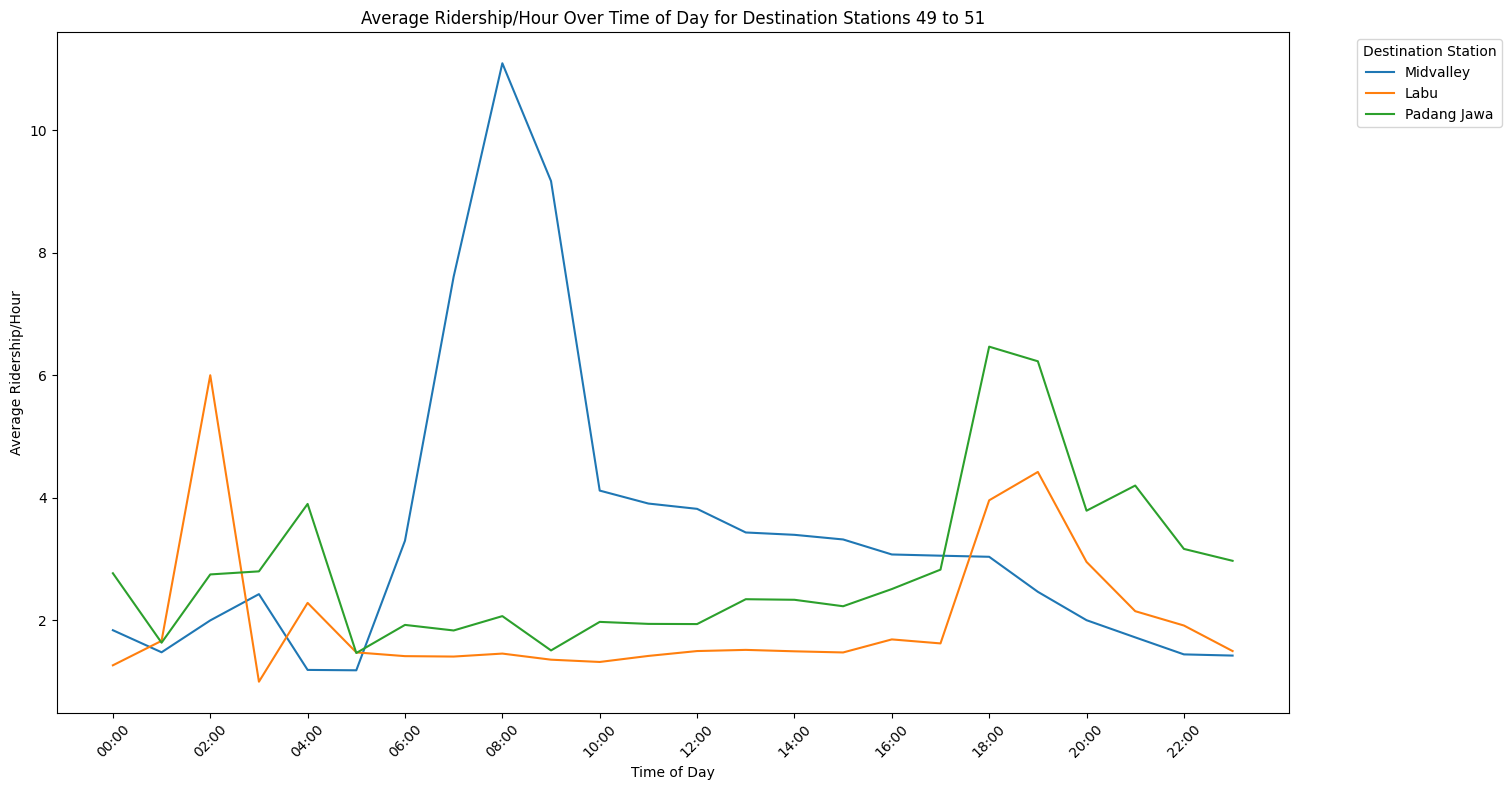

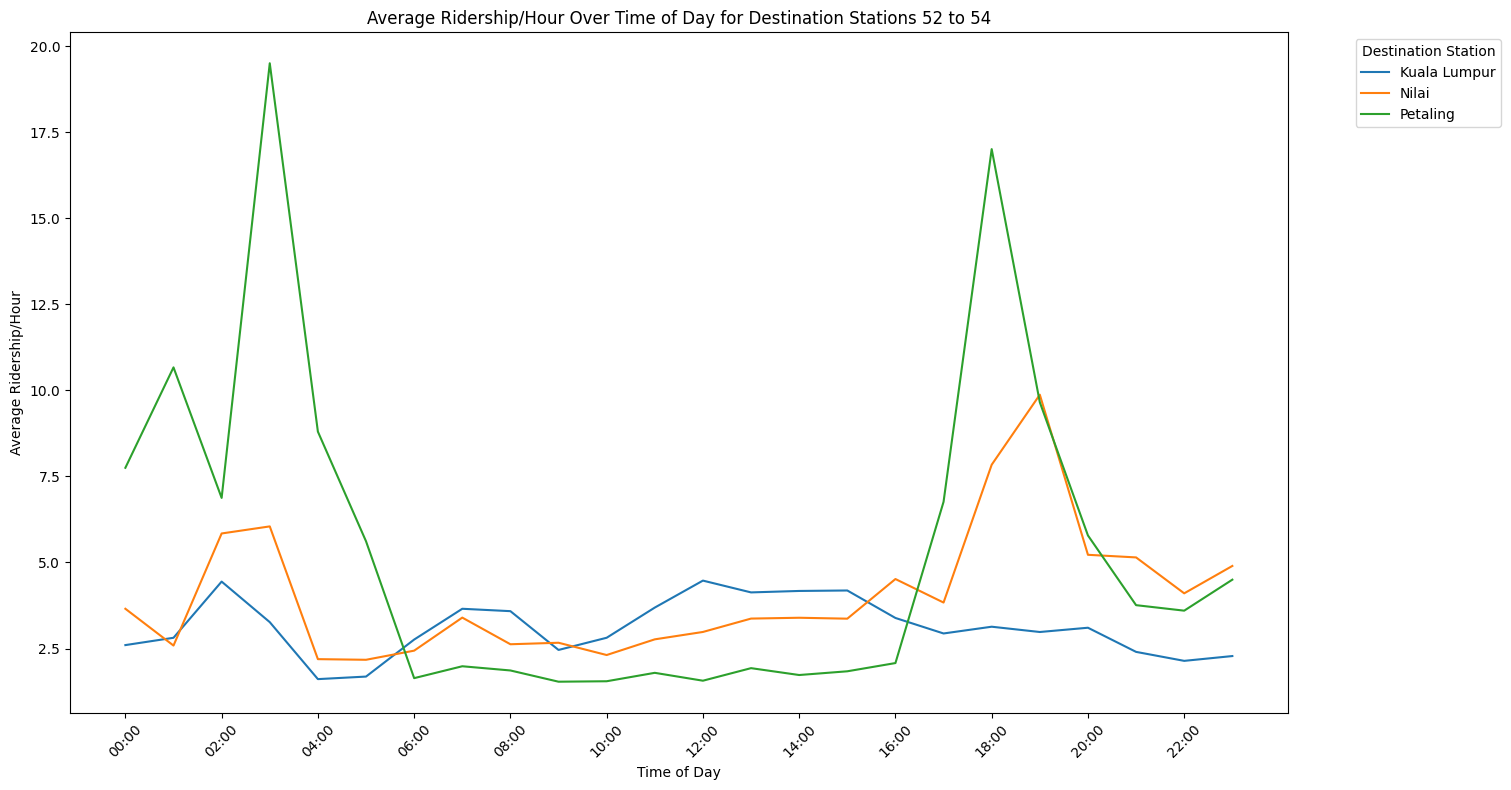

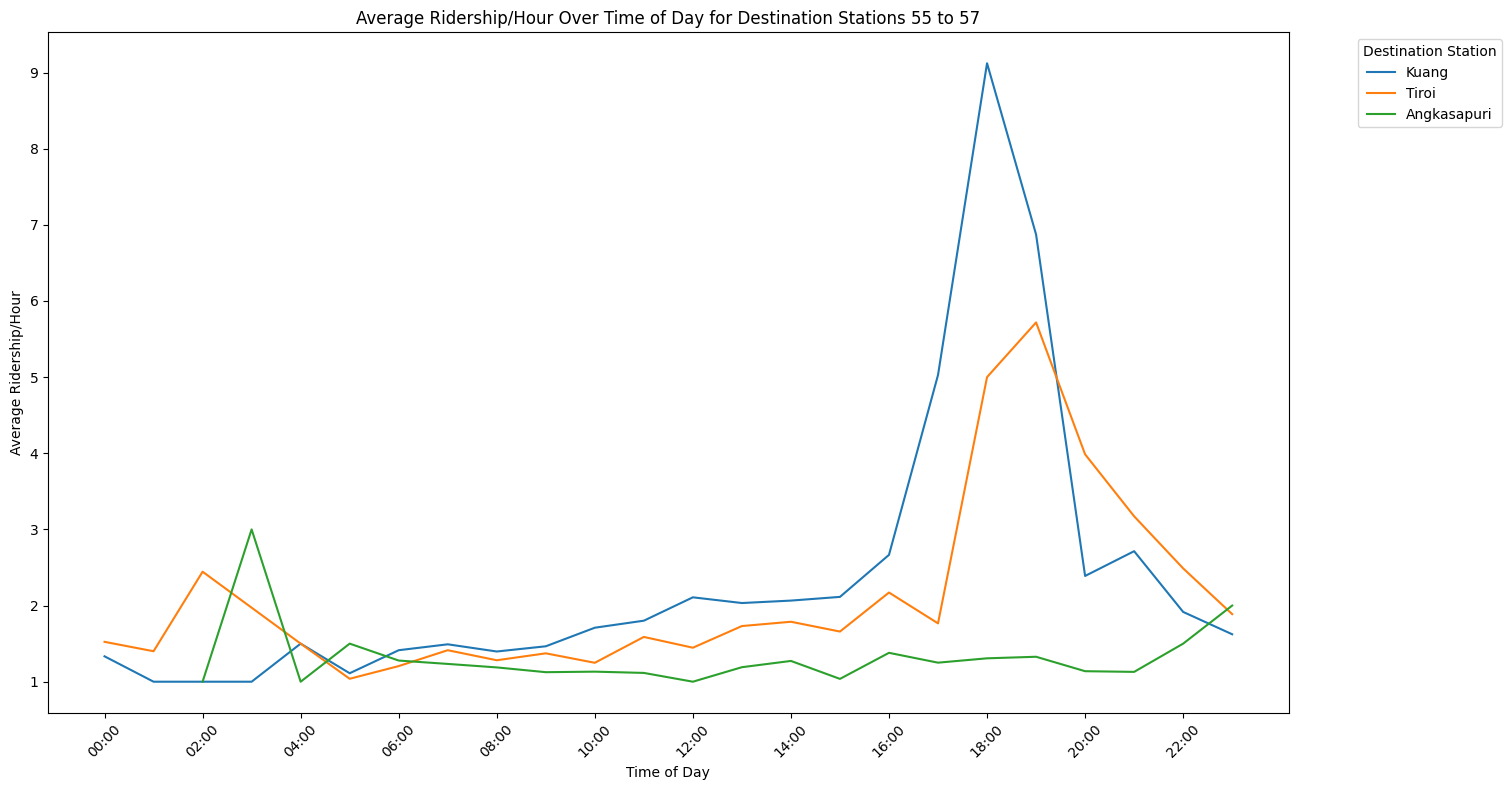

In [ ]:
# Group by 'destination' and 'time' and calculate the mean ridership
destination_time_ridership = merged_df3.groupby(['destination', 'time'])['ridership/hour'].mean().reset_index()

# Sort by time to ensure the line plots are chronological within each subplot
destination_time_ridership = destination_time_ridership.sort_values(by='time')

# Get the list of unique destination stations
unique_destinations = destination_time_ridership['destination'].unique()
num_destinations = len(unique_destinations)
destinations_per_plot = 3

# Calculate the number of plots needed
num_plots = (num_destinations + destinations_per_plot - 1) // destinations_per_plot

# Iterate through the unique destinations and create a plot for each group
for i in range(num_plots):
    # Determine the subset of destinations for the current plot
    start_index = i * destinations_per_plot
    end_index = min((i + 1) * destinations_per_plot, num_destinations)
    current_destinations = unique_destinations[start_index:end_index]

    # Filter the data for the current set of destinations
    data_to_plot = destination_time_ridership[destination_time_ridership['destination'].isin(current_destinations)].copy()

    # Create a line plot for the current subset of destinations
    plt.figure(figsize=(18, 8)) # Adjust figure size
    sns.lineplot(data=data_to_plot, x='time', y='ridership/hour', hue='destination')

    plt.title(f'Average Ridership/Hour Over Time of Day for Destination Stations {start_index + 1} to {end_index}')
    plt.xlabel('Time of Day')
    plt.ylabel('Average Ridership/Hour')

    # Improve readability of x-axis labels if there are many unique times
    num_labels = 12 # Display roughly 12 labels
    if len(data_to_plot['time'].unique()) > num_labels:
        tick_positions = data_to_plot['time'].unique()[::len(data_to_plot['time'].unique()) // num_labels]
        plt.xticks(tick_positions, rotation=45)
    else:
        plt.xticks(rotation=45)

    # Place the legend outside the plot to avoid clutter
    plt.legend(title='Destination Station', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

After evaluating the effect of origin and destination with the combination of time towards the ridership/hour, the following graph will show the 10 busiest commuter routes by calculating the ridership/hour for each routes.

<ipython-input-79-2e3071aa60f8>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_busiest_routes['route'] = top_10_busiest_routes['origin'] + ' to ' + top_10_busiest_routes['destination']
<ipython-input-79-2e3071aa60f8>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_ridership', y='route', data=top_10_busiest_routes, palette='viridis')


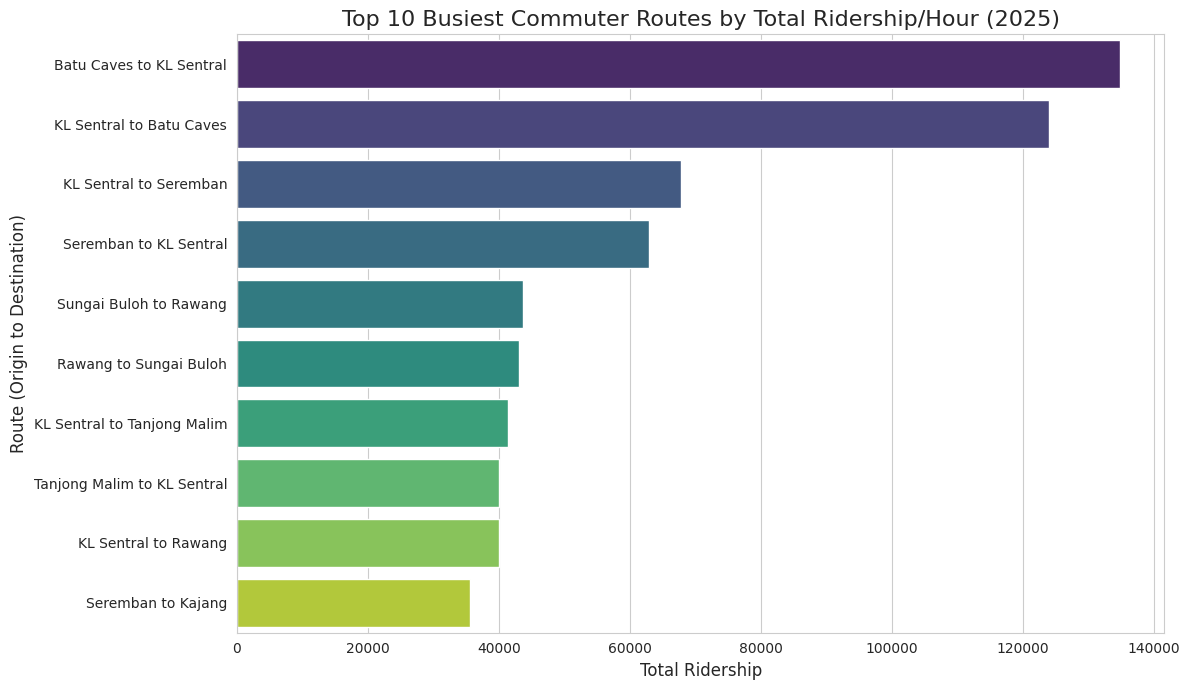

In [ ]:
# Group by 'origin' and 'destination' and sum the 'ridership/hour'
route_ridership = merged_df3.groupby(['origin', 'destination'])['ridership/hour'].sum().reset_index()
route_ridership = route_ridership.rename(columns={'ridership/hour': 'total_ridership'})
busiest_routes = route_ridership.sort_values(by='total_ridership', ascending=False)
top_10_busiest_routes = busiest_routes.head(10)

# Create a combined route string for easier labeling on the chart
top_10_busiest_routes['route'] = top_10_busiest_routes['origin'] + ' to ' + top_10_busiest_routes['destination']

# Set the style for the plot
sns.set_style("whitegrid")

# Create the bar chart
plt.figure(figsize=(12, 7)) # Adjust figure size as needed for readability

# Use seaborn's barplot for easier plotting with dataframes
sns.barplot(x='total_ridership', y='route', data=top_10_busiest_routes, palette='viridis')

# Add title and labels
plt.title('Top 10 Busiest Commuter Routes by Total Ridership/Hour (2025)', fontsize=16)
plt.xlabel('Total Ridership', fontsize=12)
plt.ylabel('Route (Origin to Destination)', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

### temp vs time vs ridership/hour
**How temperature and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The temperature in the range of 26°C to 30°C at the peak morning and evening commuter will having the highest ridership/hour.
<br><br>
**Actual:**<br>
The result shows that the temperature in the range of 25°C to 32°C at 1:00 AM to 3:00 AM, 7:00 AM to 8:00 AM and 6:00 PM to 7:00 PM will have the higher ridership/hour.

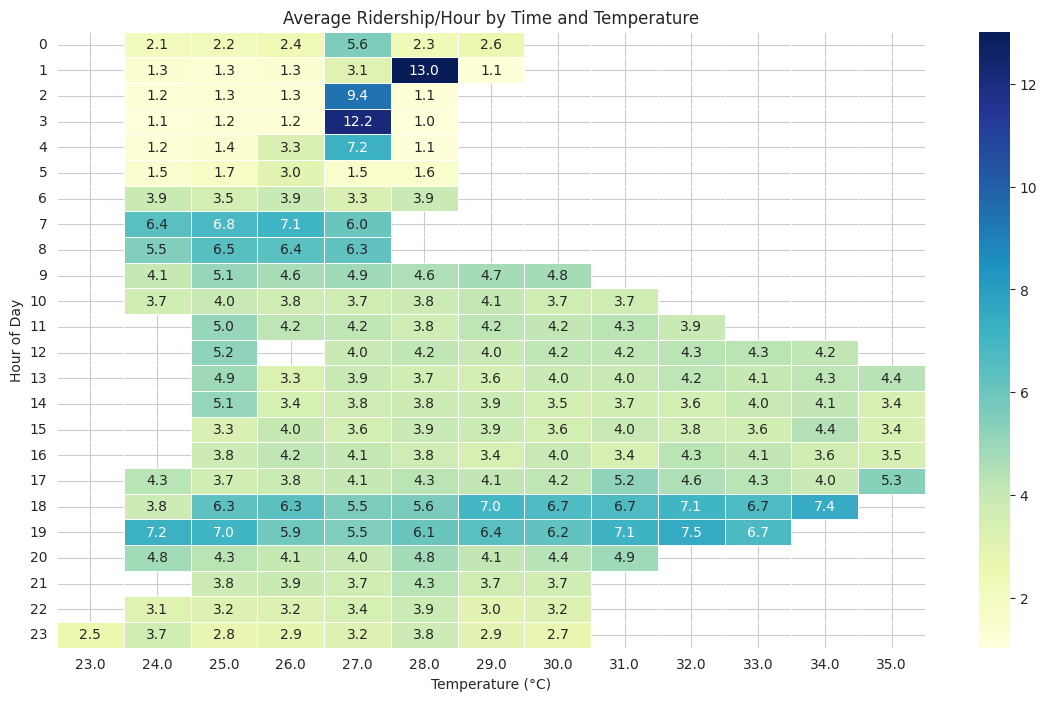

In [ ]:
# Create a new DataFrame that extracts hour and rounded temp without modifying merged_df3
heatmap_data = (
    merged_df3
    .assign(hour=pd.to_datetime(merged_df3['time'], format='%H:%M').dt.hour,
            temp_rounded=merged_df3['temp'].round())
    .groupby(['hour', 'temp_rounded'])['ridership/hour']
    .mean()
    .reset_index()
)

# Pivot to make heatmap
heatmap_pivot = heatmap_data.pivot(index='hour', columns='temp_rounded', values='ridership/hour')

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=0.5)
plt.title('Average Ridership/Hour by Time and Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Hour of Day')
plt.yticks(rotation=0)
plt.show()

### feelslike vs time vs ridership/hour
**How feelslike(temperature) and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The feelslike in the range of 26°C to 30°C at the peak morning and evening commuter will having the highest ridership/hour.
<br><br>
**Actual:**<br>
The result shows that the temperature in the range of 24°C to 26°C and 29°C to 40°C at 1:00 AM to 3:00 AM, 7:00 AM to 8:00 AM and 6:00 PM to 7:00 PM will have the higher ridership/hour.

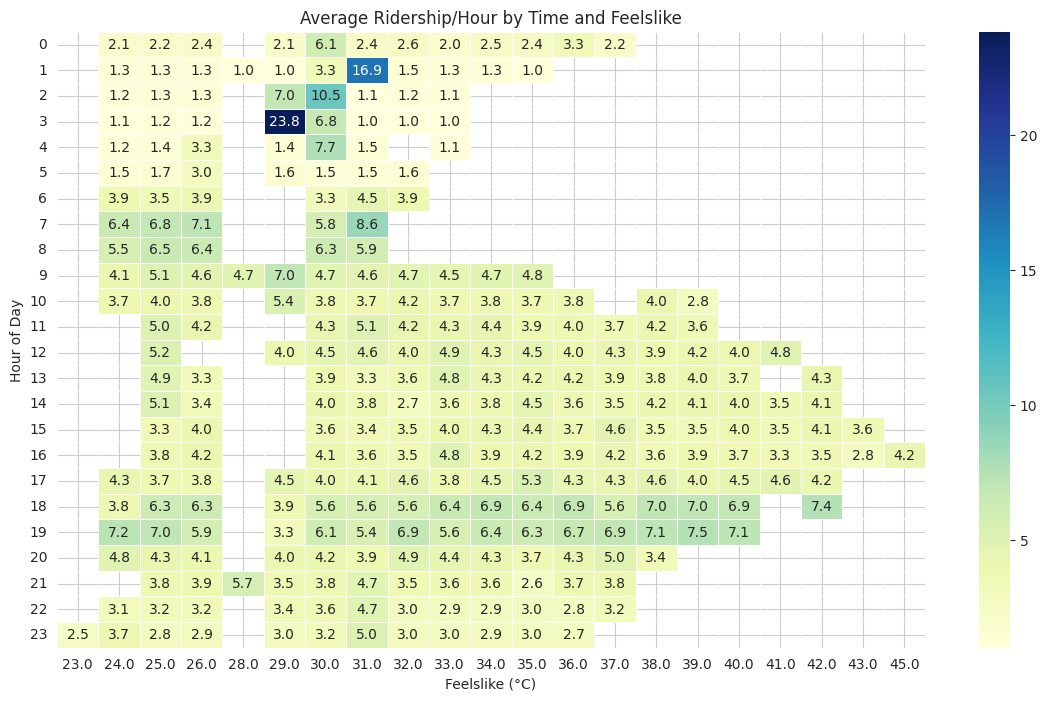

In [ ]:
# Create a new DataFrame that extracts hour and rounded feelslike without modifying merged_df3
heatmap_data = (
    merged_df3
    .assign(hour=pd.to_datetime(merged_df3['time'], format='%H:%M').dt.hour,
            temp_rounded=merged_df3['feelslike'].round())
    .groupby(['hour', 'temp_rounded'])['ridership/hour']
    .mean()
    .reset_index()
)

# Pivot to make heatmap
heatmap_pivot = heatmap_data.pivot(index='hour', columns='temp_rounded', values='ridership/hour')

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=0.5)
plt.title('Average Ridership/Hour by Time and Feelslike')
plt.xlabel('Feelslike (°C)')
plt.ylabel('Hour of Day')
plt.yticks(rotation=0)
plt.show()

### humidity vs time vs ridership/hour
**How humidity and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The humidity in the range of 60% to 80% at the peak morning and evening commuter will having the highest ridership/hour.
<br><br>
**Actual:**<br>
The result shows that the humidity at the range of 60% to 80% at 3:30 AM is having the highest ridership/hour.

<ipython-input-82-e5b712ed244f>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_ridership_by_humidity = temp_df.groupby(['time', 'humidity_bin'])['ridership/hour'].mean().reset_index()


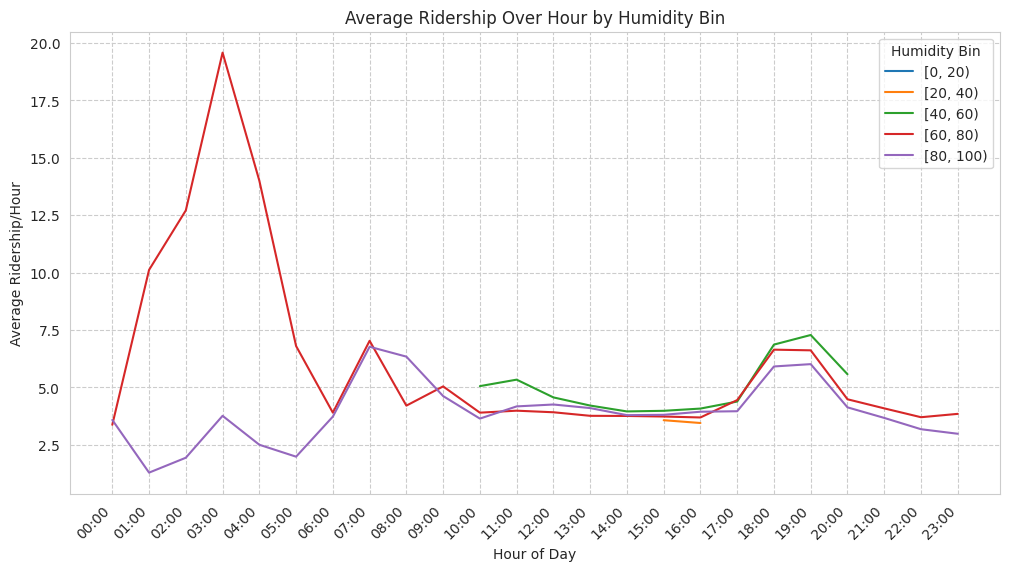

In [ ]:
# Define humidity bins
humidity_bins = [0, 20, 40, 60, 80, 100]  # Example bins for 0% to 100% humidity

# Create a temporary DataFrame with humidity bins without modifying merged_df3
temp_df = merged_df3.copy()
temp_df['humidity_bin'] = pd.cut(temp_df['humidity'], bins=humidity_bins, right=False, include_lowest=True)

# Group by hour and humidity bin, and calculate the mean ridership
hourly_ridership_by_humidity = temp_df.groupby(['time', 'humidity_bin'])['ridership/hour'].mean().reset_index()

# Drop rows where humidity_bin is NaN (if any humidity values fall outside the defined bins)
hourly_ridership_by_humidity.dropna(subset=['humidity_bin'], inplace=True)

# Sort the DataFrame by hour and humidity_bin for correct plotting order
hourly_ridership_by_humidity = hourly_ridership_by_humidity.sort_values(['time', 'humidity_bin'])

# Create a single line plot with color encoding for humidity bins
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_ridership_by_humidity, x='time', y='ridership/hour', hue='humidity_bin')
plt.title('Average Ridership Over Hour by Humidity Bin')
plt.xlabel('Hour of Day')
plt.ylabel('Average Ridership/Hour')
plt.xticks(range(0, 24), rotation=45, ha="right")
plt.grid(True, linestyle='--')
plt.legend(title='Humidity Bin')
plt.show()

### precip vs time vs ridership/hour
**How precipitation and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The ridership/hour will be higher at the peak morning and evening commuter with no precipitation.
<br><br>
**Actual:**<br>
On average, ridership is higher when there is no precipitation(rain) at 3:00 AM, 7:00 AM and 7:00 PM. There are another special cases such as at 8:00 AM, the ridership/hour is high regardless the precipitation status and at 6:00 PM, higher ridership/hour with the light precipitation.

<ipython-input-83-bae984f95533>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_ridership_by_precip = temp_df.groupby(['time', 'precip_bin'])['ridership/hour'].mean().reset_index()


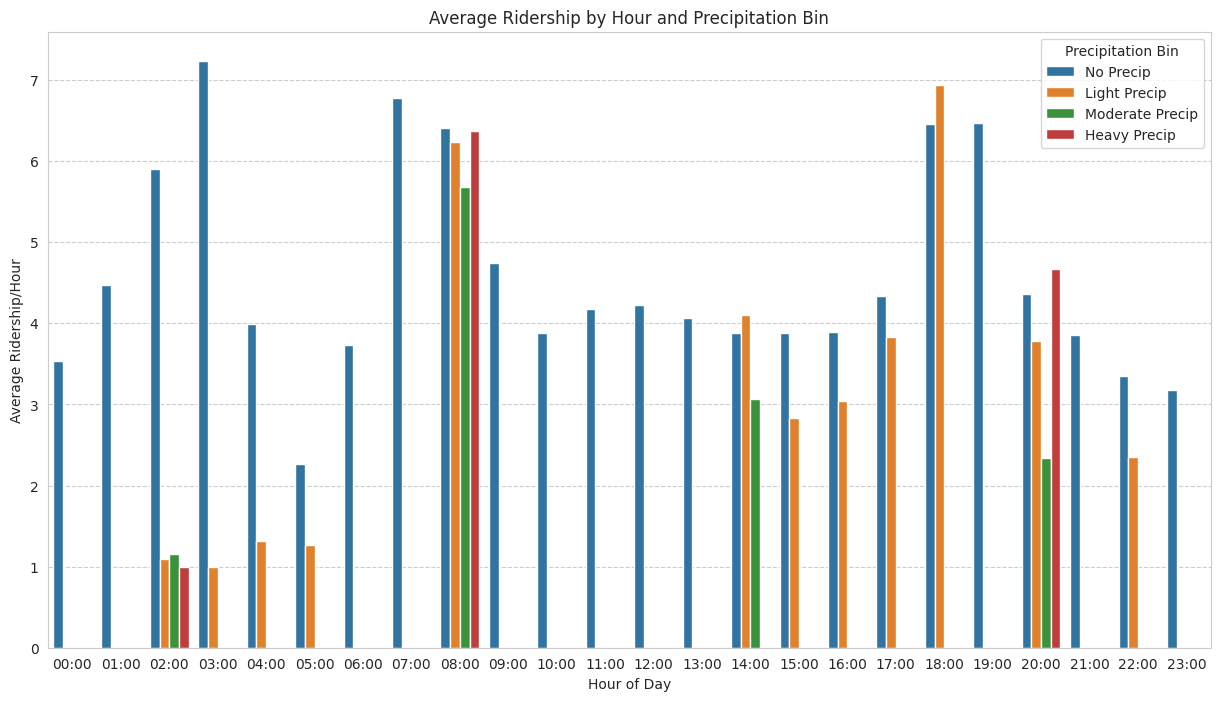

In [ ]:
# Define bins and labels
precip_bins = [-0.1, 0, 2.5, 7.6, merged_df3['precip'].max()]
precip_labels = ['No Precip', 'Light Precip', 'Moderate Precip', 'Heavy Precip']

# Create a temporary precip_bin Series without modifying merged_df3
precip_bin_series = pd.cut(merged_df3['precip'], bins=precip_bins, labels=precip_labels, right=True, include_lowest=True)

# Combine the original dataframe with this temporary Series for grouping
temp_df = merged_df3.assign(precip_bin=precip_bin_series)

# Drop rows with NaN in precip_bin (if any)
temp_df = temp_df.dropna(subset=['precip_bin'])

# Convert precip_bin to categorical with ordering for sorting and plotting
temp_df['precip_bin'] = pd.Categorical(temp_df['precip_bin'], categories=precip_labels, ordered=True)

# Group by hour and precip bin, calculate mean ridership
hourly_ridership_by_precip = temp_df.groupby(['time', 'precip_bin'])['ridership/hour'].mean().reset_index()

# Sort for plotting
hourly_ridership_by_precip = hourly_ridership_by_precip.sort_values(['time', 'precip_bin'])

# Plot
plt.figure(figsize=(15, 8))
sns.barplot(data=hourly_ridership_by_precip, x='time', y='ridership/hour', hue='precip_bin', errorbar=None)

plt.title('Average Ridership by Hour and Precipitation Bin')
plt.xlabel('Hour of Day')
plt.ylabel('Average Ridership/Hour')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--')
plt.legend(title='Precipitation Bin')
plt.show()

### precipprob vs time vs ridership/hour
**How precipitation probability and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
We propose that less probability of precipitation will result in higher ridership/hour at the morning and evening commuter.
<br><br>
**Actual:**<br>
On average, the lower the probability of precipitation, the higher the ridership/hour at 3:00 AM and 7:00 AM. The special case occurs at 6:00 PM where the higher the probability of precipitation, the higher the ridership/hour.

<ipython-input-84-499b6bb04517>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp_df.groupby(['time', 'precipprob_bin'])['ridership/hour'].mean().reset_index()


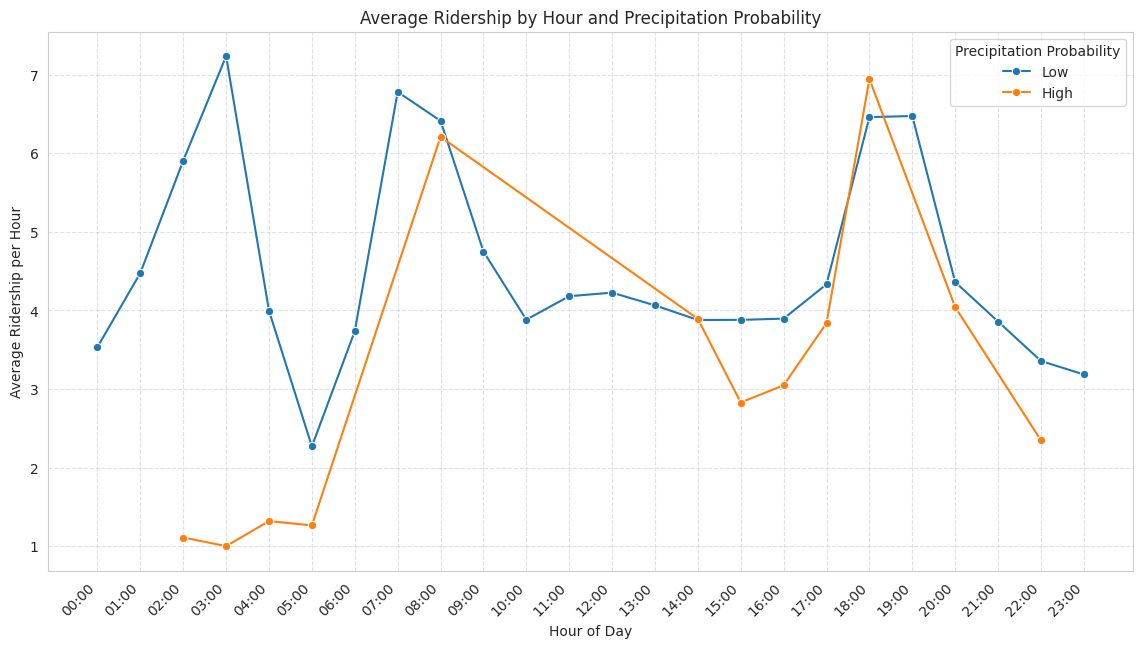

In [ ]:
# create precipprob bins
precipprob_bins = [0, 50, 100]
precipprob_labels = ['Low', 'High']

temp_df = merged_df3.copy()
temp_df['precipprob_bin'] = pd.cut(temp_df['precipprob'], bins=precipprob_bins, labels=precipprob_labels, include_lowest=True)

# Group by time and precipprob_bin, calculate mean ridership/hour
grouped = temp_df.groupby(['time', 'precipprob_bin'])['ridership/hour'].mean().reset_index()

# Plot
plt.figure(figsize=(14,7))
sns.lineplot(data=grouped, x='time', y='ridership/hour', hue='precipprob_bin', marker='o')

plt.title('Average Ridership by Hour and Precipitation Probability')
plt.xlabel('Hour of Day')
plt.ylabel('Average Ridership per Hour')
plt.xticks(range(0,24),rotation=45, ha="right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Precipitation Probability')
plt.show()

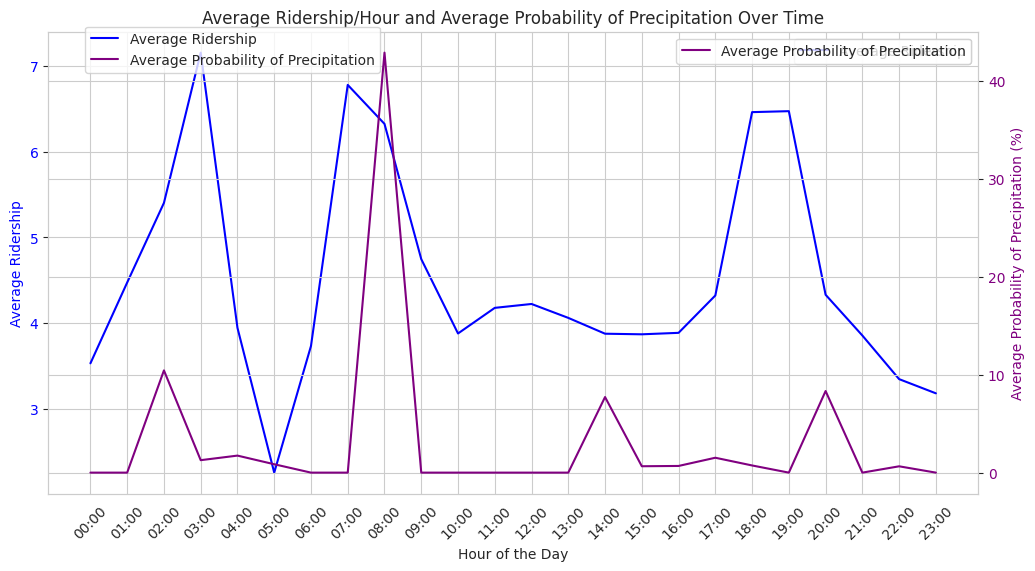

In [ ]:
# Group by hour and calculate the average ridership and average precipprob
average_data_by_hour = merged_df3.groupby('time')[['ridership/hour', 'precipprob']].mean().reset_index()

# Create a line plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average ridership on the primary y-axis
sns.lineplot(x='time', y='ridership/hour', data=average_data_by_hour, ax=ax1, color='blue', label='Average Ridership')
ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Average Ridership', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(24)) # Ensure all hours from 0 to 23 are shown on the x-axis
ax1.tick_params(axis='x', rotation=45)

# Create a secondary y-axis for average precipprob
ax2 = ax1.twinx()
sns.lineplot(x='time', y='precipprob', data=average_data_by_hour, ax=ax2, color='purple', label='Average Probability of Precipitation') # Using purple for precipprob
ax2.set_ylabel('Average Probability of Precipitation (%)', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')


# Add title and legends
plt.title('Average Ridership/Hour and Average Probability of Precipitation Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.9))

plt.grid(True)
plt.show()

### windspeed vs time vs ridership/hour
**How windspeed and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
We propose that slower windspeed will result in higher ridership/hour at the morning and evening commuter. A possible hypothesis is that higher windspeeds might deter people from using public transport like commuter, especially if they have to wait outdoors at stations. Strong winds could be uncomfortable or make walking to the station unpleasant, leading to lower ridership.
<br><br>
**Actual:**<br>
From the result, we found that the slower the windspeed, the higher the ridership/hour especially at 3:00 AM, 7:00 AM and 6:00 PM to 7:00 PM.

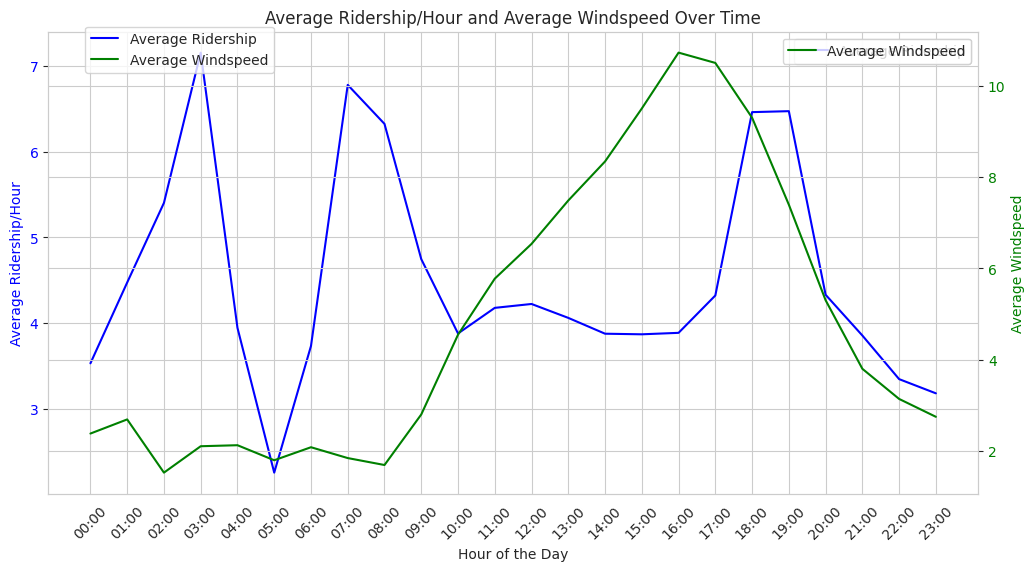

In [ ]:
# Group by hour and calculate the average ridership and average windspeed
average_data_by_hour = merged_df3.groupby('time')[['ridership/hour', 'windspeed']].mean().reset_index()

# Create a line plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average ridership on the primary y-axis
sns.lineplot(x='time', y='ridership/hour', data=average_data_by_hour, ax=ax1, color='blue', label='Average Ridership')
ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Average Ridership/Hour', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(24))
ax1.tick_params(axis='x', rotation=45)

# Create a secondary y-axis for average windspeed
ax2 = ax1.twinx()
sns.lineplot(x='time', y='windspeed', data=average_data_by_hour, ax=ax2, color='green', label='Average Windspeed') # Using green for windspeed
ax2.set_ylabel('Average Windspeed', color='green')
ax2.tick_params(axis='y', labelcolor='green')


# Add title and legends
plt.title('Average Ridership/Hour and Average Windspeed Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.9))

plt.grid(True)
plt.show()

### visibility vs time vs ridership/hour
**How visibility and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
We propose that the higher the visibility will result in higher ridership/hour at the morning and evening commuter. Lower visibility such as heavy rain or haze might affect the ridership/hour of the commuter.
<br><br>
**Actual:**<br>
Based on the line plot, the actual results appear to refute the hypothesis, which lower average visibility seems to be associated with higher average ridership, particularly during the morning and evening peak commuting hours.

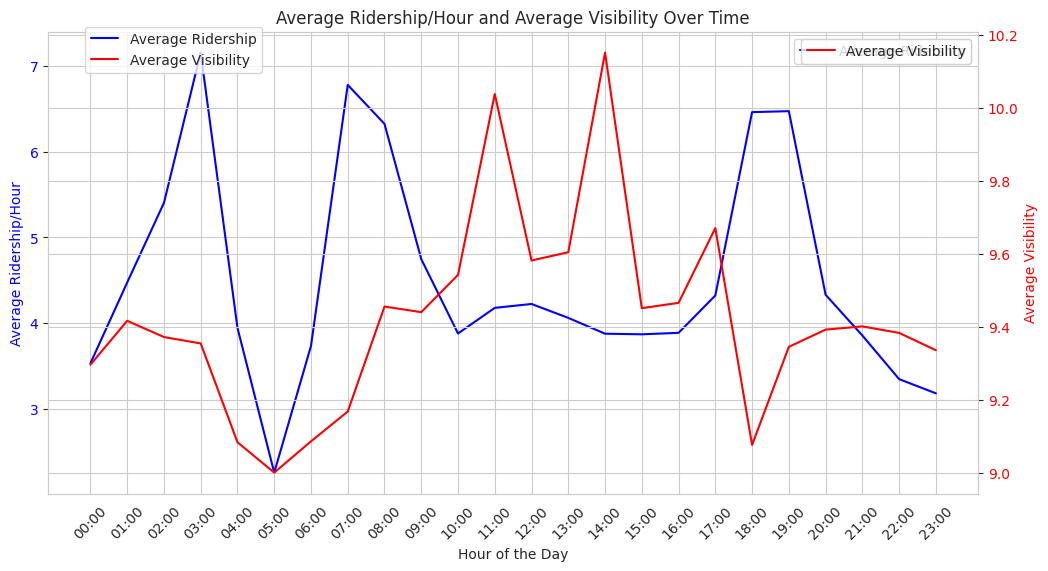

In [ ]:
# Group by hour and calculate the average ridership and average visibility
average_data_by_hour = merged_df3.groupby('time')[['ridership/hour', 'visibility']].mean().reset_index()

# Create a line plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average ridership on the primary y-axis
sns.lineplot(x='time', y='ridership/hour', data=average_data_by_hour, ax=ax1, color='blue', label='Average Ridership')
ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Average Ridership/Hour', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(24))
ax1.tick_params(axis='x', rotation=45)

# Create a secondary y-axis for average visibility
ax2 = ax1.twinx()
sns.lineplot(x='time', y='visibility', data=average_data_by_hour, ax=ax2, color='red', label='Average Visibility')
ax2.set_ylabel('Average Visibility', color='red')
ax2.tick_params(axis='y', labelcolor='red')


# Add title and legends
plt.title('Average Ridership/Hour and Average Visibility Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.9))

plt.grid(True)
plt.show()

### uvindex vs time vs ridership/hour
**How uvindex and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
Midday High UV Hypothesis: During the midday hours (when UV index is typically highest), higher UV index levels will be associated with lower Komuter ridership due to discomfort from heat and sun exposure.<br><br>

Peak Hours UV Hypothesis: During morning and evening peak commuting hours, the effect of UV index on ridership will be less pronounced compared to midday, as commuting necessity may override the impact of moderate UV levels.<br><br>

**Actual:**<br>
Midday High UV Actual: The plot supports this hypothesis. During midday hours (e.g., 10 AM to 4 PM), the average ridership is visually lower when the UV index is in the "High" or "Very High" bins compared to hours with "Low" or "Moderate" UV.
<br><br>
Peak Hours UV Actual: The plot also supports this hypothesis. During morning and evening peak hours, the difference in average ridership across different UV index bins appears less dramatic than during the midday hours. This suggests that while UV might have some influence, it's not as dominant a factor as during the hottest parts of the day.

<ipython-input-88-01171944d357>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_ridership_by_hour_uv = temp_df.groupby(['time', 'uvindex_bin_temp'])['ridership/hour'].mean().reset_index()


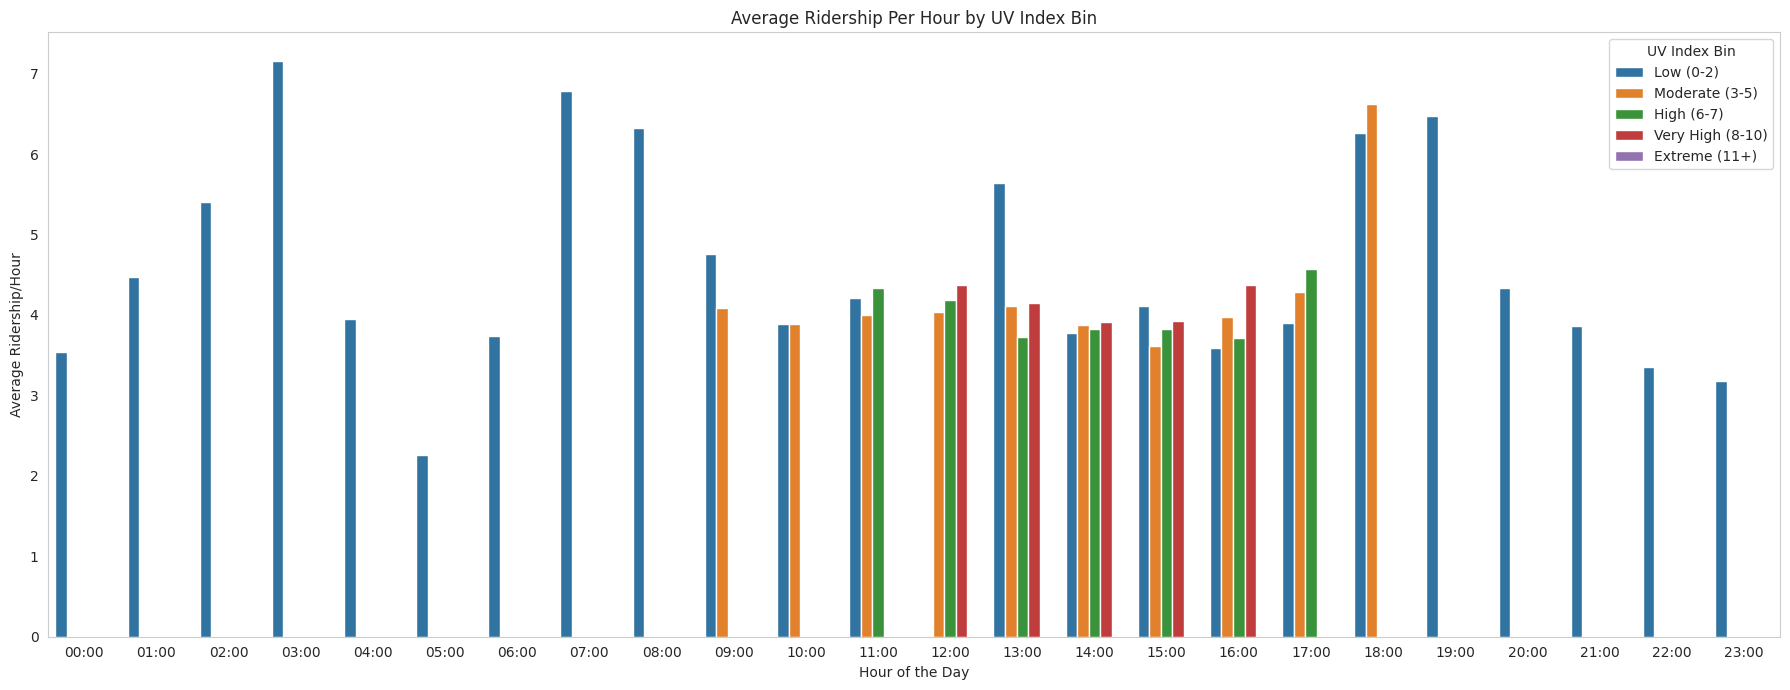

In [ ]:
# Define UV index bins and labels
uv_bins = [-1, 2, 5, 7, 10, merged_df3['uvindex'].max() + 1]
uv_labels = ['Low (0-2)', 'Moderate (3-5)', 'High (6-7)', 'Very High (8-10)', 'Extreme (11+)']

# Create a temporary Series for UV index bins (without modifying the original DataFrame)
uvindex_bins_temp = pd.cut(merged_df3['uvindex'], bins=uv_bins, labels=uv_labels, include_lowest=True, right=True)
uvindex_bins_temp = pd.Categorical(uvindex_bins_temp, categories=uv_labels, ordered=True)

# Create a temporary DataFrame for grouping
temp_df = merged_df3.copy()
temp_df['uvindex_bin_temp'] = uvindex_bins_temp

# Group by hour and temporary UV index bin and calculate mean ridership
average_ridership_by_hour_uv = temp_df.groupby(['time', 'uvindex_bin_temp'])['ridership/hour'].mean().reset_index()

# Create the grouped bar chart
plt.figure(figsize=(18, 7))
sns.barplot(x='time', y='ridership/hour', hue='uvindex_bin_temp', data=average_ridership_by_hour_uv)

plt.title('Average Ridership Per Hour by UV Index Bin')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Ridership/Hour')
plt.xticks(range(24))
plt.grid(axis='y')
plt.legend(title='UV Index Bin')
plt.tight_layout()
plt.show()

### ron95 vs ron97 vs diesel vs time vs ridership/hour
**How ron95, ron97 diesel and time affect the ridership/hour?**
<br><br>
**Hypothesis:**<br>
The higher the price of ron95, ron97 and diesel over time(entire day), the higher the ridership/hour.
<br><br>
**Actual:**<br>
The result shows that the higher the price of ron97 and diesel have prove that the higher the ridership/hour but not for ron95 since there is no significant change in the price of ron95 throughout the year.

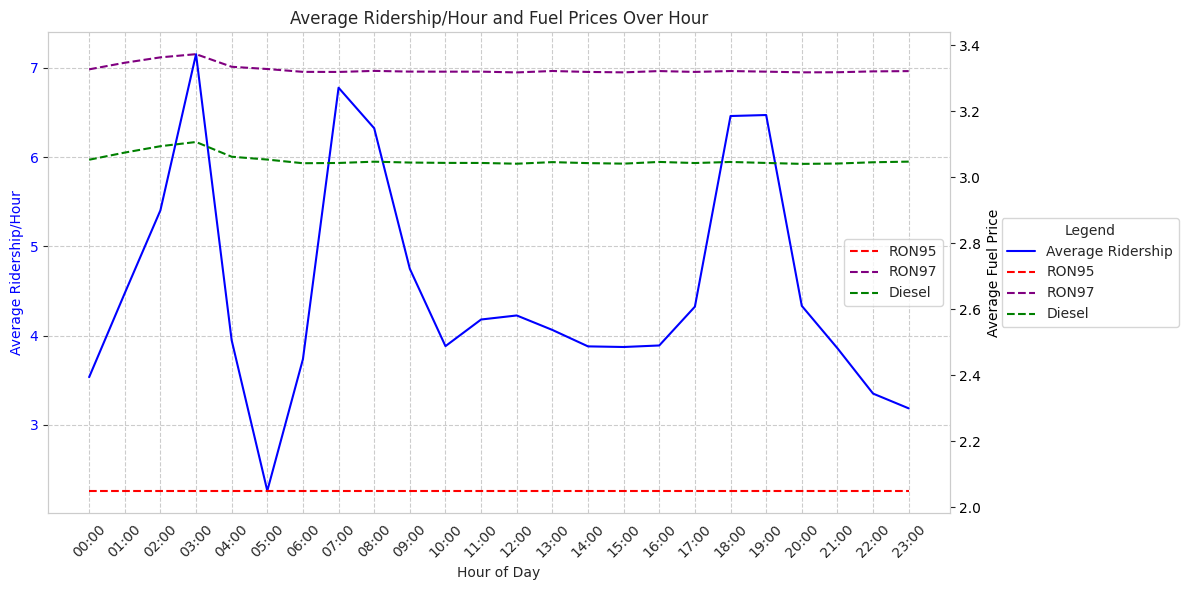

In [ ]:
# Select the relevant columns for fuel prices and ridership
fuel_cols = ['ron95', 'ron97', 'diesel']
plot_cols = fuel_cols + ['ridership/hour']

# Group by hour and calculate the mean for each relevant column
hourly_trends = merged_df3.groupby('time')[plot_cols].mean().reset_index()

# Create a figure and a primary axes for ridership
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot average ridership on the primary y-axis
sns.lineplot(data=hourly_trends, x='time', y='ridership/hour', ax=ax1, color='blue', label='Average Ridership')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Ridership/Hour', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary axes for fuel prices
ax2 = ax1.twinx()

# Plot average fuel prices on the secondary y-axis (labels will be used in the combined legend)
sns.lineplot(data=hourly_trends, x='time', y='ron95', ax=ax2, label='RON95', color='red', linestyle='--')
sns.lineplot(data=hourly_trends, x='time', y='ron97', ax=ax2, label='RON97', color='purple', linestyle='--')
sns.lineplot(data=hourly_trends, x='time', y='diesel', ax=ax2, label='Diesel', color='green', linestyle='--')

ax2.set_ylabel('Average Fuel Price', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(range(24))
ax1.tick_params(axis='x', rotation=45)

# Set the title
plt.title('Average Ridership/Hour and Fuel Prices Over Hour')

# Combine legend handles and labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# *Create* one single legend using the combined handles and labels and place it outside**
# By calling ax1.legend() only once, we ensure only one legend object is created.
# Using bbox_to_anchor places it outside the plot area.
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.05, 0.5), title='Legend')

# Important: Do NOT call ax2.legend() separately, as that would create a second legend.


ax1.grid(True, linestyle='--')
ax2.grid(False)

plt.tight_layout()
plt.show()

### temp vs feelslike vs humidity vs precip vs precipprob vs windspeed vs visibility vs uvindex vs time vs ridership/hour
**How temperature, feelslike(temperature), humidity, precipitation, precipitation probability, windspeed, visibility, uvindex and time affect on ridership/hour?**<br><br>

**Correlation**<br>
**Hypothesis:**<br>
High correlation between each features towards the ridership/hour by assuming their relation are linear.
<br><br>

**Actual:**<br>
The correlation between features like precipprob, precip, and time with ridership/hour is relatively low.
This is likely because the data is aggregated at an hourly level, so small fluctuations in weather or time may not cause significant changes in ridership within such short intervals.
<br><br>
**HOWEVER,** despite the low linear correlations observed, these features can still be valuable for training machine learning models to predict 'ridership/hour'. This is because:

1. **Non-Linear Relationships:** The relationship between these features and ridership might be non-linear. Linear correlation only captures straight-line relationships. Models that can handle non-linearity (such as tree-based models, polynomial regression, or neural networks) can potentially capture these complex patterns.

2. **Feature Interactions:** The impact of a feature on ridership might depend on the values of other features (feature interactions). While individual correlations might be low, combinations of features could have a stronger collective influence. Models can learn these interactions.

3. **Multicollinearity:** Sometimes, features are individually weakly correlated with the target but are strongly correlated with each other.

Correlations with Ridership/Hour:

diesel        0.021004
humidity      0.020917
ron97         0.020500
precipprob    0.017309
precip        0.012621
visibility   -0.002133
windspeed    -0.005819
temp         -0.027113
feelslike    -0.029699
uvindex      -0.039204
ron95              NaN
Name: ridership/hour, dtype: float64


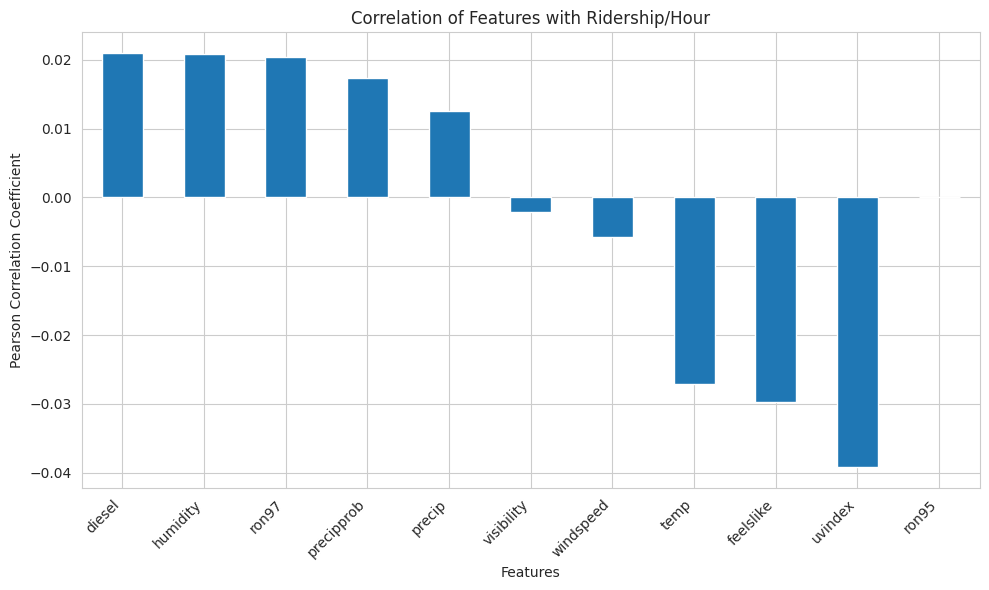

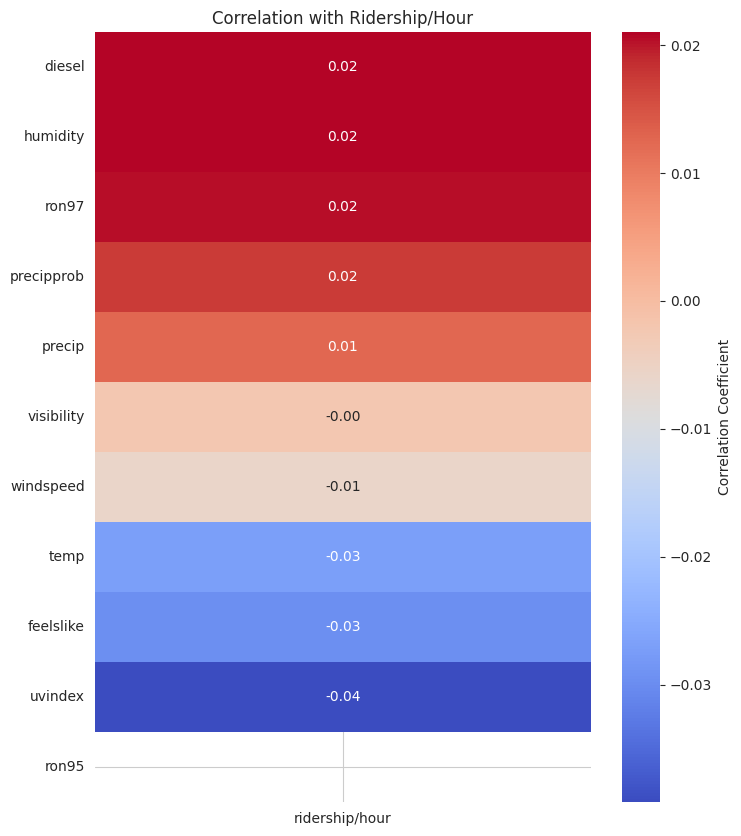

In [ ]:
# Select only numerical columns from the DataFrame
numerical_df = merged_df3.select_dtypes(include=np.number)

# Calculate the correlation of all numerical columns with 'ridership/hour'
# .corr() by default calculates Pearson correlation
correlations = numerical_df.corr()['ridership/hour'].sort_values(ascending=False)

# Exclude the self-correlation of 'ridership/hour' with itself
correlations = correlations.drop('ridership/hour')

print("Correlations with Ridership/Hour:\n")
print(correlations)

# Now you can use the 'correlations' Series for visualization as described before
# Bar plot
plt.figure(figsize=(10, 6))
correlations.plot(kind='bar')
plt.title('Correlation of Features with Ridership/Hour')
plt.xlabel('Features')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap (focused on target)
plt.figure(figsize=(8, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation with Ridership/Hour')
plt.yticks(rotation=0)
plt.show()

### P-values

**P-values**<br>

1. **isWeekend 0.000000e+00**<br>
    The p-value is extremely close to zero. This means that the variable isWeekend is highly statistically significant. We can be very confident that there is a relationship between whether it is a weekend and the ridership/hour, and this relationship is not due to random chance.<br><br>

2. **isHoliday 2.462641e-53**<br>
    The p-value is also extremely small. This indicates that the variable isHoliday is highly statistically significant. There is a strong statistical evidence to suggest that public holidays have a significant impact on ridership/hour.<br><br>

3. **ron95 4.837527e-01**<br>
    The p-value is 0.484, which is much larger than the common significance level of 0.05. This means that ron95 is not statistically significant in predicting ridership/hour based on this model. We cannot reject the null hypothesis that the coefficient for ron95 is zero, suggesting no strong linear relationship between the price of RON95 and ridership in this model.<br><br>

4. **ron97 2.818236e-01**<br>
    The p-value is 0.282, which is also larger than 0.05. Similar to ron95, ron97 is not statistically significant in predicting ridership/hour based on this model.<br><br>

5. **diesel 2.099013e-06**<br>
    The p-value is very small (2.099 x 10^-6), much less than 0.05. This indicates that the price of diesel is statistically significant in predicting ridership/hour.<br><br>

6. **temp 6.378777e-08**<br>
    The p-value is very small. temp is statistically significant, suggesting that temperature has a statistically significant relationship with ridership/hour.<br><br>

7. **feelslike 1.896290e-18**<br>
    The p-value is extremely small. feelslike is highly statistically significant, suggesting a very strong relationship between the "feels like" temperature and ridership/hour.<br><br>

8. **humidity 4.890974e-01**<br>
    The p-value is 0.489, larger than 0.05. humidity is not statistically significant in this model.<br><br>

9. **precip 6.739348e-03**<br>
    The p-value is 0.0067, which is less than 0.05. precip (precipitation) is statistically significant in predicting ridership/hour.<br><br>

10. **precipprob 4.497580e-17**<br>
    The p-value is extremely small. precipprob (precipitation probability) is highly statistically significant.<br><br>

11. **windspeed 9.588658e-44**<br>
    The p-value is extremely small. windspeed is highly statistically significant.<br><br>

12. **visibility 2.321931e-14**<br>
    The p-value is extremely small. visibility is highly statistically significant.<br><br>

13. **uvindex 1.038365e-150**<br>
    The p-value is extremely small. uvindex is highly statistically significant.

In [ ]:
# Define the target variable
y = merged_df3['ridership/hour']

# Select the features (all columns except the target and non-numeric ones like 'date', 'time', 'origin', 'destination')
# Drop 'date', 'time', 'origin', and 'destination' as they are not directly used as numerical features in a standard linear model
X = merged_df3.drop(columns=['ridership/hour', 'date', 'time', 'origin', 'destination'])

# Convert boolean columns to numeric (True becomes 1, False becomes 0)
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

# Add a constant to the independent variables matrix (for the intercept)
X = sm.add_constant(X)

# Fit the ordinary least squares (OLS) model
model = sm.OLS(y, X).fit()

# Print the p-values
print(model.pvalues)

isWeekend      0.000000e+00
isHoliday      2.462641e-53
ron95          4.837527e-01
ron97          2.818236e-01
diesel         2.099013e-06
temp           6.378777e-08
feelslike      1.896290e-18
humidity       4.890974e-01
precip         6.739348e-03
precipprob     4.497580e-17
windspeed      9.588658e-44
visibility     2.321931e-14
uvindex       1.038365e-150
dtype: float64


# Feature Engineering
This code is a crucial step in feature engineering for time-series or temporal data in machine learning. It transforms raw date and time information into numerical features ('day', 'month', 'time_sin', 'time_cos') that capture both linear aspects (day, month) and the cyclical nature of time (hour of the day). This allows machine learning models to better understand and utilize the temporal patterns in your data to predict ridership/hour.

In [ ]:
# Extract day and month
merged_df3['date'] = pd.to_datetime(merged_df3['date'], errors='coerce')

merged_df3['day'] = merged_df3['date'].dt.day
merged_df3['month'] = merged_df3['date'].dt.month

merged_df3['time'] = pd.to_datetime(merged_df3['time'], format='%H:%M', errors='coerce').dt.time

# Convert time to seconds since midnight
merged_df3['seconds'] = merged_df3['time'].apply(lambda t: t.hour * 3600 + t.minute * 60)

# Normalize to [0, 2π]
merged_df3['time_sin'] = np.sin(2 * np.pi * merged_df3['seconds'] / 86400)
merged_df3['time_cos'] = np.cos(2 * np.pi * merged_df3['seconds'] / 86400)

# Drop temporary columns if not needed
merged_df3.drop(columns=['seconds', 'time','date'], inplace=True)

merged_df3.head()

,origin,destination,isWeekend,isHoliday,ron95,ron97,diesel,temp,feelslike,humidity,precip,precipprob,windspeed,visibility,uvindex,ridership/hour,day,month,time_sin,time_cos
0,Abdullah Hukum,Klang,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1,1,1,0.0,1.0
1,Abdullah Hukum,Telok Pulai,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1,1,1,0.0,1.0
2,Bangi,Batu Caves,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1,1,1,0.0,1.0
3,Bank Negara,Sungai Gadut,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1,1,1,0.0,1.0
4,Batu Tiga,Kampung Raja Uda,False,True,2.05,3.25,2.95,25.0,25.0,94.04,0.0,0.0,0.0,10.0,0,1,1,1,0.0,1.0


In [ ]:
merged_df3 = merged_df3.drop(columns=['precipprob'])

# 2. Change the 'precip' column to a boolean
# Create a new boolean column based on whether 'precip' is greater than 0
if 'precip' in merged_df3.columns:
    merged_df3['precip'] = merged_df3['precip'] > 0
    # Optionally, drop the original 'precip' column if you only want the boolean
    # merged_df3 = merged_df3.drop(columns=['precip'])
    # print("Created 'precip_occurrence' boolean column and dropped original 'precip'.")
    print("Created 'precip_occurrence' boolean column.")
else:
    print("'precip' column not found.")

# Display the head of the modified DataFrame to verify
print("\nDataFrame head after modifications:")
print(merged_df3.head())

Created 'precip_occurrence' boolean column.

DataFrame head after modifications:
           origin       destination  isWeekend  isHoliday  ron95  ron97  \
0  Abdullah Hukum             Klang      False       True   2.05   3.25   
1  Abdullah Hukum       Telok Pulai      False       True   2.05   3.25   
2           Bangi        Batu Caves      False       True   2.05   3.25   
3     Bank Negara      Sungai Gadut      False       True   2.05   3.25   
4       Batu Tiga  Kampung Raja Uda      False       True   2.05   3.25   

   diesel  temp  feelslike  humidity  precip  windspeed  visibility  uvindex  \
0    2.95  25.0       25.0     94.04   False        0.0        10.0        0   
1    2.95  25.0       25.0     94.04   False        0.0        10.0        0   
2    2.95  25.0       25.0     94.04   False        0.0        10.0        0   
3    2.95  25.0       25.0     94.04   False        0.0        10.0        0   
4    2.95  25.0       25.0     94.04   False        0.0        10.0 

# Normalization
We begin by **selecting a set of numerical and categorical features**, along with the target variable (ridership/hour). To ensure data quality, any rows containing missing values in these columns are dropped. Next, the **categorical features** are **encoded numerically** using **LabelEncoder**, which **converts categories into integer labels** that machine learning models can interpret.

After encoding, the **dataset is split into training and testing sets**, with 80% of the data used for training and 20% for evaluation. Importantly, this **split occurs before scaling** to **prevent data leakage**. We then visualize the distribution of numerical features in the training data using histograms, allowing for an initial inspection of skewness or outliers. It proceeds to **normalize the numerical features** and the target variable using **RobustScaler**, which scales values based on their median and interquartile range—making it robust to outliers. This ensures that features with large differences in scale don't negatively impact model performance. Finally, the transformed training data is visualized again through histograms to confirm that the scaling has normalized the distributions appropriately.


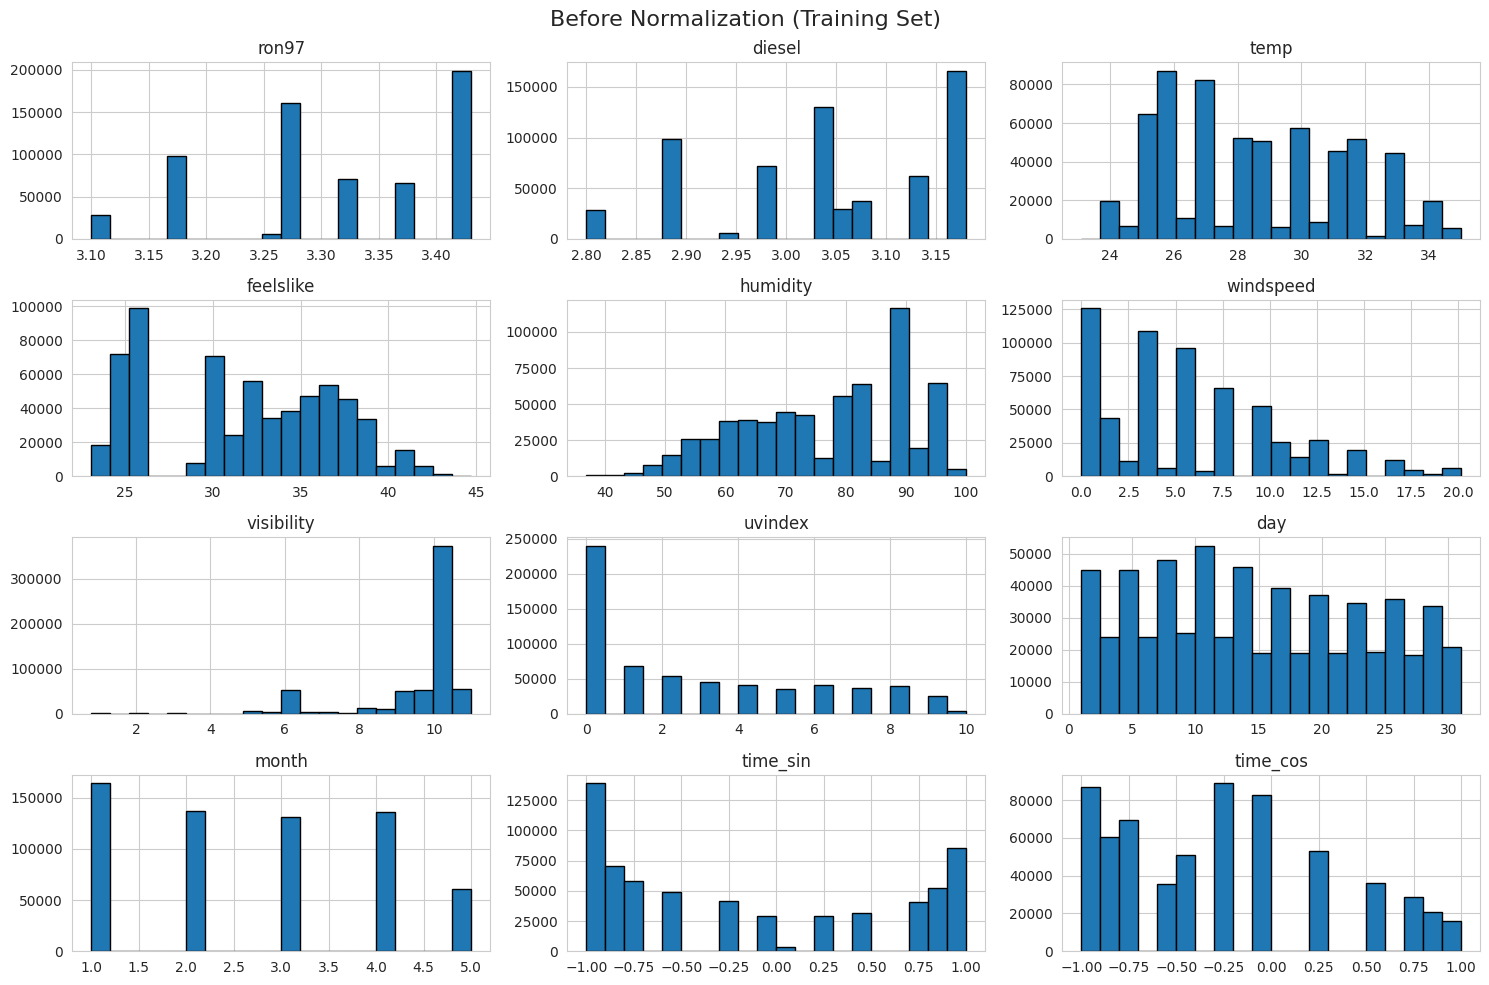

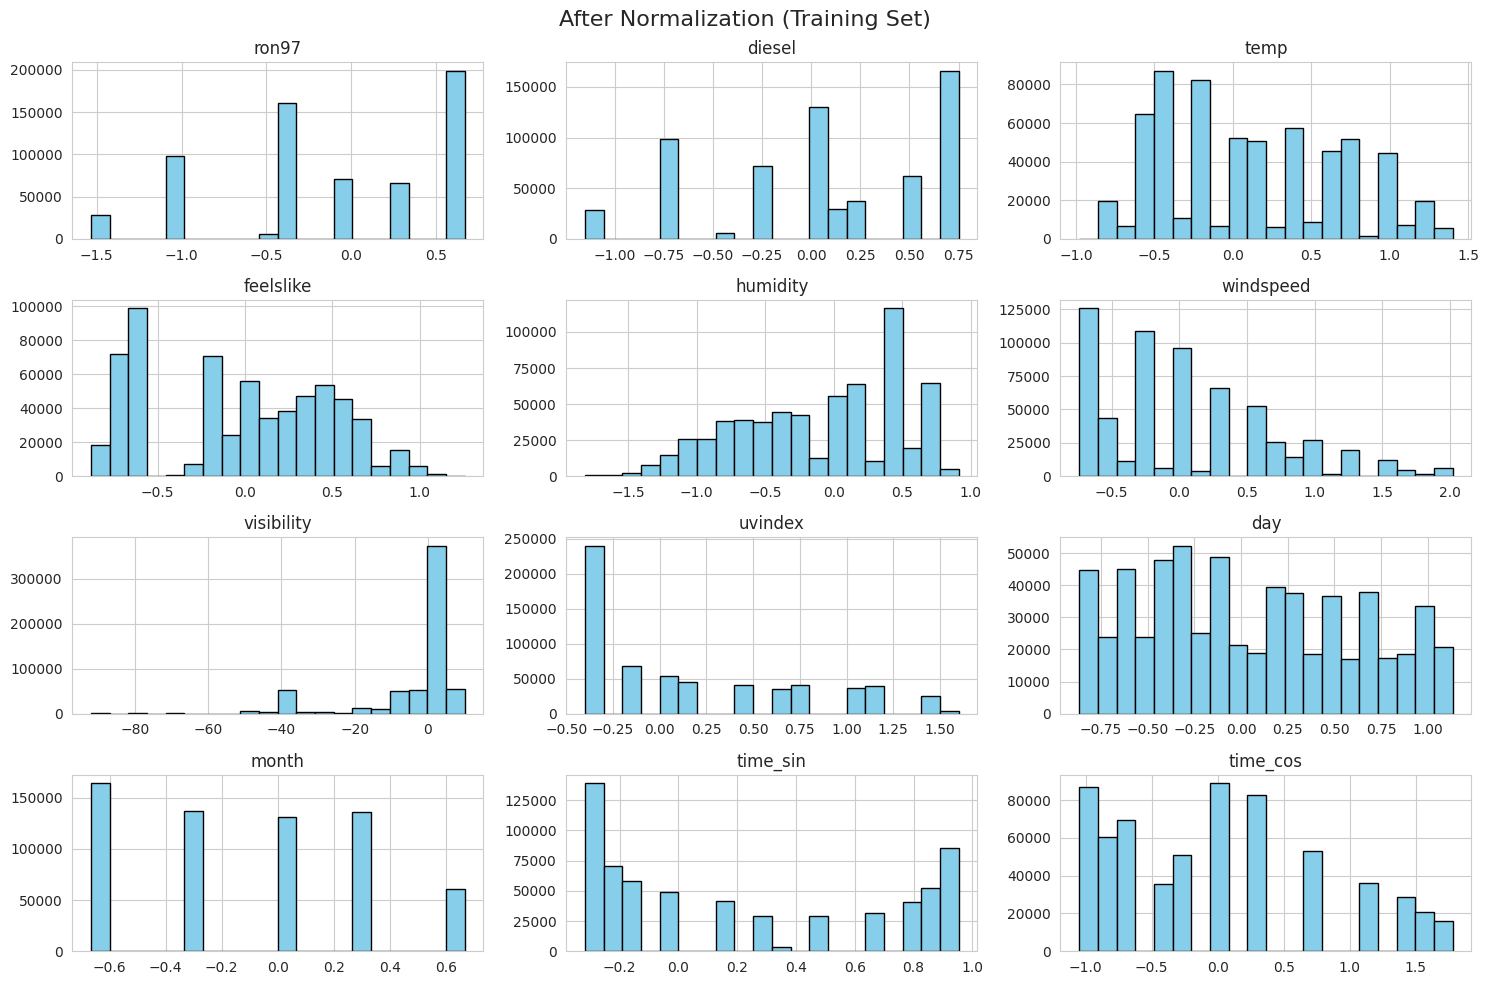

In [ ]:
# === STEP 1: Define features ===
numerical_features = [
    'ron97', 'diesel',
    'temp', 'feelslike', 'humidity',
    'windspeed', 'visibility', 'uvindex',
    'day', 'month', 'time_sin', 'time_cos'
]

categorical_features = ['origin', 'destination', 'isHoliday', 'isWeekend', 'precip']
target_column = 'ridership/hour'

# === STEP 2: Drop rows with missing values ===
all_columns = numerical_features + categorical_features + [target_column]
data = merged_df3[all_columns].dropna().copy()

# === STEP 3: Label Encode categorical features ===
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# === STEP 4: Split into train/test BEFORE normalization ===
X = data[numerical_features + categorical_features]
y = data[[target_column]]  # Keep it as DataFrame for scaler

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === STEP 5: Plot BEFORE normalization (on training set) ===
X_train_raw[numerical_features].hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle("Before Normalization (Training Set)", fontsize=16)
plt.tight_layout()
plt.show()

# === STEP 6: Normalize numerical features and target ===
scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train[numerical_features] = scaler_X.fit_transform(X_train_raw[numerical_features])
X_test[numerical_features] = scaler_X.transform(X_test_raw[numerical_features])

y_train = scaler_y.fit_transform(y_train_raw)
y_test = scaler_y.transform(y_test_raw)

# === STEP 7: Plot AFTER normalization (on training set) ===
pd.DataFrame(X_train, columns=X.columns)[numerical_features].hist(
    bins=20, figsize=(15, 10), edgecolor='black', color='skyblue'
)
plt.suptitle("After Normalization (Training Set)", fontsize=16)
plt.tight_layout()
plt.show()

# Feature Selection
We perform feature selection using a statistical method called **mutual information regression**, which measures the **dependency between each input feature and the target variable** in a **non-linear fashion**. The goal is to identify the top k most informative features for predicting the target. We set k to 15, meaning the top 15 features will be selected. The **SelectKBest** class from sklearn.feature_selection is used along with the mutual_info_regression scoring function to **evaluate** how much information **each feature contributes to predicting the target variable**.

The fit_transform method is applied to the training data (X_train, y_train) to learn the best features and transform the training set accordingly. The same transformation is then applied to the test set using transform. To identify which features were selected, the get_support() method returns a boolean mask indicating the chosen features, and these are extracted by applying the mask to the column names of X_train. Finally, the code prints out the names of the selected features. This process helps reduce dimensionality, eliminate irrelevant or redundant inputs, and potentially improve model performance and generalization.

From the printed result, we found that **'ron97', 'temp', 'feelslike', 'humidity', 'windspeed', 'visibility', 'uvindex', 'day', 'month', 'time_sin', 'time_cos', 'origin', 'destination', 'isWeekend', 'precip'** are selected.

In [ ]:
# Select number of top features you want
k = 15

# Using mutual_info_regression for non-linear feature selection
selector_mi = SelectKBest(score_func=mutual_info_regression, k=k)
X_train_mi_selected = selector_mi.fit_transform(X_train, y_train)
X_test_mi_selected = selector_mi.transform(X_test)

# Get selected feature indices and names
mask_mi = selector_mi.get_support()
selected_features_mi = pd.DataFrame(X_train).columns[mask_mi] if isinstance(X_train, pd.DataFrame) else mask_mi

print("Selected features using mutual_info_regression:")
print(selected_features_mi)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Selected features using mutual_info_regression:
Index(['diesel', 'temp', 'feelslike', 'humidity', 'windspeed', 'visibility',
       'uvindex', 'day', 'month', 'time_sin', 'time_cos', 'origin',
       'destination', 'isWeekend', 'precip'],
      dtype='object')


# Model Selection (Supervised Learning)
Since our target ridership/hour is a **numerical** column and we have this **label** in our dataset, we decided to do **supervised learning** by using regression model to predict the ridership/hour based on the features we selected in the feature selection part.

We have selected **Linear Regression, MLP Regressor, Decision Tree Regressor, XGBoost, Random Forest Regressor, Lightgbm, KNeighbors Regressor and Huber Regression** to train and evaluate the model.

# Model Training
Model training is the core step in machine learning where an algorithm learns patterns from data to make predictions or classifications. In simple terms, it’s the process of feeding input features and target labels into a model so it can "learn" the relationship between them. Once trained, the model can use this knowledge to make predictions on new, unseen data.

## Linear Regression
Linear regression is one of the simplest and most widely used machine learning algorithms, particularly for predicting a continuous numeric value. It models the relationship between one or more independent variables (features) and a dependent variable (target) by fitting a straight line.

In [ ]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model on your training data
lr_model.fit(X_train_mi_selected, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_mi_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

# Print results
print("Linear Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance:
MSE: 13.4267
RMSE: 3.6642
MAE: 1.5725
R² Score: 0.0143


### Hyperparameter tuning
Actually, there is no hyperparameters to tune in LinearRegression, while we can just fit it. However, we can improve or "fine-tune" the model by using the regularization methods like using Ridge.

In [ ]:
# Define the model
ridge = Ridge()

# Define hyperparameter space
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Use GridSearchCV to search best alpha
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train_mi_selected, y_train)

# Best model
best_model = grid.best_estimator_

# Evaluate
y_pred_ridge = best_model.predict(X_test_mi_selected)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print("Best alpha:", grid.best_params_['alpha'])
print("Ridge Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Best alpha: 10.0
Ridge Regression Performance:
MSE: 13.4267
RMSE: 3.6642
MAE: 1.5725
R² Score: 0.0143


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

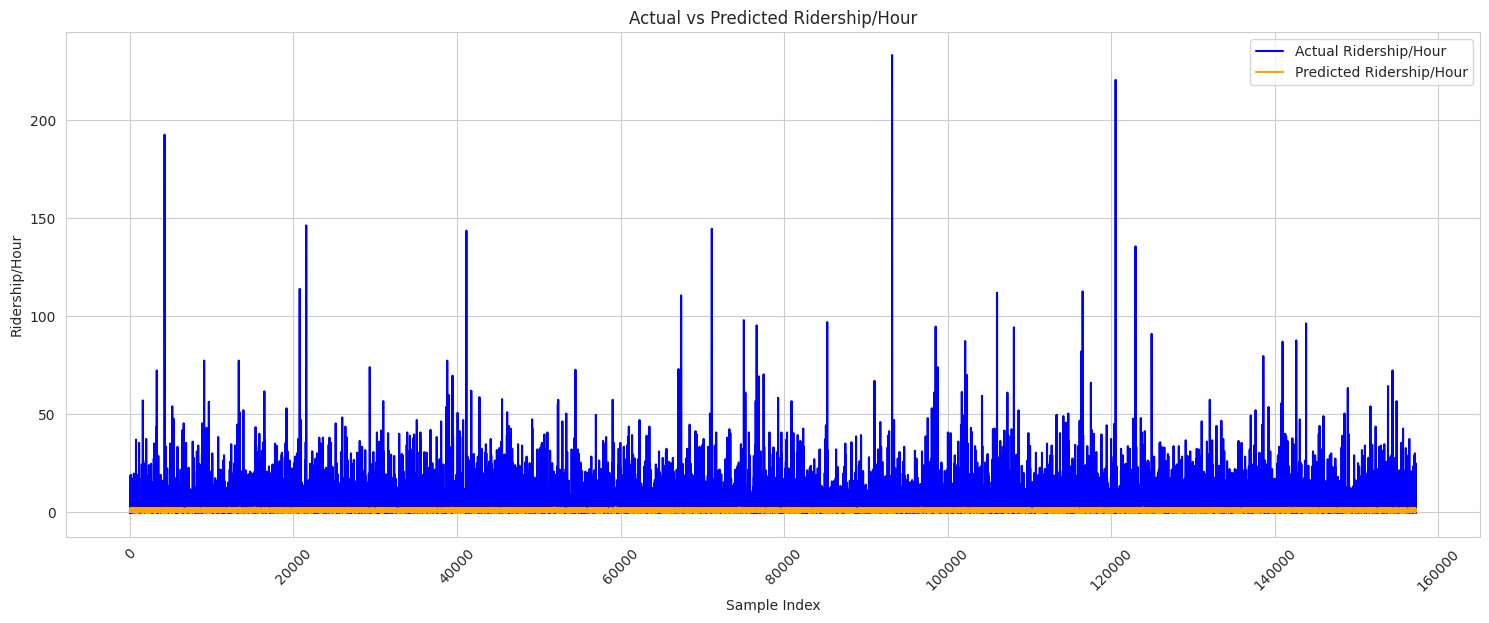

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_ridge.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## MLP Regressor
MLPRegressor stands for Multi-Layer Perceptron Regressor. It's a machine learning model in scikit-learn that uses a neural network to predict continuous numeric values. It’s more powerful than linear regression because it can model non-linear relationships between features and the target variable.

In [ ]:
# Initialize MLPRegressor with some parameters
mlp = MLPRegressor(hidden_layer_sizes=(100,100), activation='relu', solver='adam', max_iter=100, random_state=42)

# Train the regressor
mlp.fit(X_train_mi_selected, y_train)

# Predict on test data
y_pred_mlp = mlp.predict(X_test_mi_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_mlp)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)

# Print results
print("MLP Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Regression Performance:
MSE: 7.4909
RMSE: 2.7369
MAE: 1.3596
R² Score: 0.4501


### Hyperparameter tuning
This code performs hyperparameter tuning for an MLPRegressor using Grid Search with Cross-Validation (GridSearchCV). The goal is to find the combination of hyperparameters that gives the best prediction performance on unseen data by minimizing prediction error (MSE).

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(100, 100)],
    'activation': ['tanh'],
    'solver': ['adam'],
    'learning_rate_init': [0.001]
}

mlp = MLPRegressor(max_iter=100, random_state=42)

grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=2, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_mi_selected, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")

# Predict on test set using best estimator
best_mlp = grid_search.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_mi_selected)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred_mlp)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)

print("MLP Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.001, 'solver': 'adam'}
Best CV MSE: 7.7133
MLP Regression Performance:
MSE: 6.7272
RMSE: 2.5937
MAE: 1.2485
R² Score: 0.5061


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

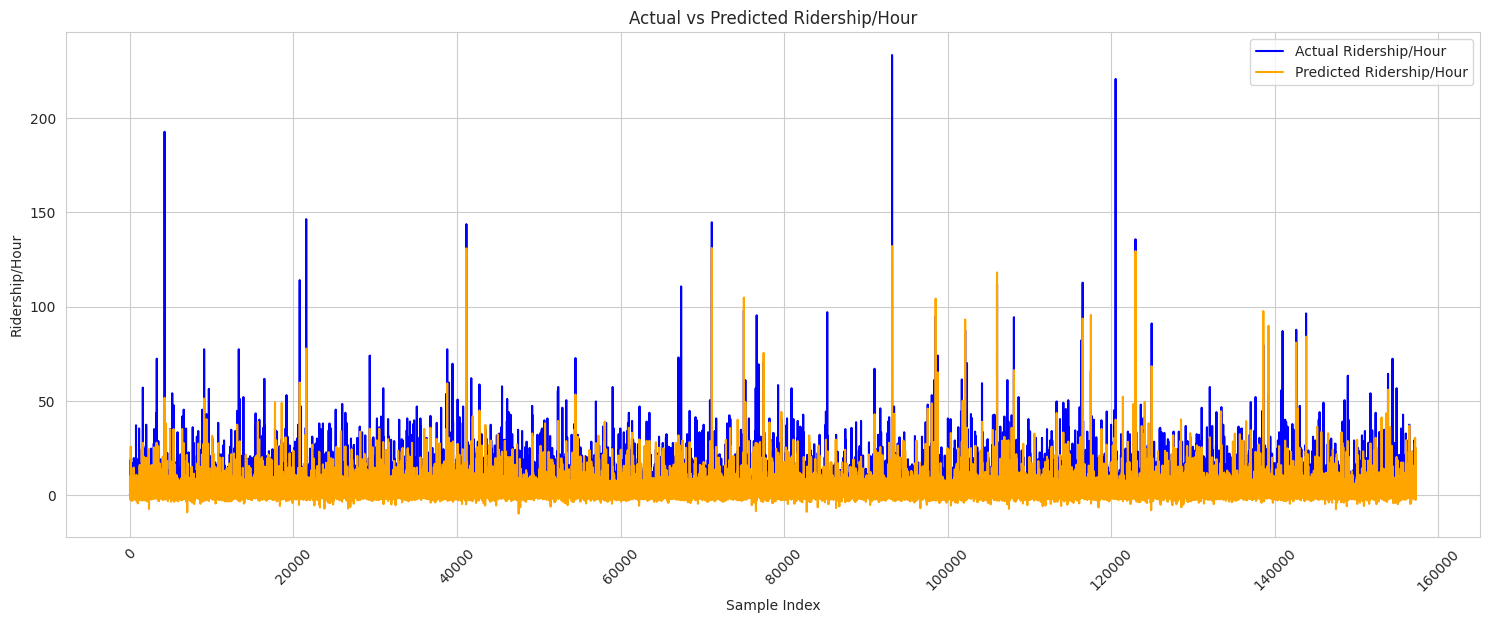

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_mlp.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## DecisionTree Regressor
DecisionTreeRegressor is a machine learning model from scikit-learn used for predicting continuous numerical values. It works by splitting the dataset into smaller and smaller parts (branches), based on the values of input features, in order to make the most accurate predictions.

In [ ]:
# 1. Initialize the Decision Tree model
dt_model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=None,
    random_state=42             # Reproducibility
)

# 2. Train the model on training data
dt_model.fit(X_train_mi_selected, y_train)

# 3. Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_mi_selected)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

# Print results
print("Decision Tree Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Decision Tree Regression Performance:
MSE: 4.7822
RMSE: 2.1868
MAE: 0.8523
R² Score: 0.6489


### Hyperparameter tuning
This code performs hyperparameter tuning for a DecisionTreeRegressor using GridSearchCV, which systematically searches for the best combination of parameters to improve model performance. GridSearchCV automates the search for the best decision tree hyperparameters by exhaustively testing combinations. Cross-validation ensures the selected hyperparameters generalize well.

In [ ]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train_mi_selected, y_train)

best_dt_model = grid.best_estimator_
y_pred_dt = best_dt_model.predict(X_test_mi_selected)

mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print("Best Parameters:", grid.best_params_)
print("Decision Tree Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Decision Tree Regression Performance:
MSE: 3.8683
RMSE: 1.9668
MAE: 0.7534
R² Score: 0.7160


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

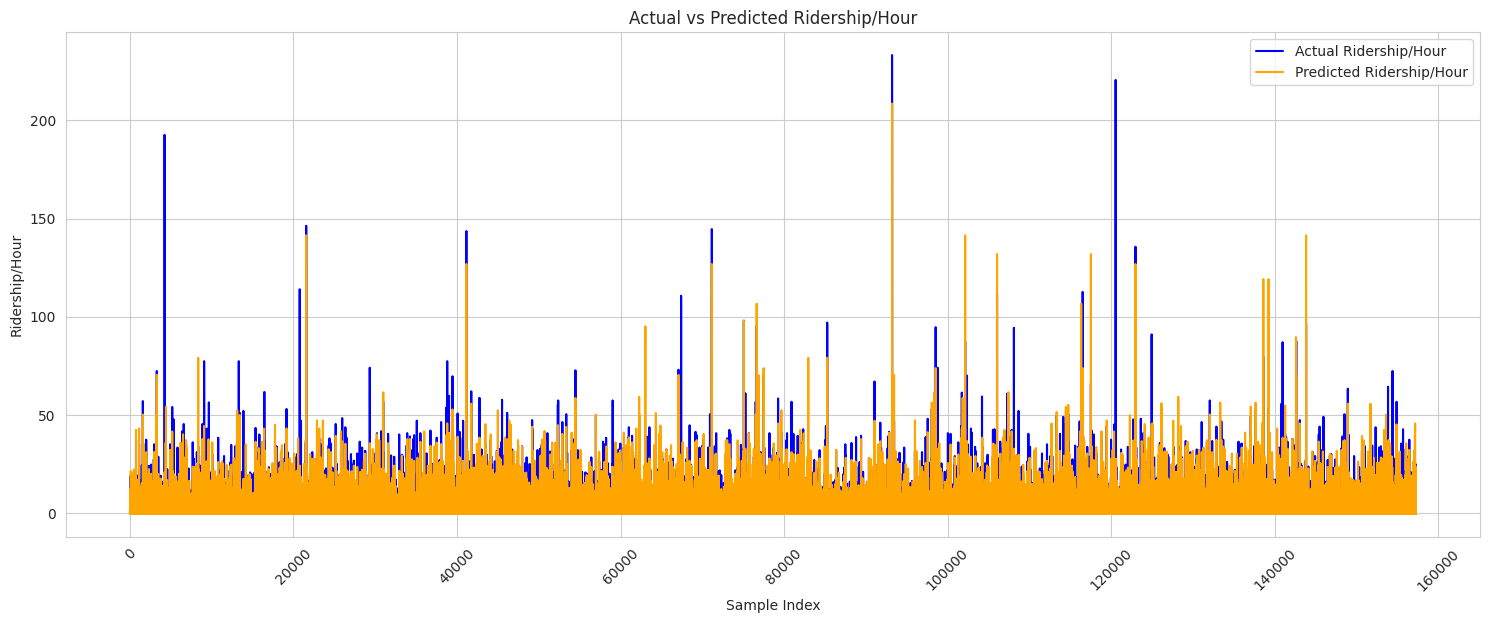

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_dt.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## XGBoost
XGBoost stands for Extreme Gradient Boosting. It’s a powerful and popular machine learning algorithm based on gradient boosting decision trees designed for speed and performance. It’s widely used for both regression and classification tasks.

In [ ]:
# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # for regression
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

# Train the model
xgb_model.fit(X_train_mi_selected, y_train)

# Predict on test set
y_pred_xg = xgb_model.predict(X_test_mi_selected)

# Evaluate
mse = mean_squared_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

XGBoost Regression Performance:
MSE: 7.1774
RMSE: 2.6791
MAE: 1.0848
R² Score: 0.4731


### Hyperparameter tuning
This code automatically searches through different XGBoost hyperparameters to find the best combination that minimizes prediction error. Using cross-validation ensures the model generalizes well, and the evaluation metrics confirm how well the tuned model performs on new data.

In [ ]:
# Initialize the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train_mi_selected, y_train)

# Best estimator
best_xgb = grid_search.best_estimator_

# Predict on test set
y_pred_xg = best_xgb.predict(X_test_mi_selected)

# Evaluate
mse = mean_squared_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Performance:")
print("Best parameters:", grid_search.best_params_)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
XGBoost Regression Performance:
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
MSE: 4.4444
RMSE: 2.1082
MAE: 0.9003
R² Score: 0.6737


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

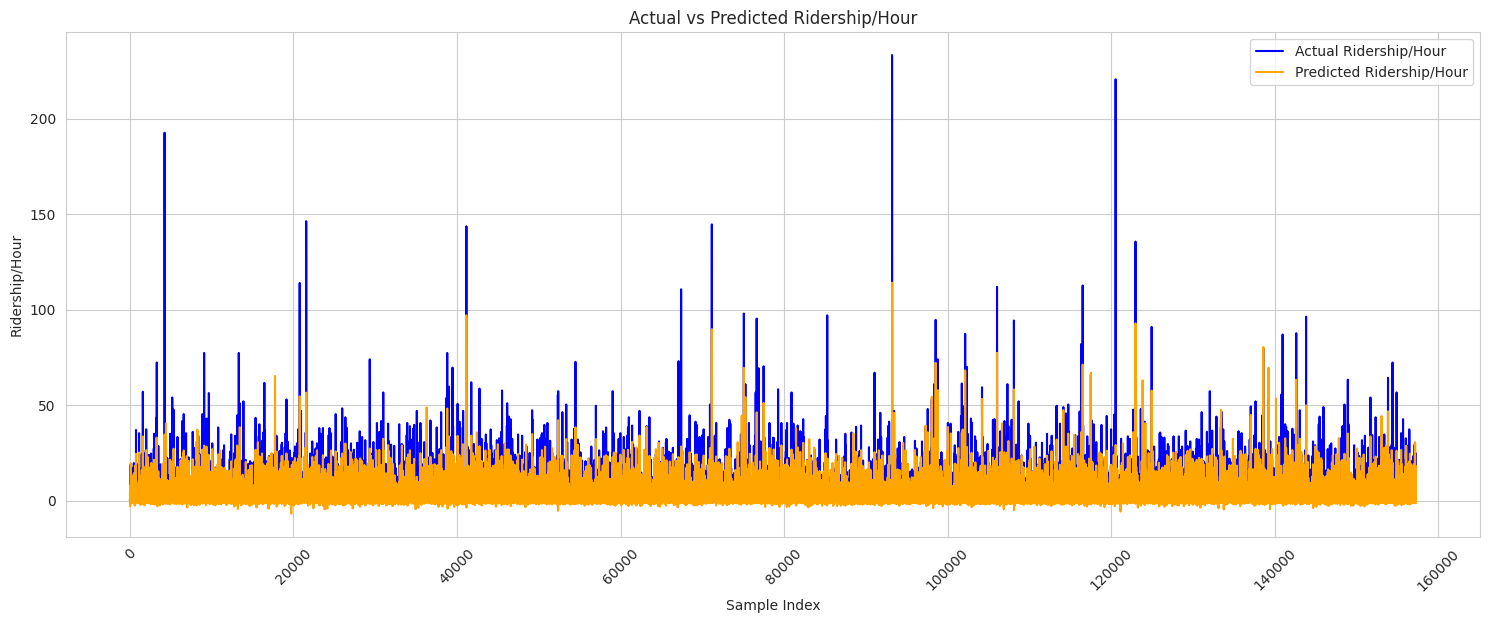

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_xg.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Random Forest Regressor
Random Forest is an ensemble machine learning algorithm used for both regression and classification tasks. It builds a "forest" of many decision trees and combines their outputs to improve prediction accuracy and control overfitting.

In [ ]:
# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Train the model
rf.fit(X_train_mi_selected, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test_mi_selected)

# Evaluate
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Regressor Performance:
MSE: 2.9396
RMSE: 1.7145
MAE: 0.6850
R² Score: 0.7842


### Hyperparameter tuning
This code performs an exhaustive search over a grid of Random Forest hyperparameters using cross-validation to find the best model settings. The selected best model is then evaluated on a test dataset using multiple metrics to measure prediction accuracy and goodness of fit.

In [ ]:
# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt']  # 'auto' deprecated, use 'sqrt' for regression
}

# Initialize Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1  # Use all cores for faster training
)

# Fit the model on training data
grid_search.fit(X_train_mi_selected, y_train)

# Extract the best model
best_rf = grid_search.best_estimator_

# Make predictions on the test data
y_pred_rf = best_rf.predict(X_test_mi_selected)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

# Display results
print("Best hyperparameters:", grid_search.best_params_)
print("Random Forest Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Performance:
MSE: 7.7469
RMSE: 2.7833
MAE: 1.0996
R² Score: 0.4313


Since the **fine-tuning results** were **not satisfactory**, we decided to revert to **using the non-tuned Random Forest regression model**.

In [ ]:
# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Train the model
rf.fit(X_train_mi_selected, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test_mi_selected)

# Evaluate
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Regressor Performance:
MSE: 2.9396
RMSE: 1.7145
MAE: 0.6850
R² Score: 0.7842


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

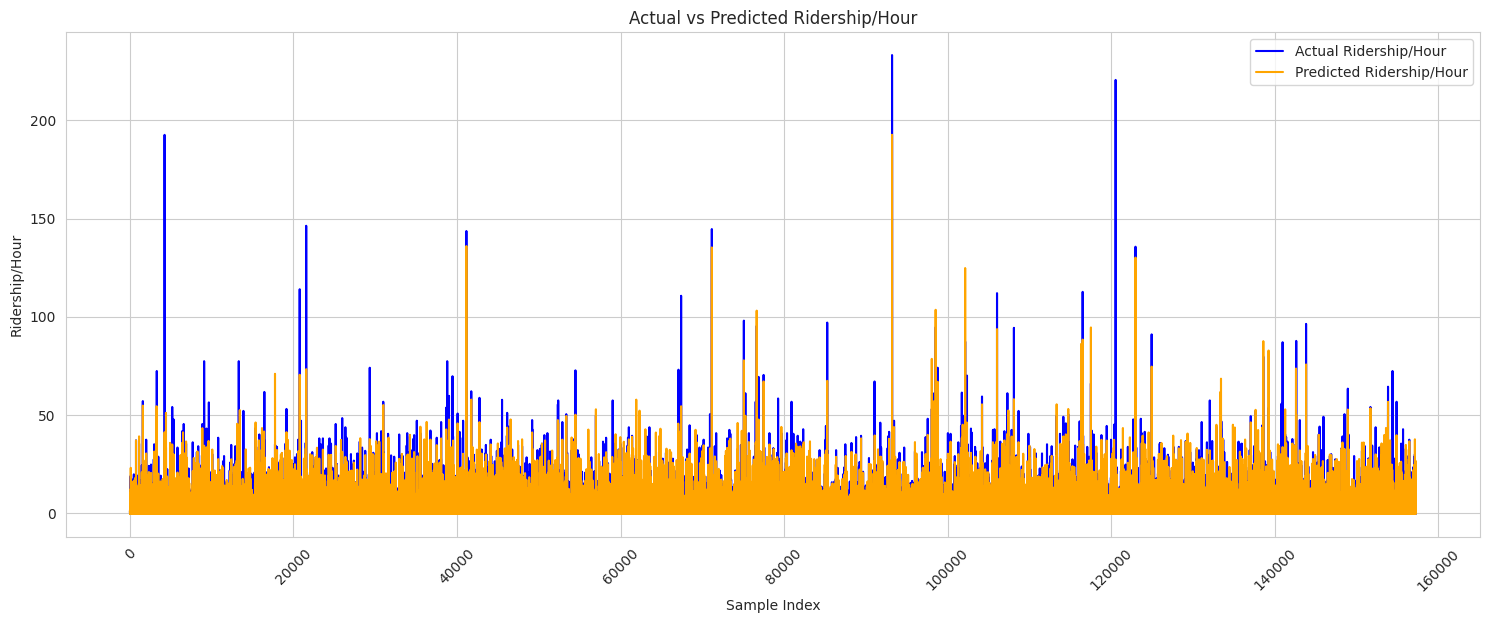

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_rf.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Lightgbm Regressor
LightGBM (Light Gradient Boosting Machine) is a powerful, fast, and efficient open-source gradient boosting framework developed by Microsoft. It’s designed for high-performance machine learning tasks, especially on large datasets and with many features.

In [ ]:
# Initialize LightGBM with default parameters
lgbm_basic = lgb.LGBMRegressor(random_state=42)

# Train the model on the training set
lgbm_basic.fit(X_train_mi_selected, y_train)

# Predict on test set
y_pred_lgb = lgbm_basic.predict(X_test_mi_selected)

# Evaluate performance
mse_basic = mean_squared_error(y_test, y_pred_lgb)
rmse_basic = np.sqrt(mse_basic)
mae_basic = mean_absolute_error(y_test, y_pred_lgb)
r2_basic = r2_score(y_test, y_pred_lgb)

print("Lightgbm Performance:")
print(f"MSE: {mse_basic:.4f}")
print(f"RMSE: {rmse_basic:.4f}")
print(f"MAE: {mae_basic:.4f}")
print(f"R²: {r2_basic:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 628936, number of used features: 15
[LightGBM] [Info] Start training from score 0.936664


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Lightgbm Performance:
MSE: 5.0319
RMSE: 2.2432
MAE: 1.0153
R²: 0.6306


### Hyperparameter tuning
This code systematically searches for the best LightGBM settings to improve prediction accuracy on your dataset, using randomized sampling of parameters and cross-validation to ensure the model generalizes well.

In [ ]:
# Define LightGBM model
lgbm = lgb.LGBMRegressor(random_state=42)

# Parameter distribution for random search
param_dist = {
    'n_estimators': [200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [100, 200],
    'max_depth': [20, 30],
    'min_child_samples': [30, 50],
    'subsample': [0.6, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0.1, 0.5, 1],
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit randomized search to training data
random_search.fit(X_train_mi_selected, y_train)

# Best model from random search
best_lgbm = random_search.best_estimator_

# Predict on test set with tuned model
y_pred_lgb = best_lgbm.predict(X_test_mi_selected)

# Evaluate tuned model performance
mse_tuned = mean_squared_error(y_test, y_pred_lgb)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_lgb)
r2_tuned = r2_score(y_test, y_pred_lgb)

print("Best Parameters:", random_search.best_params_)
print("Lightgbm Performance:")
print(f"MSE: {mse_tuned:.4f}")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"MAE: {mae_tuned:.4f}")
print(f"R²: {r2_tuned:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 628936, number of used features: 15
[LightGBM] [Info] Start training from score 0.936664


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Best Parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'num_leaves': 200, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 20, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Lightgbm Performance:
MSE: 2.6011
RMSE: 1.6128
MAE: 0.7126
R²: 0.8090


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

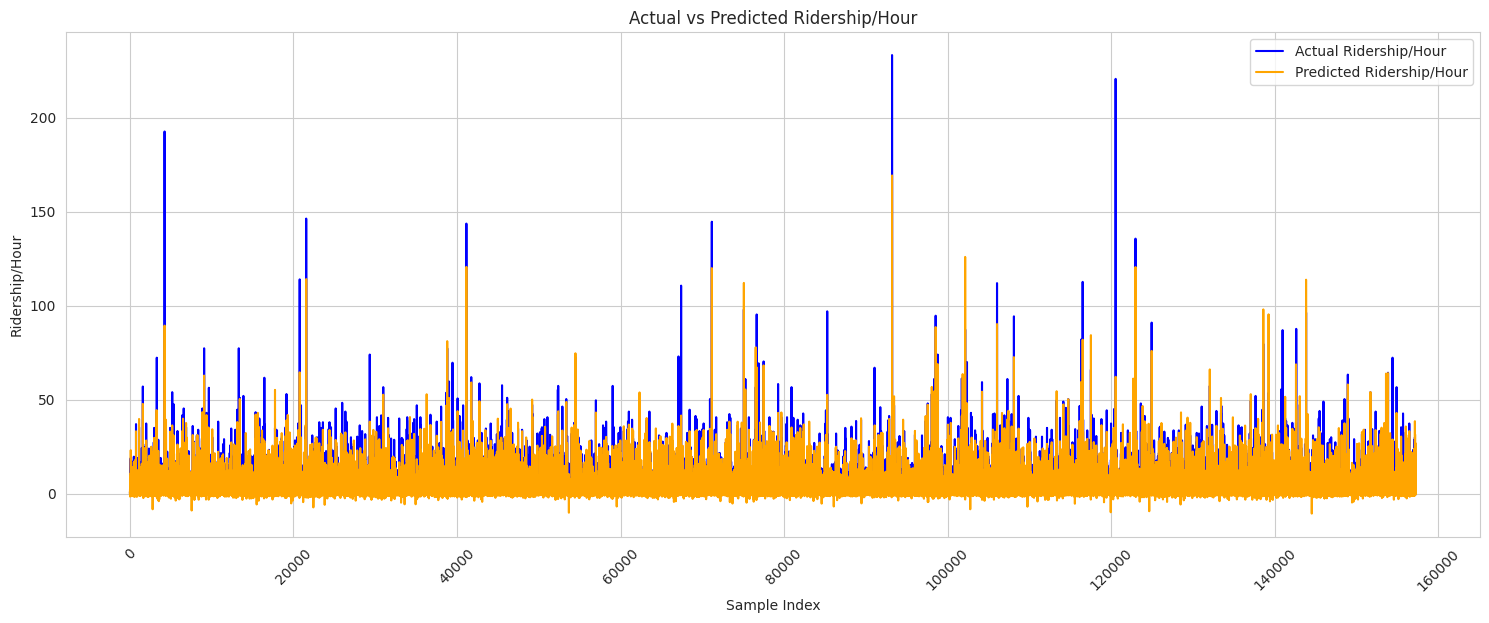

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_lgb.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## KNeighbors Regressor
K-Nearest Neighbors (KNN) is a simple, non-parametric algorithm used for regression by predicting the target value of a new data point based on the average of its k closest neighbors in the training data. It measures closeness using a distance metric like Euclidean distance and relies on selecting an appropriate number of neighbors (k). KNN requires feature scaling for accurate distance calculation and does not involve explicit model training, making it a lazy learner. While easy to implement and interpret, KNN can be computationally expensive for large datasets and sensitive to noisy data or irrelevant features.

In [ ]:
# Step 1: Initialize the KNN regressor
knn = KNeighborsRegressor(
    n_neighbors=7,       # Try 3, 5, 7 etc.
    weights='uniform',   # Or 'distance'
    algorithm='kd_tree'  # Can also be 'ball_tree', 'kd_tree', 'brute'
)

# Step 2: Train the model
knn.fit(X_train_mi_selected, y_train)

# Step 3: Predict on test set
y_pred_knn = knn.predict(X_test_mi_selected)

# Step 4: Evaluate the model
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

print("KNeighborsRegressor Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

KNeighborsRegressor Performance:
MSE: 5.4575
RMSE: 2.3361
MAE: 0.9181
R² Score: 0.5993


### Hyperparameter tuning
Actually, KNN does have fine-tuning, mainly by choosing the best value of k (the number of neighbors) and sometimes the distance metric or weights used to average neighbors' values.

In [ ]:
# Step 1: Initialize the KNN regressor
knn = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',   # Or 'distance'
    algorithm='brute'  # Can also be 'ball_tree', 'kd_tree', 'brute'
)

# Step 2: Train the model
knn.fit(X_train_mi_selected, y_train)

# Step 3: Predict on test set
y_pred_knn = knn.predict(X_test_mi_selected)

# Step 4: Evaluate the model
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

print("KNeighborsRegressor Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

KNeighborsRegressor Performance:
MSE: 5.0049
RMSE: 2.2372
MAE: 0.8944
R² Score: 0.6326


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

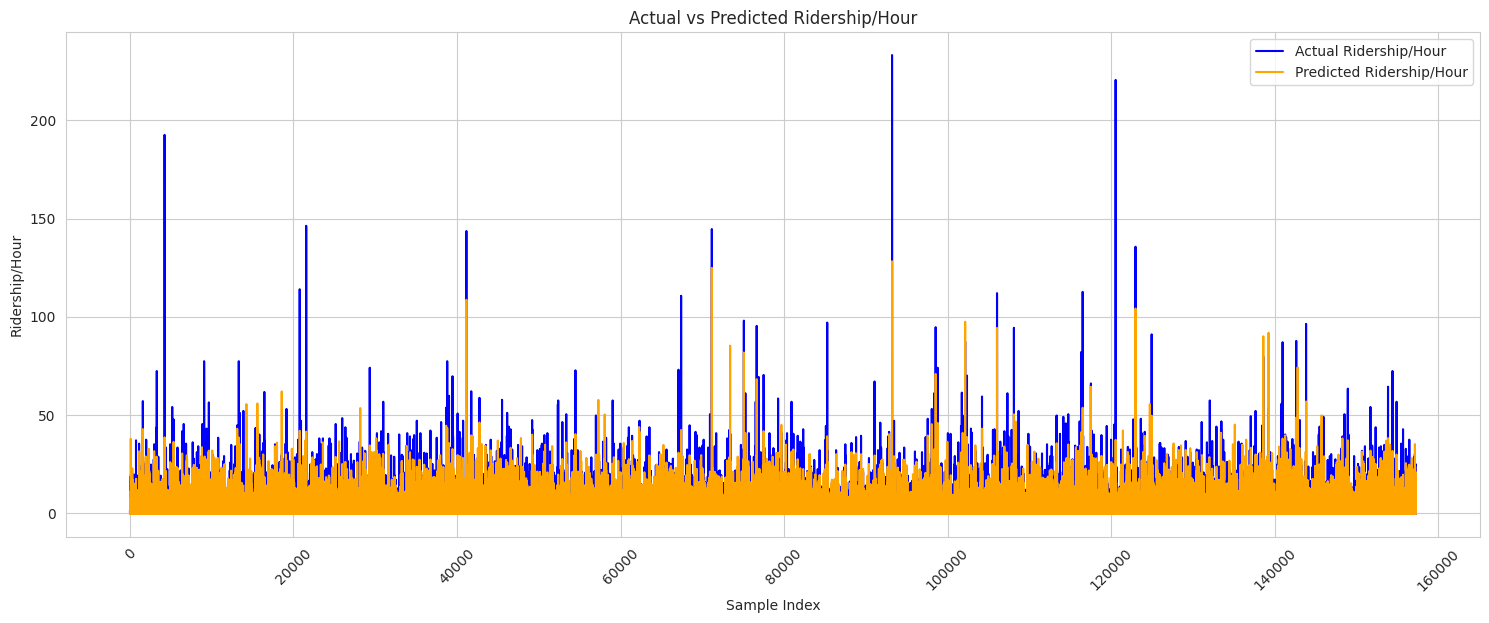

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_knn.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Huber Regression

In [ ]:
huber = HuberRegressor(epsilon=2.00, alpha=0.0001, max_iter=1000)  # epsilon can be tuned
huber.fit(X_train_mi_selected, y_train)
y_pred_huber = huber.predict(X_test_mi_selected)

mse = mean_squared_error(y_test, y_pred_huber)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_huber)
r2 = r2_score(y_test, y_pred_huber)

print("Huber Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Huber Regression Performance:
MSE: 13.8771
RMSE: 3.7252
MAE: 1.3042
R²: -0.0188


### Hyperparameter tuning
Using techniques like GridSearchCV, we systematically test different combinations of these parameters on training data with cross-validation to find the combination that results in the lowest prediction error. After finding the best settings, we evaluate the tuned model on test data to see how well it performs.

In [ ]:
# Define the model
huber = HuberRegressor()

# Define the hyperparameter grid
param_grid = {
    'epsilon': [1.5, 2.5],
    'alpha': [0.0001, 0.1],
    'max_iter': [500, 700]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=huber,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train_mi_selected, y_train)

# Best model
best_huber = grid_search.best_estimator_

# Predict on test set
y_pred_huber = best_huber.predict(X_test_mi_selected)

# Evaluate
mse = mean_squared_error(y_test, y_pred_huber)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_huber)
r2 = r2_score(y_test, y_pred_huber)

print("Best Parameters:", grid_search.best_params_)
print("Huber Regression Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters: {'alpha': 0.1, 'epsilon': 2.5, 'max_iter': 500}
Huber Regression Performance:
MSE: 13.7048
RMSE: 3.7020
MAE: 1.3525
R²: -0.0061


### Model Evaluation
This will evaluate the model using the lineplot method to show how accurate the model in predicting the target variable.

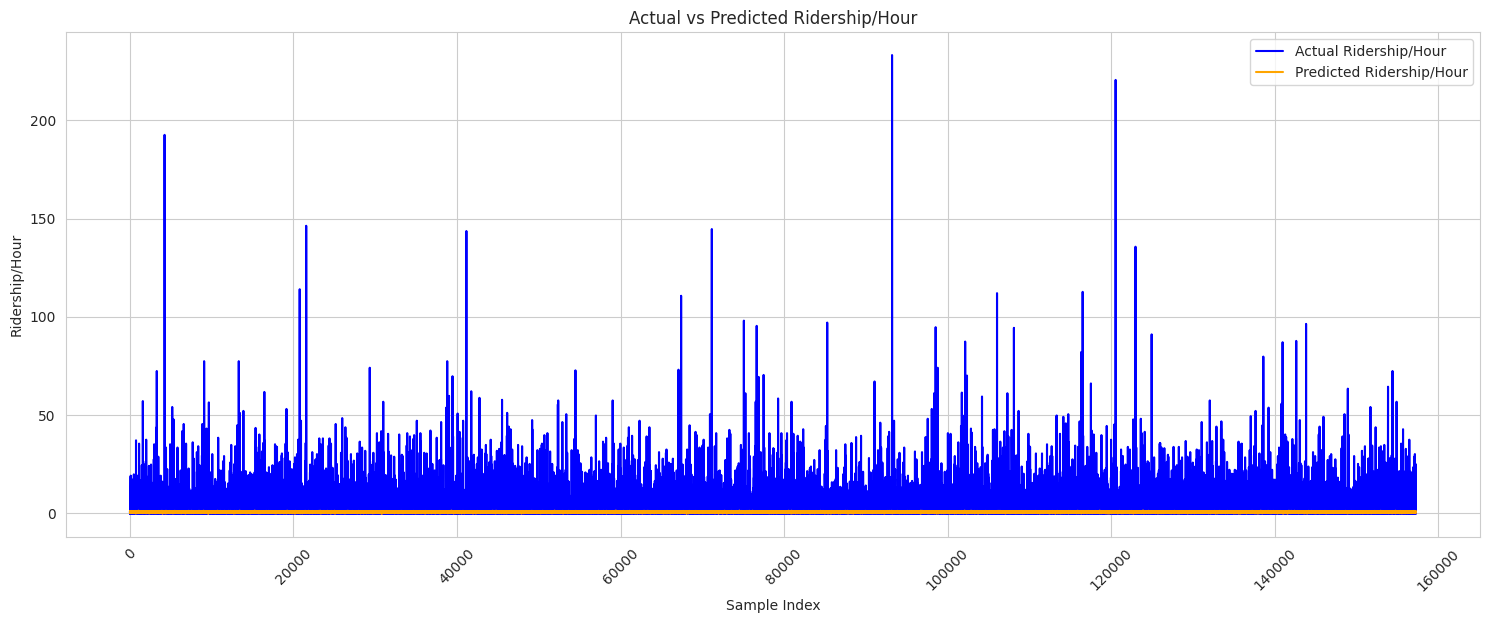

In [ ]:
y_test_flat = y_test.ravel()
y_pred_flat = y_pred_huber.ravel()

plot_df = pd.DataFrame({
    'Index': range(len(y_test_flat)),
    'Actual': y_test_flat,
    'Predicted': y_pred_flat
})

plt.figure(figsize=(15, 6))

x_axis = 'datetime' if 'datetime' in plot_df.columns else 'Index'

sns.lineplot(data=plot_df, x=x_axis, y='Actual', label='Actual Ridership/Hour', color='blue')
sns.lineplot(data=plot_df, x=x_axis, y='Predicted', label='Predicted Ridership/Hour', color='orange')

plt.title("Actual vs Predicted Ridership/Hour")
plt.xlabel("Time" if x_axis == 'datetime' else "Sample Index")
plt.ylabel("Ridership/Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# Conclusion

## Compare Models & Model Evaluation
We trained, fine-tuned and compared **eight** models: <br><br>

1. **Linear Regression**
2. **MLP Regressor**
3. **Decision Tree Regressor**
4. **XGBoost**
5. **Random Forest Regressor**
6. **LightGBM**
7. **K-Nearest Neighbors Regressor**
8. **Huber Regression**
<br><br>

Among these, the fine-tuned LightGBM model achieved the lowest MSE and RMSE, indicating the best performance. Therefore, LightGBM was selected as the final model.

In [ ]:
predictions = {
    'Linear Regression': y_pred_ridge,
    'MLP Regressor': y_pred_mlp,
    'Decision Tree Regressor': y_pred_dt,
    'XGBoost': y_pred_xg,
    'Random Forest Regressor': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'KNeighbors Regressor': y_pred_knn,
    'Huber Regression': y_pred_huber
}

results = []

for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results)
print(results_df)

                     Model        MSE      RMSE       MAE        R²
0        Linear Regression  13.426701  3.664246  1.572459  0.014292
1            MLP Regressor   6.727165  2.593678  1.248486  0.506132
2  Decision Tree Regressor   3.868344  1.966811  0.753437  0.716009
3                  XGBoost   4.444438  2.108184  0.900293  0.673716
4  Random Forest Regressor   2.939602  1.714527  0.685018  0.784192
5                 LightGBM   2.601064  1.612781  0.712575  0.809045
6     KNeighbors Regressor   5.004936  2.237171  0.894394  0.632568
7         Huber Regression  13.704820  3.702002  1.352537 -0.006126


<ipython-input-129-c13cf5e6ae9e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, palette='Set2')


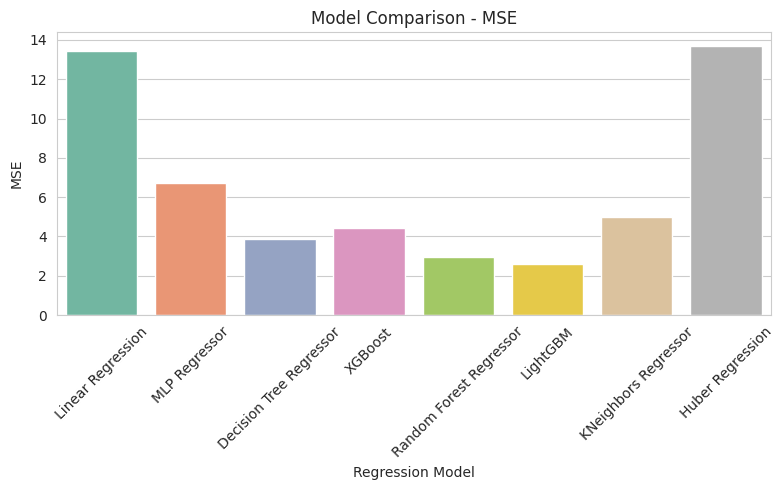

<ipython-input-129-c13cf5e6ae9e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, palette='Set2')


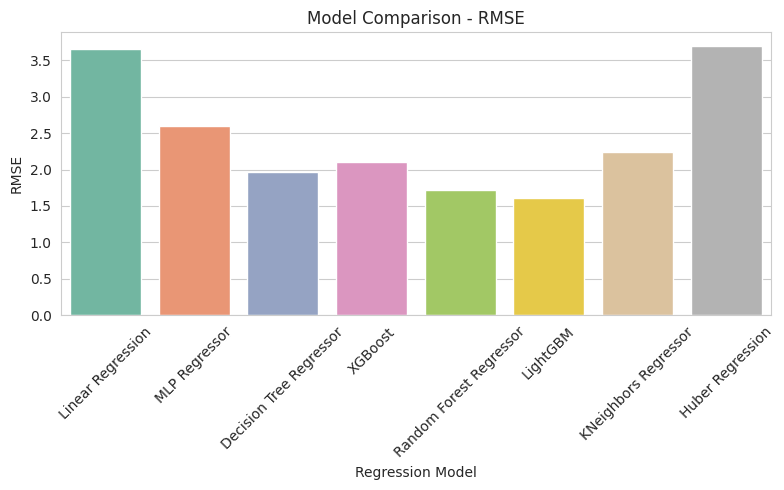

<ipython-input-129-c13cf5e6ae9e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, palette='Set2')


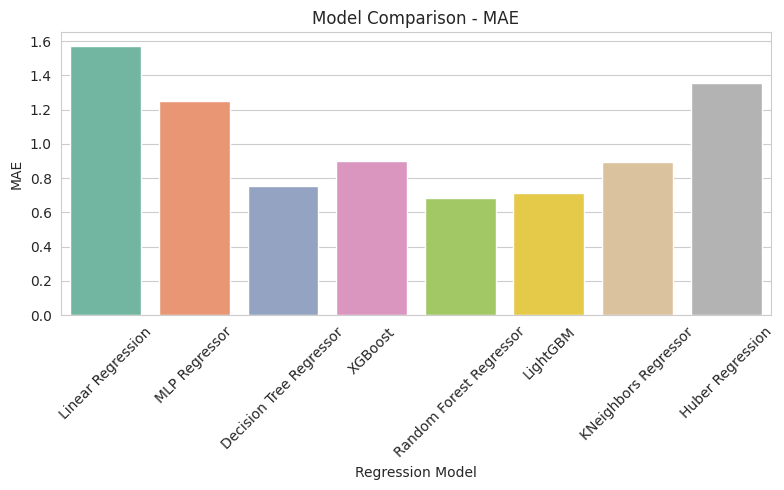

<ipython-input-129-c13cf5e6ae9e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y=metric, palette='Set2')


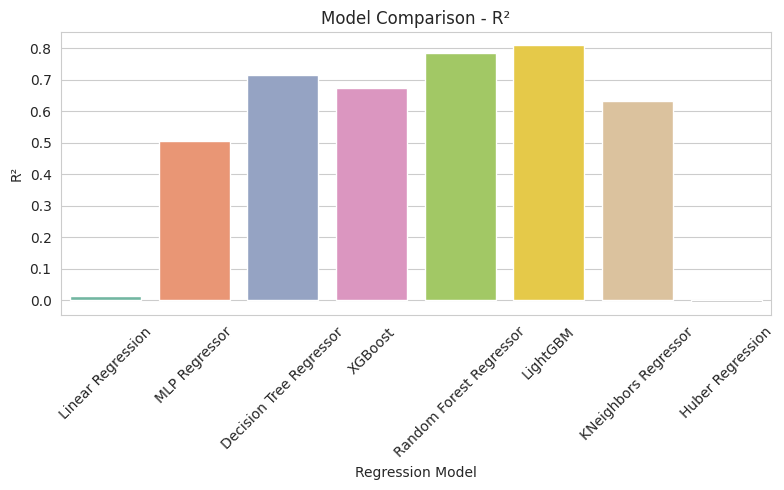

In [ ]:
metrics = ['MSE', 'RMSE', 'MAE', 'R²']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=results_df, x='Model', y=metric, palette='Set2')
    plt.title(f'Model Comparison - {metric}')
    plt.ylabel(metric)
    plt.xlabel('Regression Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## We have selected LightGBM Regressor as our final model

It is because it provides the lowest MSE and highest R² if compared to other models.<br><br>

**Mean Squared Error (MSE)** measures the average squared difference between the predicted values and the actual values. A lower MSE indicates that the model’s predictions are closer to the true values, meaning fewer errors overall.<br><br>

**Root Mean Squared Error (RMSE)** is a common metric for evaluating regression models. It measures the average magnitude of error between the predicted and actual values, which it is also in the same units as the target variable.<br><br>

**Mean Absolute Error (MAE)** is a regression metric used to evaluate how close a model's predictions are to the actual target values. It calculates the average of the absolute differences between predicted values and actual values.<br><br>

**R² score (coefficient of determination)** measures how well the model explains the variance in the target variable. An R² closer to 1 means the model fits the data better, capturing more of the variability in the output.<br><br>

Because LightGBM Regressor gave the lowest MSE, it had the smallest average prediction error, and with the highest R², it explained the data’s variation better than other models. This combination shows it is more accurate and reliable for predicting the ridership/hour, so we choose it as the final model.<br><br>

We focus more on **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)** because it penalizes larger errors more heavily, which is useful when predicting continuous targets. Since our dataset likely has **non-linear relationships**, MSE and RMSE help capture deviations from the true values more sensitively, making it a suitable metric for evaluating model performance.<br><br>

**Evaluation Method: Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)**<br>
**MSE of LightGBM Regressor:** 2.9040 <br>
**RMSE of LightGBM Regressor:** 1.7041<br>
**MAE of LightGBM Regressor:** 0.7313<br>
**R² of LightGBM Regressor:** 0.7868<br>

## Feature Importance Analysis
After selecting the final model, we visualized the feature importance analysis of **LightGBM** to highlight which features had the greatest impact on the model's overall performance. From the bar plot, we observed that **'destination'** and **'origin'** were the **most influential features** in the model training, followed by **'day'** and **'humidity'**.

<ipython-input-130-8c597aa96608>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


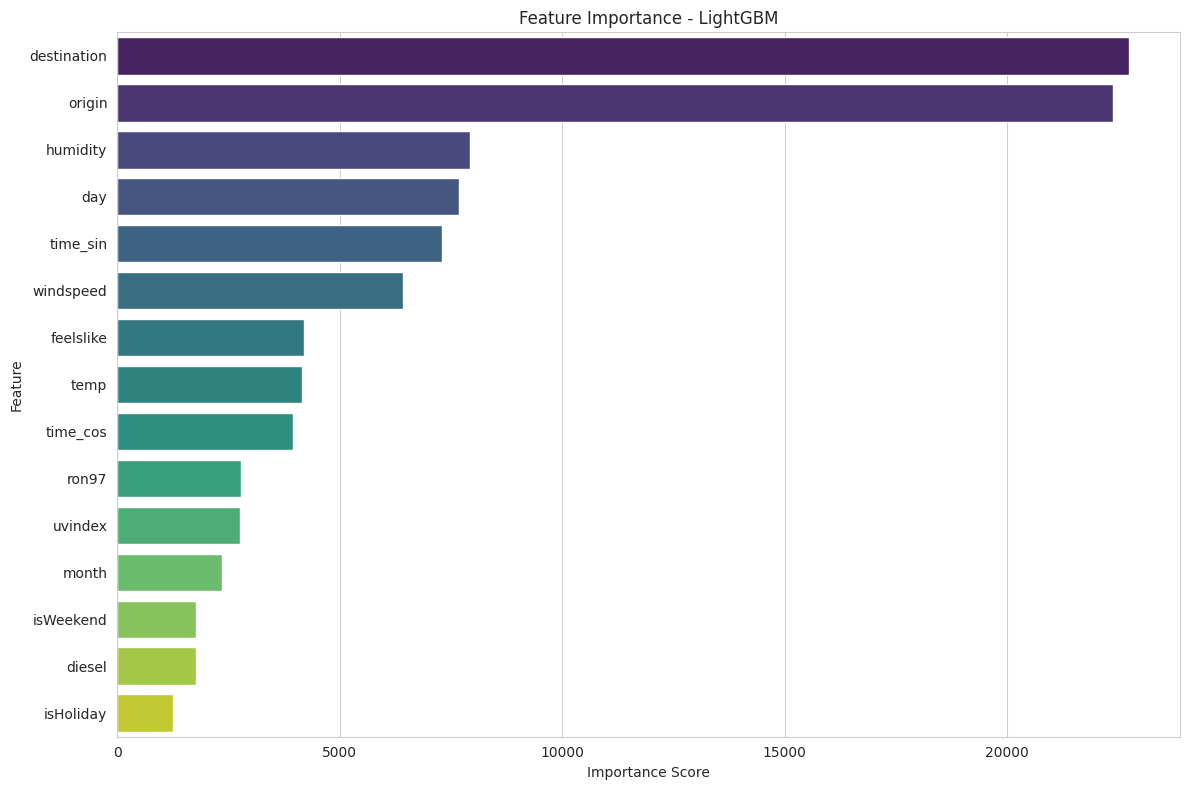

In [ ]:
# Get feature importances from the trained LightGBM model
importances = best_lgbm.feature_importances_

# Create DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': selected_features_mi,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top N features
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Save the best model
with open("model.pkl", "wb") as f:
    pickle.dump(best_lgbm, f)

# Also save your scalers and encoders if you haven't done so yet
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

with open("scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
selected_features_mi_list = selected_features_mi.tolist()
selected_numerical_features_for_scaler = [f for f in selected_features_mi_list if f not in ['origin', 'destination', 'isHoliday', 'isWeekend', 'precip']]

# Subset the original feature matrix to selected numerical features
X_selected_numerical_only = pd.DataFrame(X_train_mi_selected, columns=selected_features_mi)[selected_numerical_features_for_scaler]

# Initialize and fit the scaler
scaler_X = RobustScaler()
scaler_X.fit(X_selected_numerical_only)

# Save the fitted scaler
with open("scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

In [ ]:
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# === Load model and preprocessing objects ===
with open("model.pkl", "rb") as f:
    model = pickle.load(f)
with open("scaler_X.pkl", "rb") as f:
    scaler_X = pickle.load(f)
with open("scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)
with open("label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

# === Define selected features based on training ===
# These lists must match the features selected by SelectKBest and used for model training
selected_numerical_features = [
    'diesel', 'temp', 'feelslike', 'humidity',
    'windspeed', 'visibility', 'uvindex',
    'day', 'month', 'time_sin', 'time_cos'
]

selected_categorical_features = [
    'origin', 'destination', 'isHoliday', 'isWeekend', 'precip'
]

# The order of features in model_features is crucial as the model expects them in this order
model_features = selected_numerical_features + selected_categorical_features

seconds_in_day = 24 * 60 * 60

st.title("Ridership Prediction App")

# === User Inputs ===
# Removed ron97 as it was not a selected feature
diesel = st.number_input("Diesel Price", value=2.15)
temp = st.number_input("Temperature (°C)", value=30.0)
feelslike = st.number_input("Feels Like (°C)", value=33.0)
humidity = st.slider("Humidity (%)", 0, 100, 70)
windspeed = st.number_input("Wind Speed", value=5.0)
visibility = st.number_input("Visibility (km)", value=10.0) # Added visibility
uvindex = st.slider("UV Index", 0, 11, 5)
day = st.slider("Day", 1, 31, 15)
month = st.slider("Month", 1, 12, 6)

time_seconds = st.slider("Time of Day (seconds)", 0, seconds_in_day - 1, seconds_in_day // 2)
time_sin = np.sin(2 * np.pi * time_seconds / seconds_in_day)
time_cos = np.cos(2 * np.pi * time_seconds / seconds_in_day)

origin = st.selectbox("Origin", label_encoders['origin'].classes_)
destination = st.selectbox("Destination", label_encoders['destination'].classes_)
isHoliday = st.selectbox("Is Holiday?", ["Yes", "No"])
isWeekend = st.selectbox("Is Weekend?", ["Yes", "No"])
precip = st.selectbox("Has Precipitation?", ["Yes", "No"]) # Added precip

# === Encode categorical inputs ===
cat_input = {
    'origin': label_encoders['origin'].transform([origin])[0],
    'destination': label_encoders['destination'].transform([destination])[0],
    'isHoliday': label_encoders['isHoliday'].transform([1 if isHoliday == "Yes" else 0])[0],
    'isWeekend': label_encoders['isWeekend'].transform([1 if isWeekend == "Yes" else 0])[0],
    'precip': label_encoders['precip'].transform([1 if precip == "Yes" else 0])[0] # Encoded precip
}

# === Combine all inputs ===
input_data = pd.DataFrame([{
    'diesel': diesel,
    'temp': temp,
    'feelslike': feelslike,
    'humidity': humidity,
    'windspeed': windspeed,
    'visibility': visibility,
    'uvindex': uvindex,
    'day': day,
    'month': month,
    'time_sin': time_sin,
    'time_cos': time_cos,
    **cat_input
}])

# === Scale only the selected numerical features ===
input_data_scaled_numerical = scaler_X.transform(input_data[selected_numerical_features])
input_data[selected_numerical_features] = input_data_scaled_numerical

# === Keep column order consistent with model_features ===
input_data = input_data[model_features]

# === Predict ===
if st.button("Predict Ridership"):
    scaled_prediction = model.predict(input_data)
    original_prediction = scaler_y.inverse_transform(scaled_prediction.reshape(-1, 1))
    st.success(f"Predicted Ridership/hour: {original_prediction[0][0]:.2f}")

2025-06-04 12:30:58.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.178 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-04 12:30:58.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!pip install pyngrok
!ngrok config add-authtoken 2y2ejcgOx2lwVEQtOTGovdxAhiw_29hZvYn8jcuXyXfwbGwxx
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"🚀 Streamlit app is live at: {public_url}")
!streamlit run app.py &

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🚀 Streamlit app is live at: NgrokTunnel: "https://f426-34-83-102-199.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.83.102.199:8501

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.11/dist-packages/streamlit/runtime/scriptrunner/exec_code.py:  
  121 in exec_func_with_error_handling                                                  
                                                                                        
  /usr/local/lib/python3.11/dist-packages/streamlit/runtime/scriptrunner/script_runner  
  .py:645 in code_to_exec                                                               
                                                                                        
  /content/app.py:74